# Double tag toy studies
## Study the double tag yields from toys

### Load utility function

In [1]:
gROOT->ProcessLine(".L ../UtilityFunctions.C");

### Number of bins and toys

In [2]:
const int NumberBins = 4;
const std::size_t NumberToys = 1000;

### Start with CP tags

In [3]:
std::vector<std::string> Tags{"KK", "KSpi0", "pipipi0"};

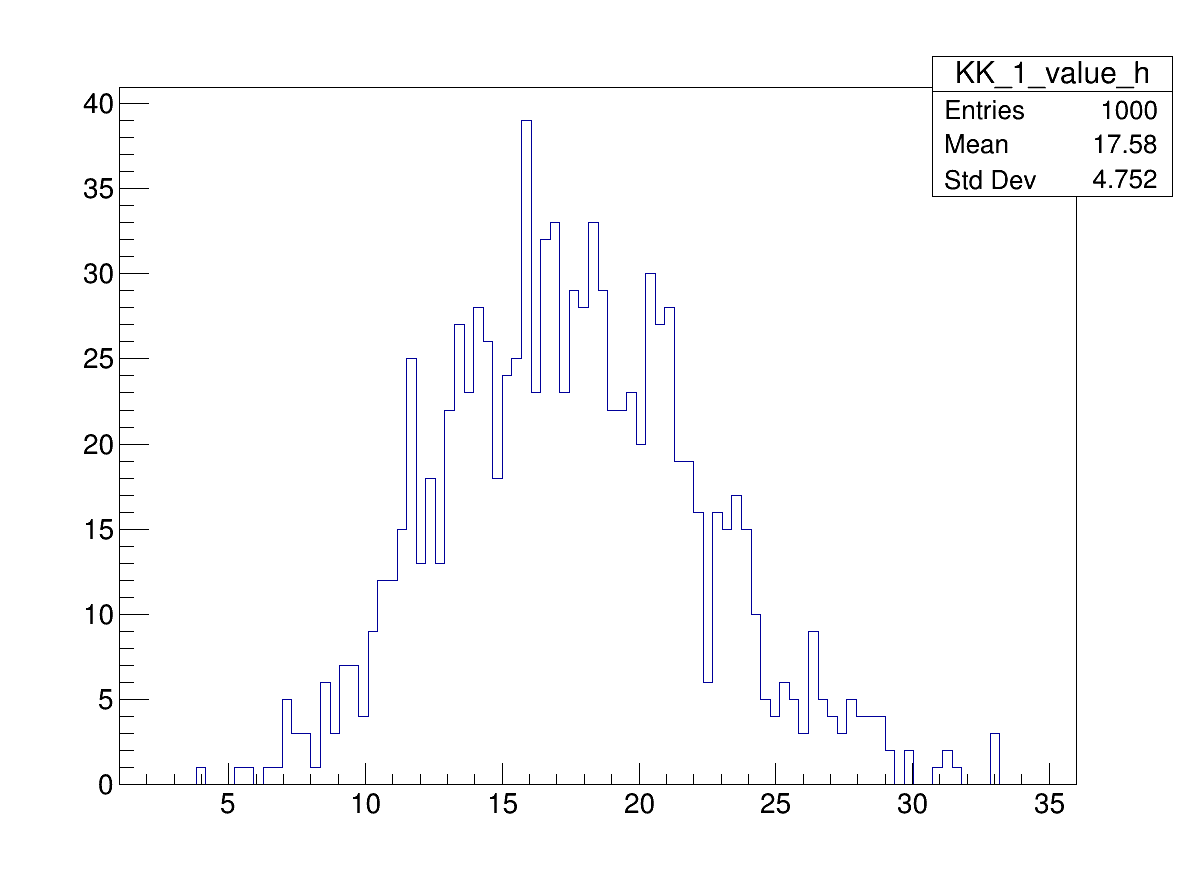

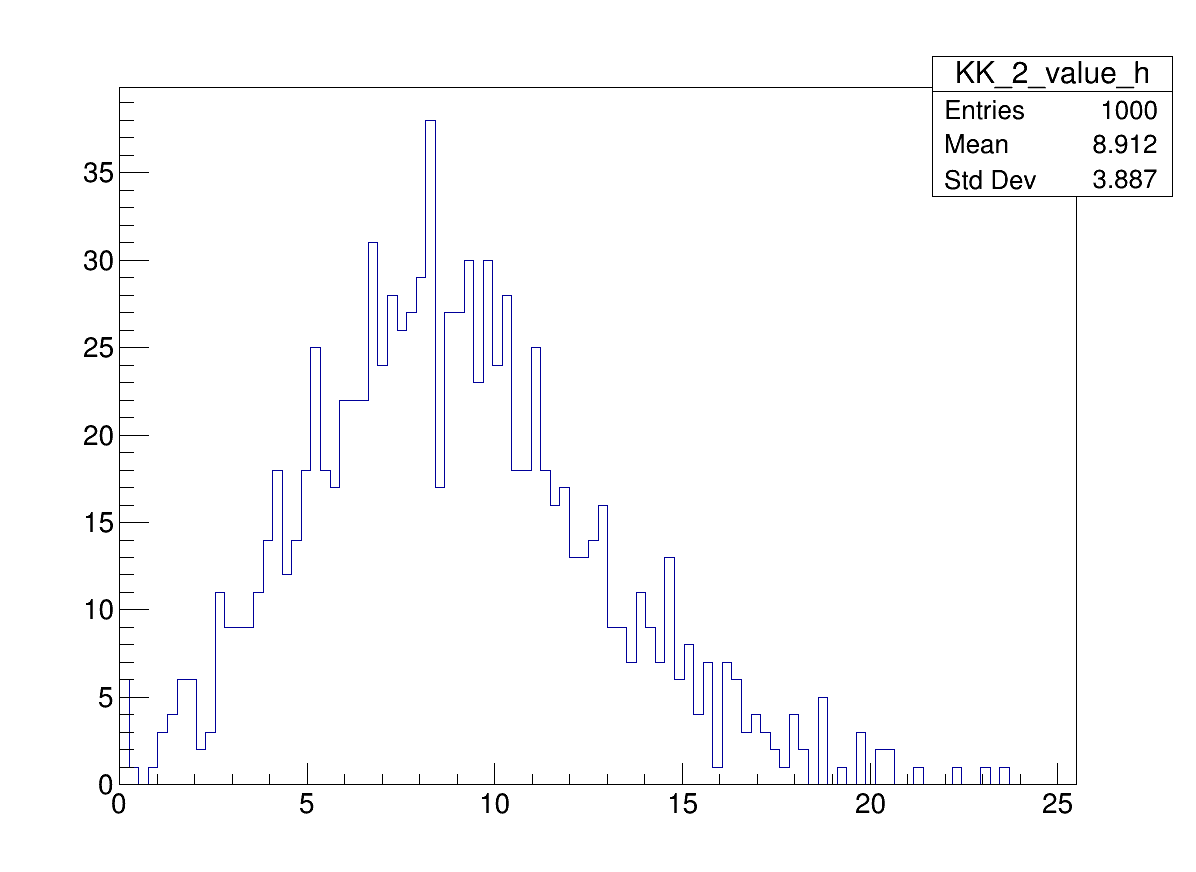

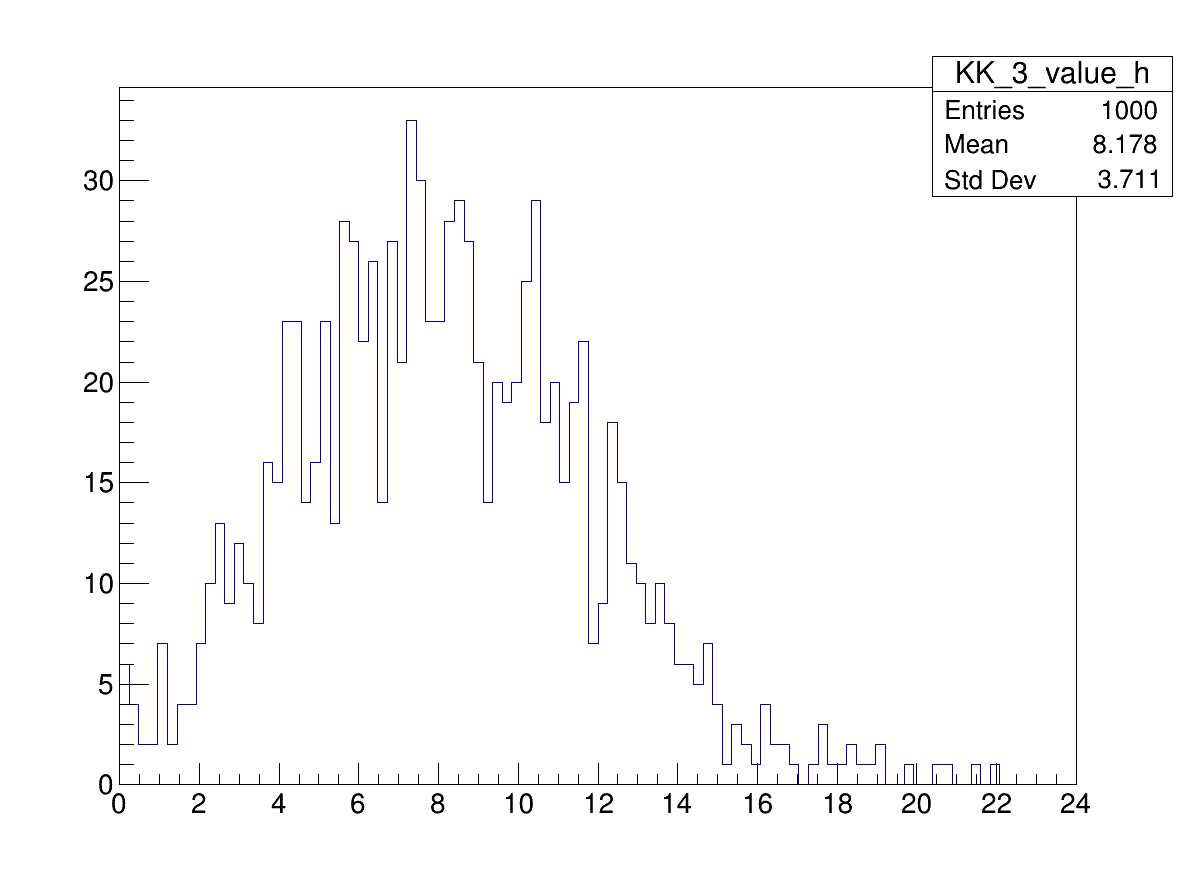

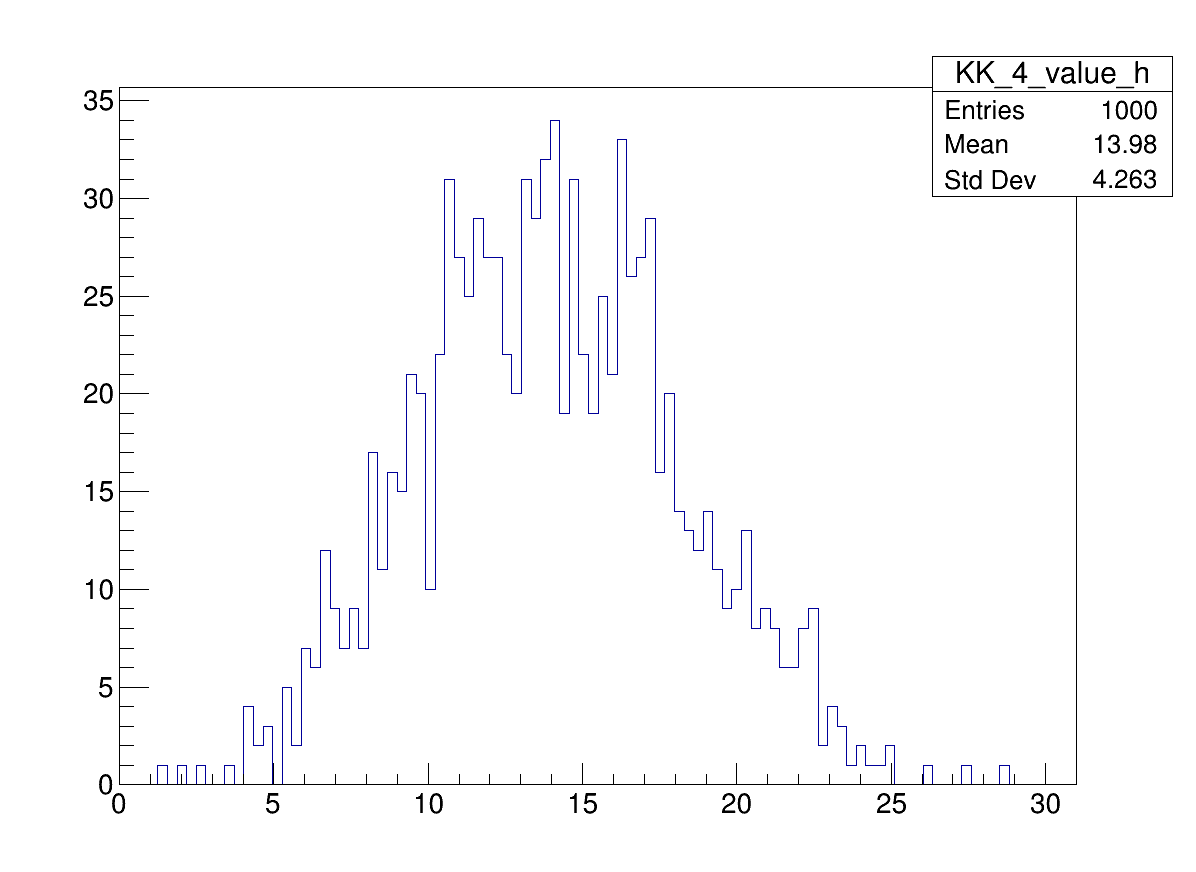

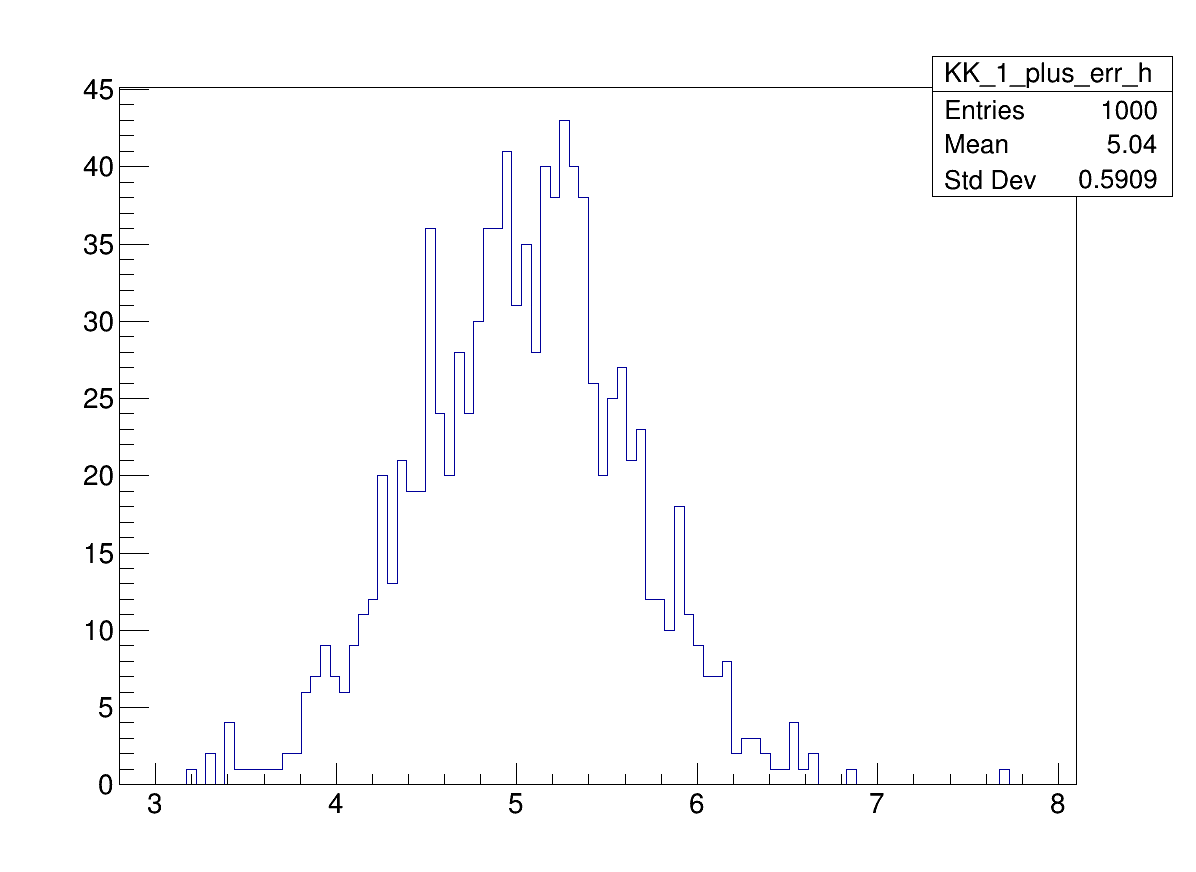

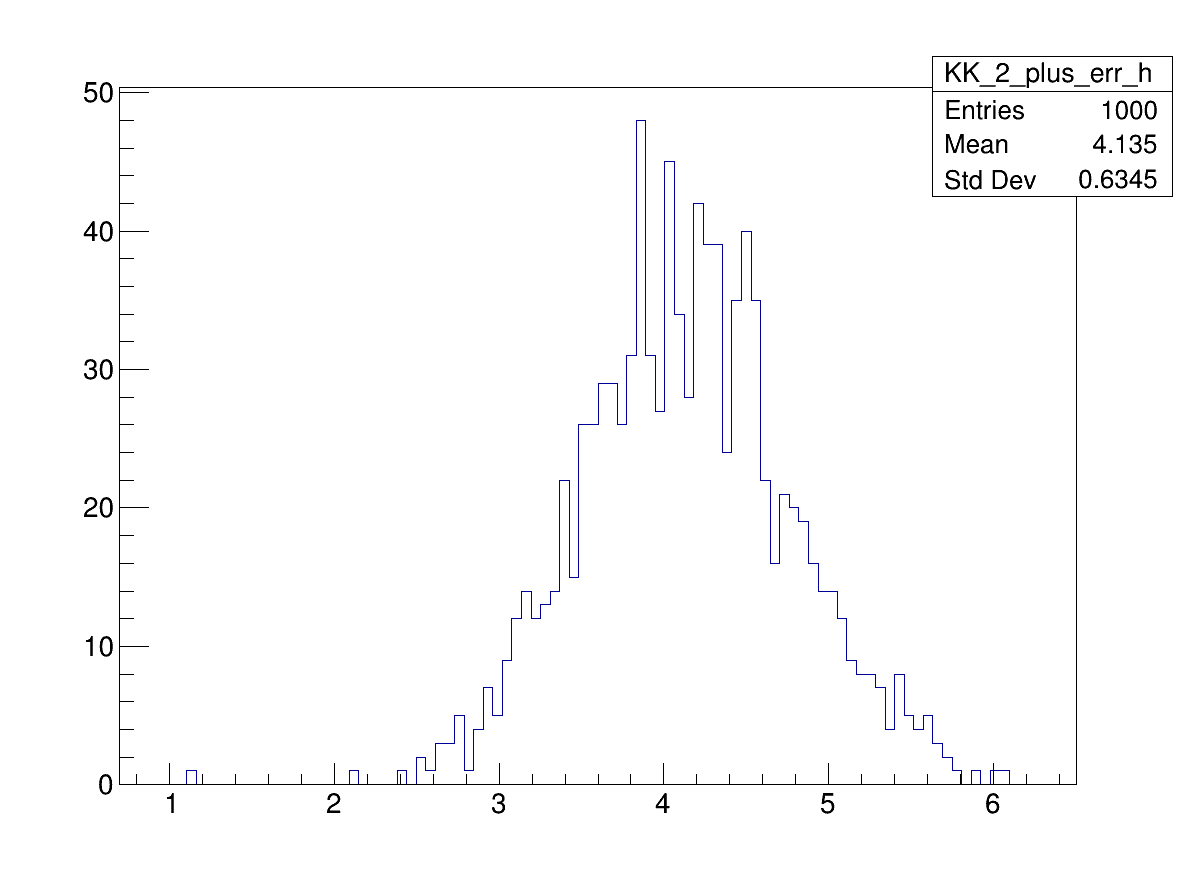

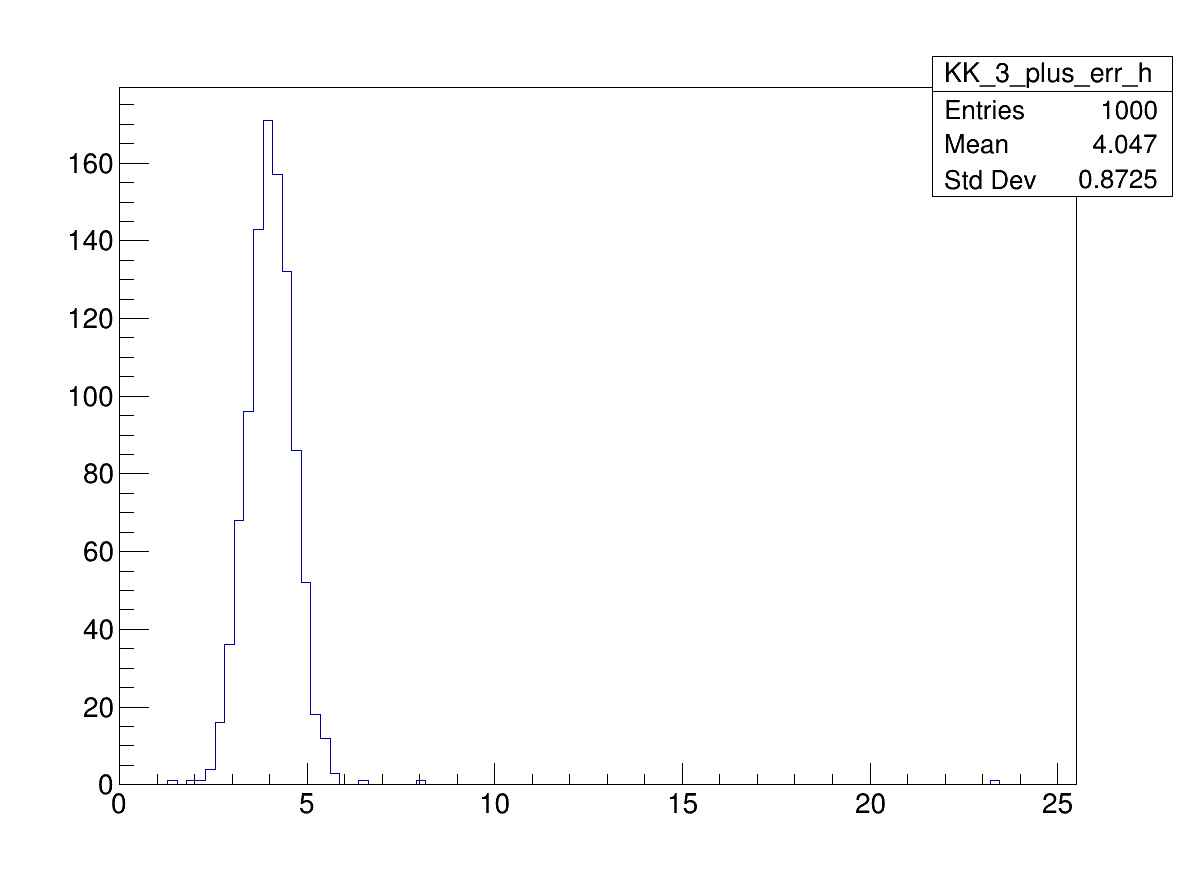

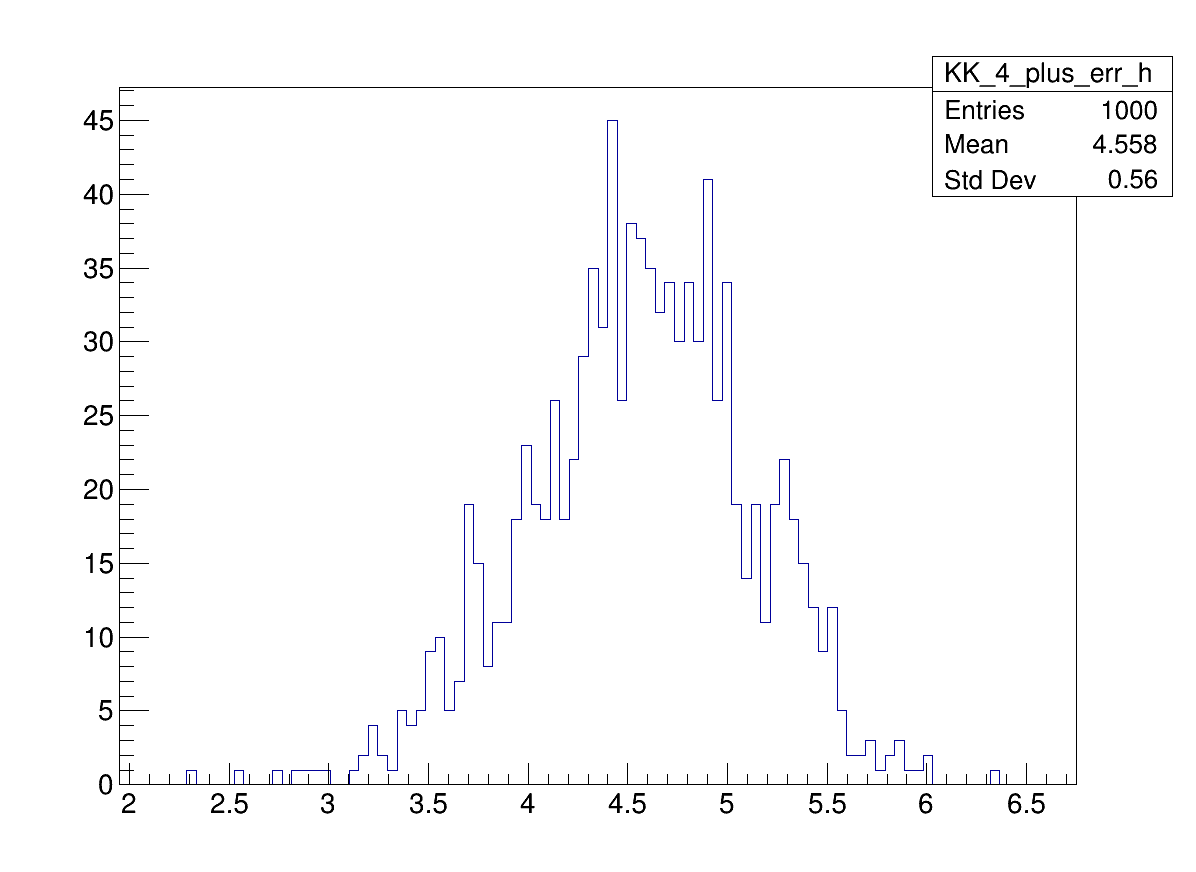

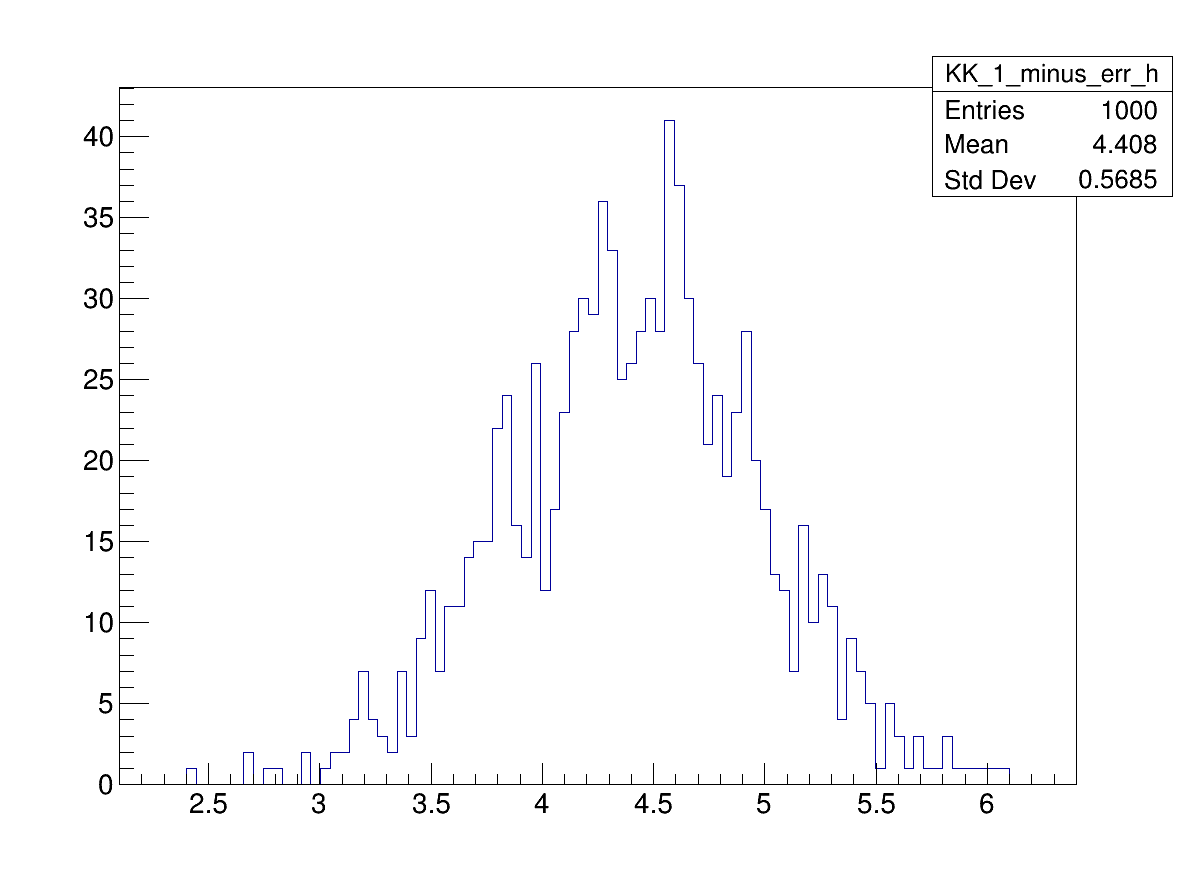

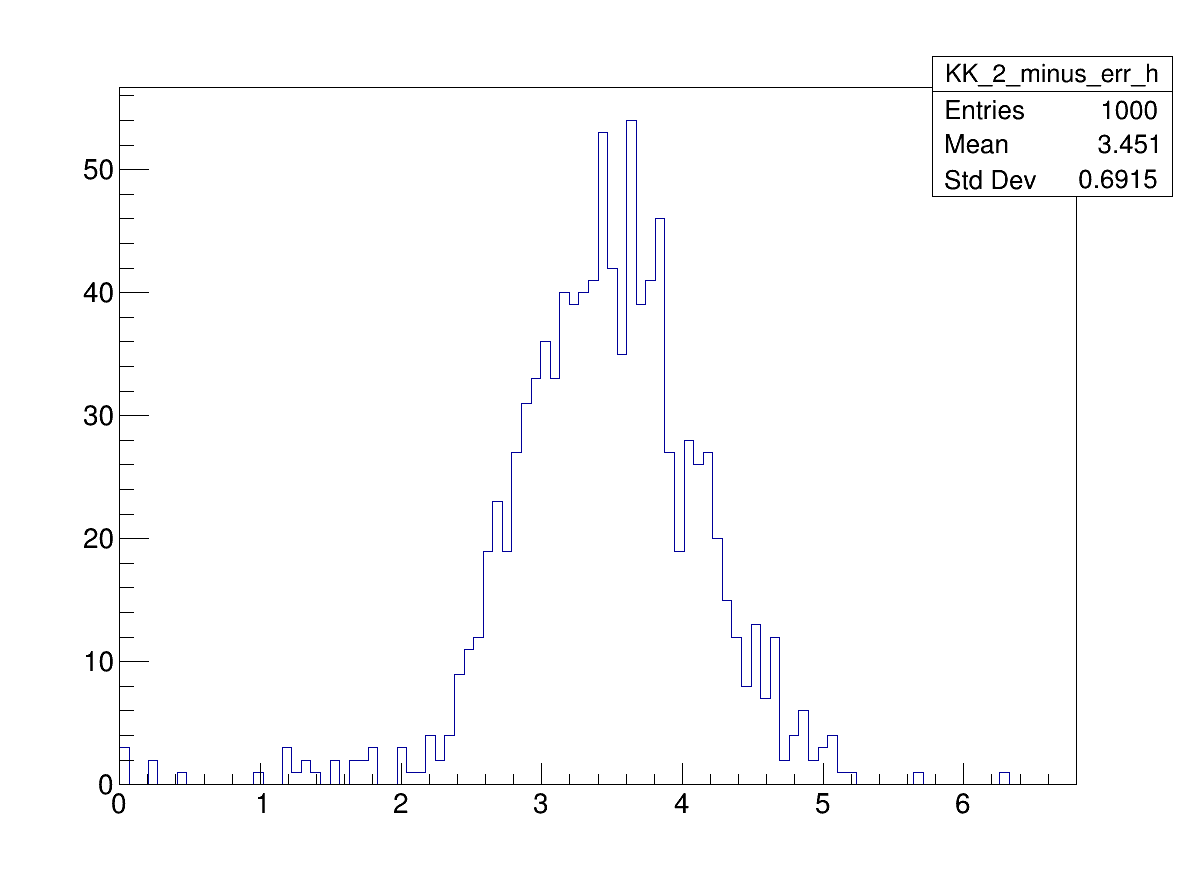

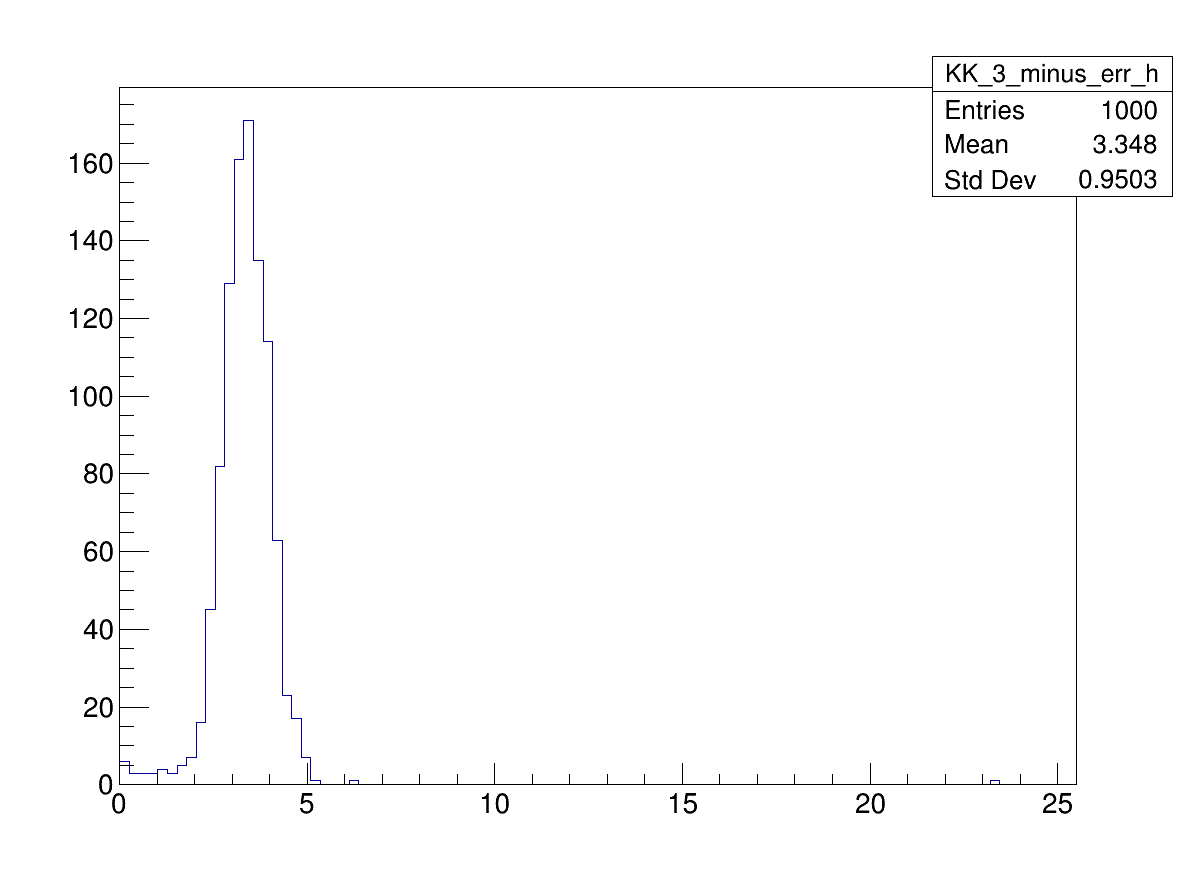

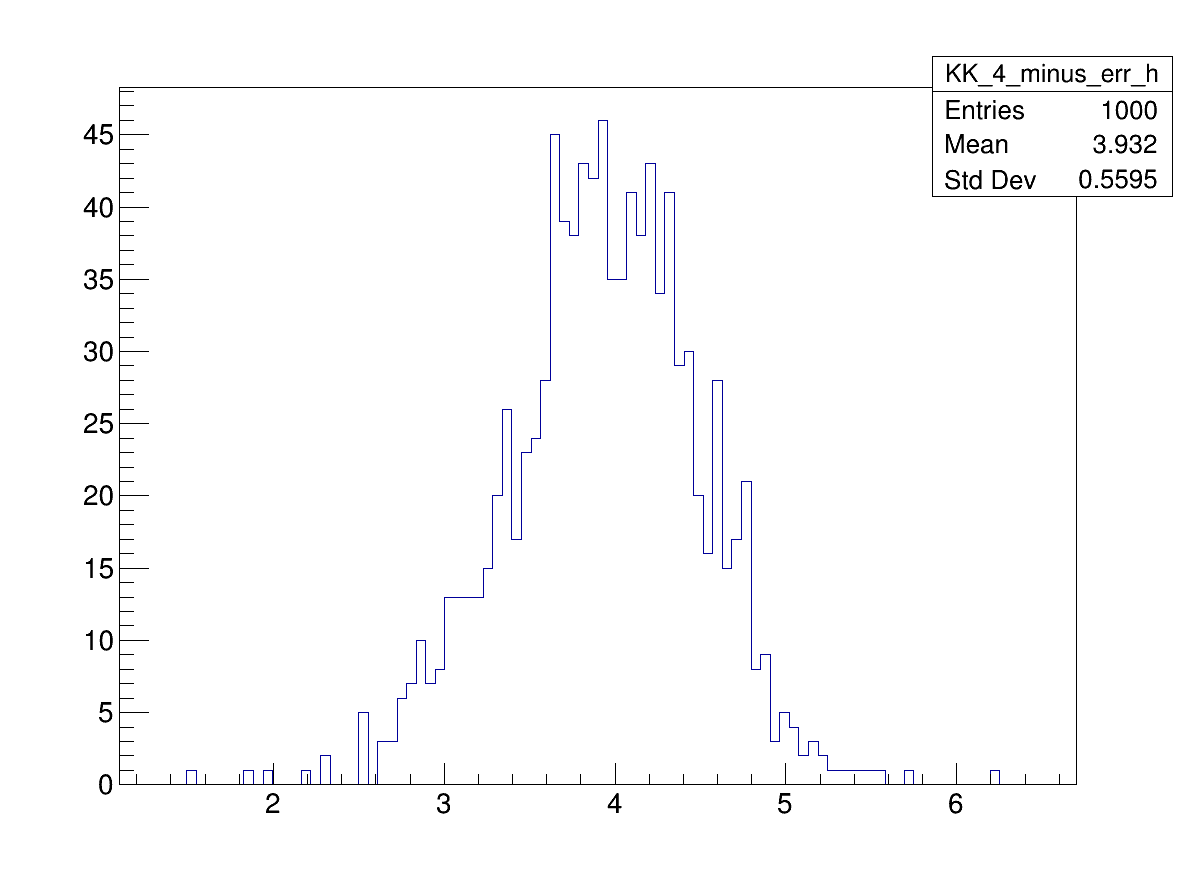

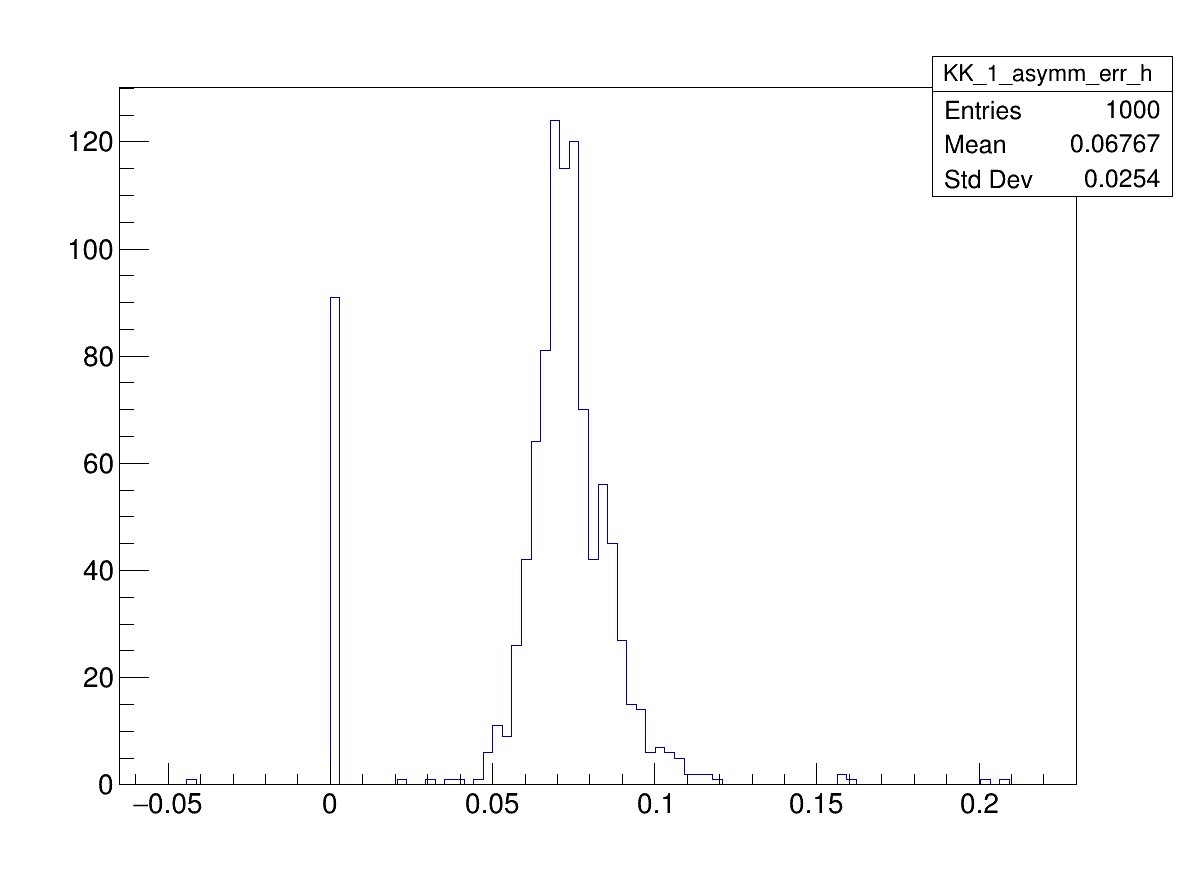

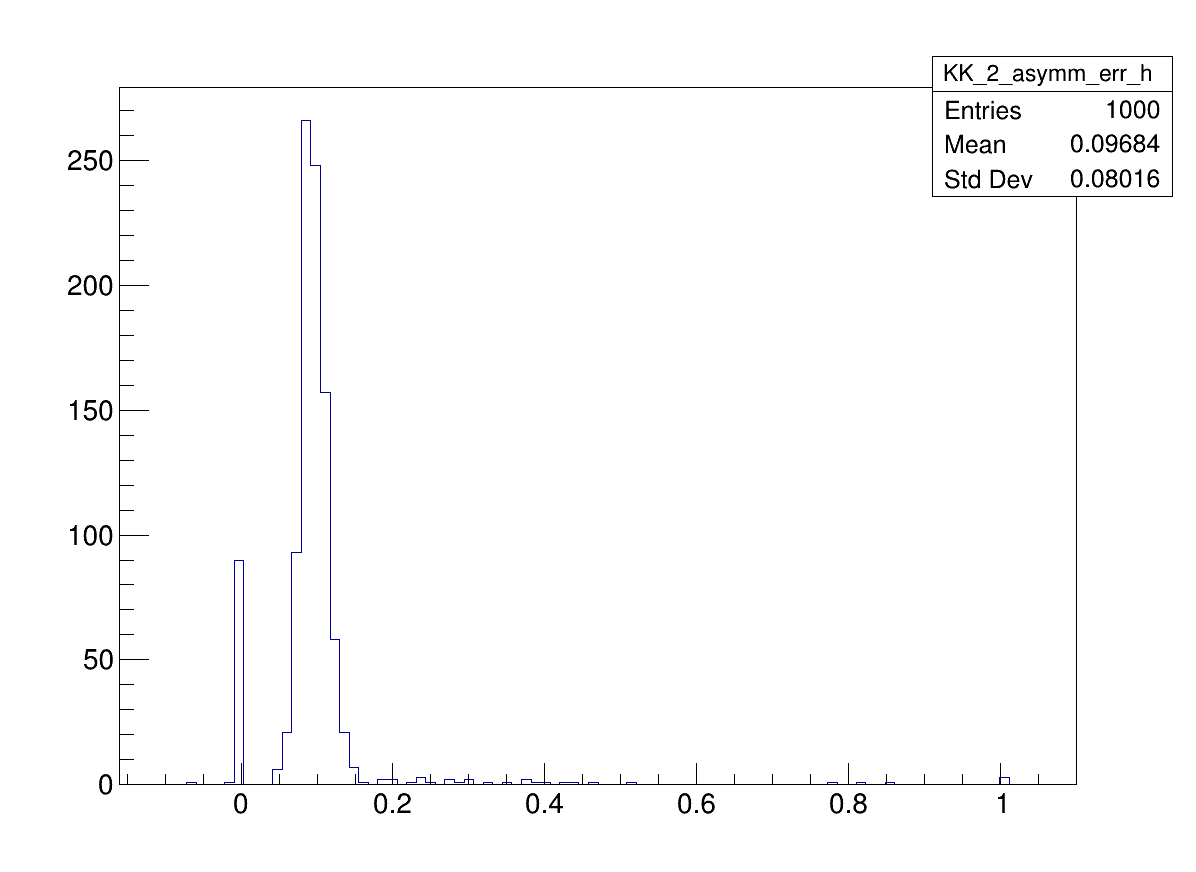

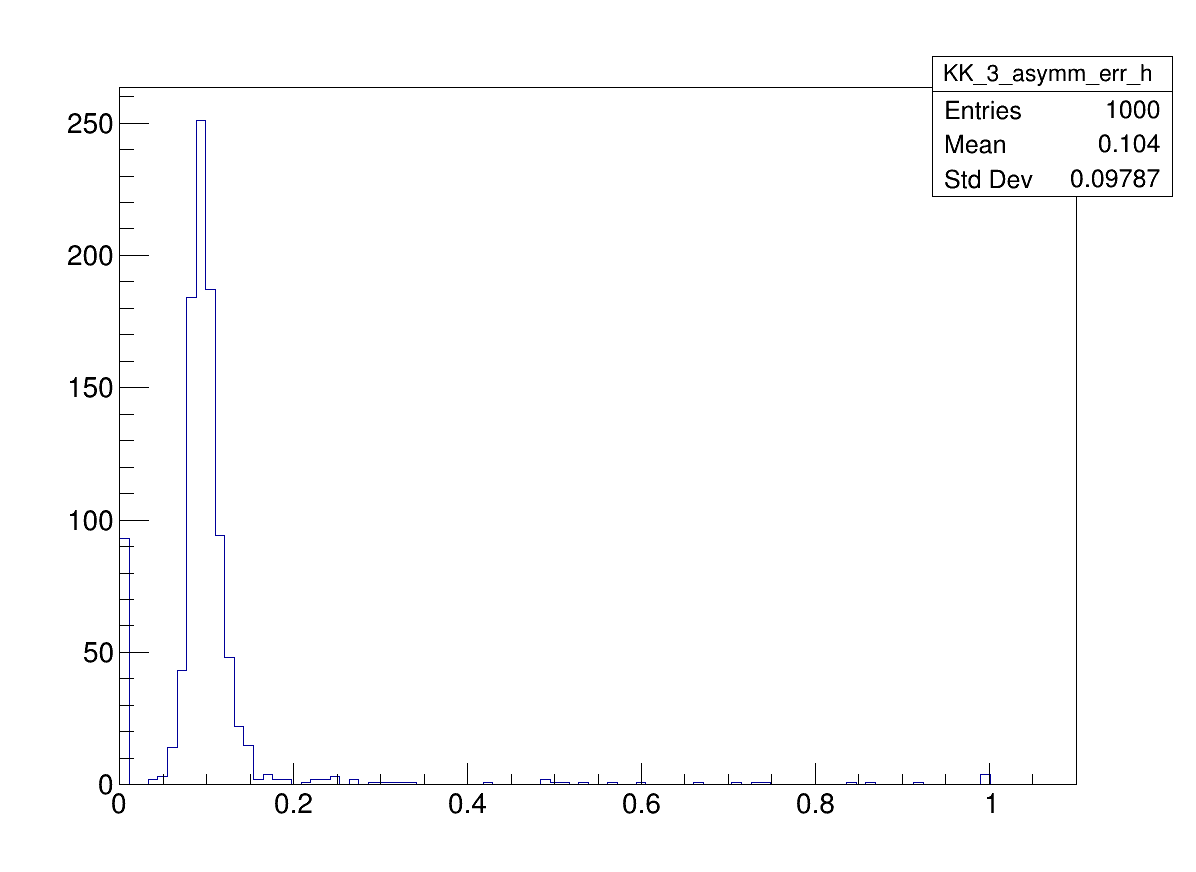

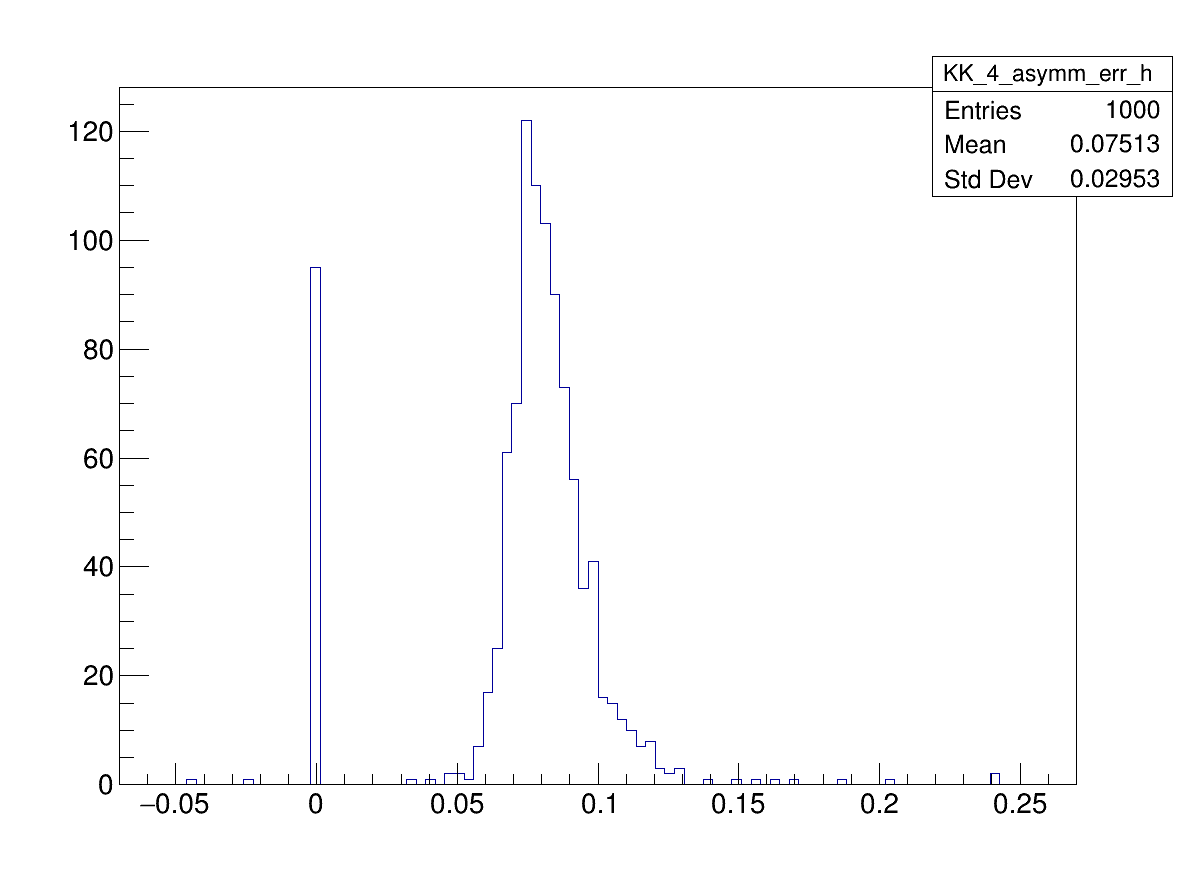

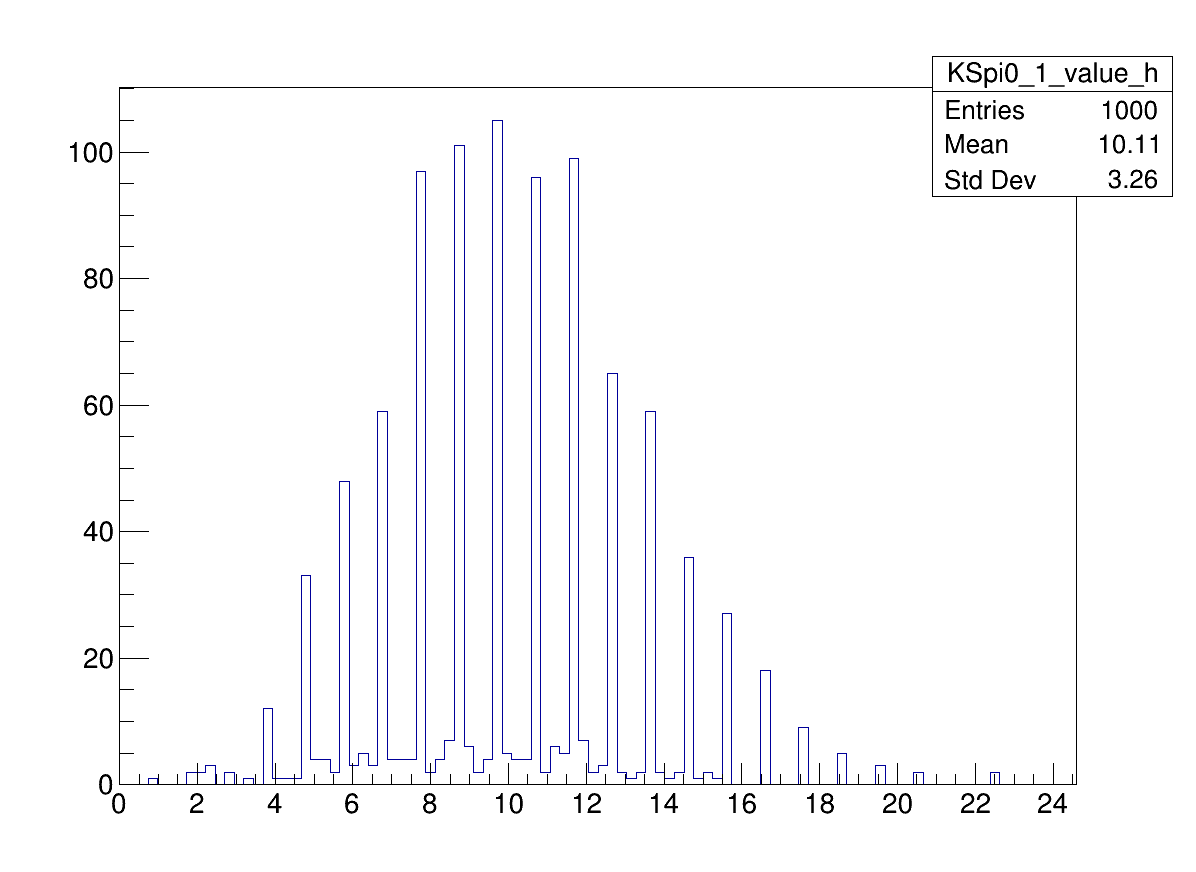

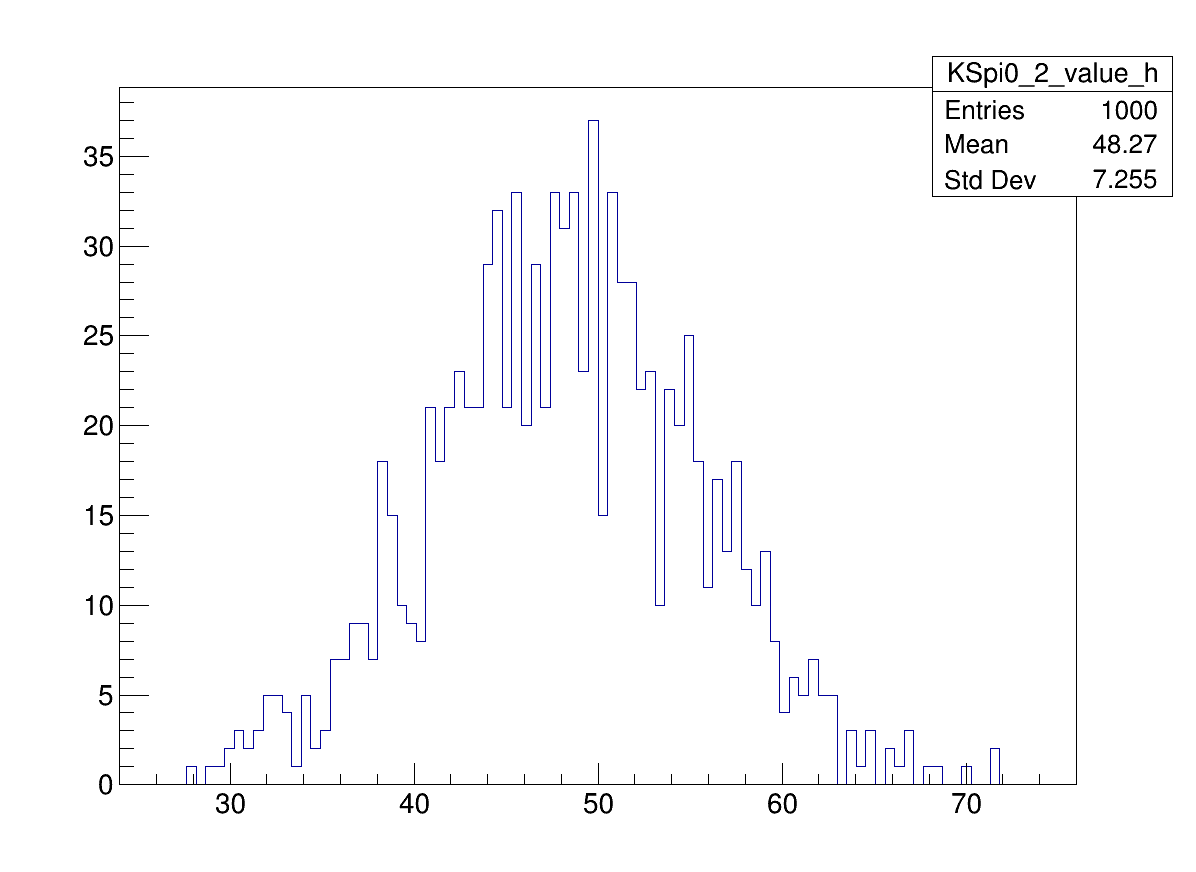

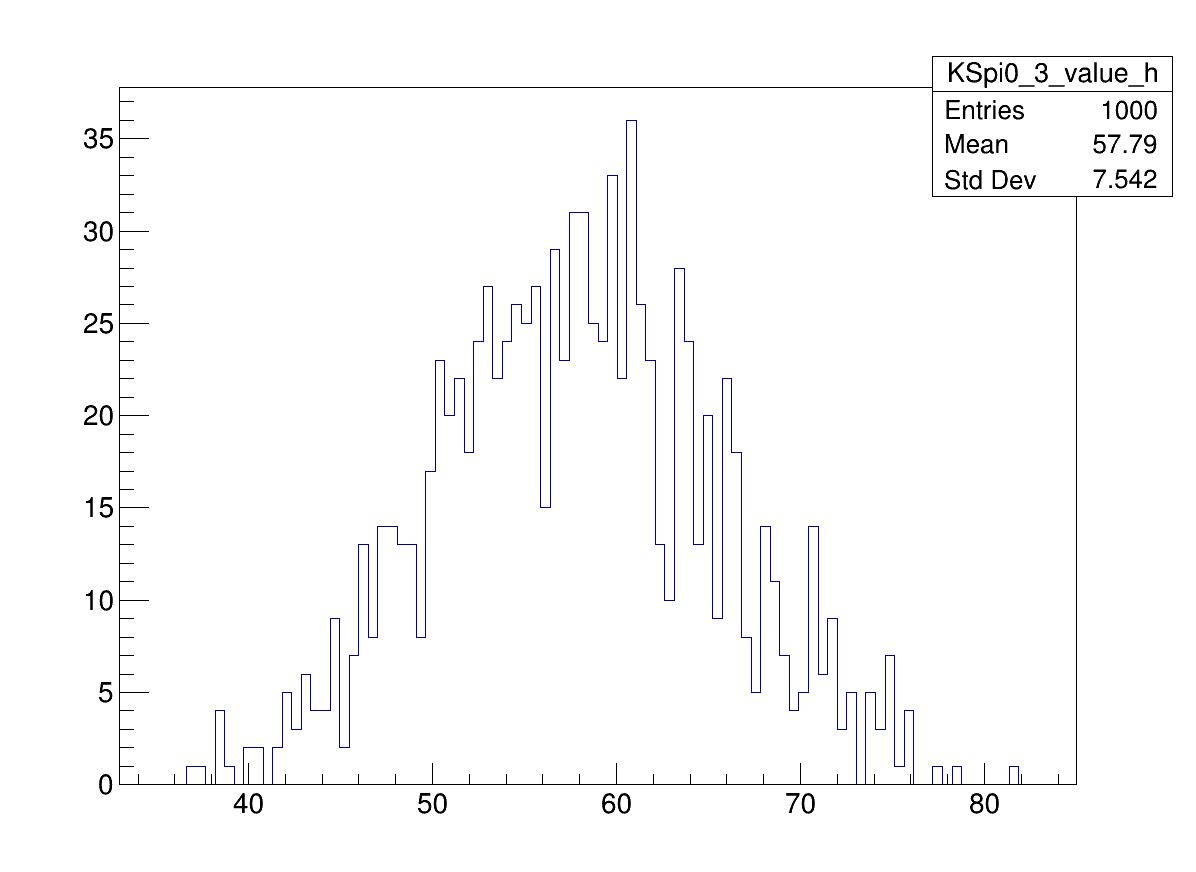

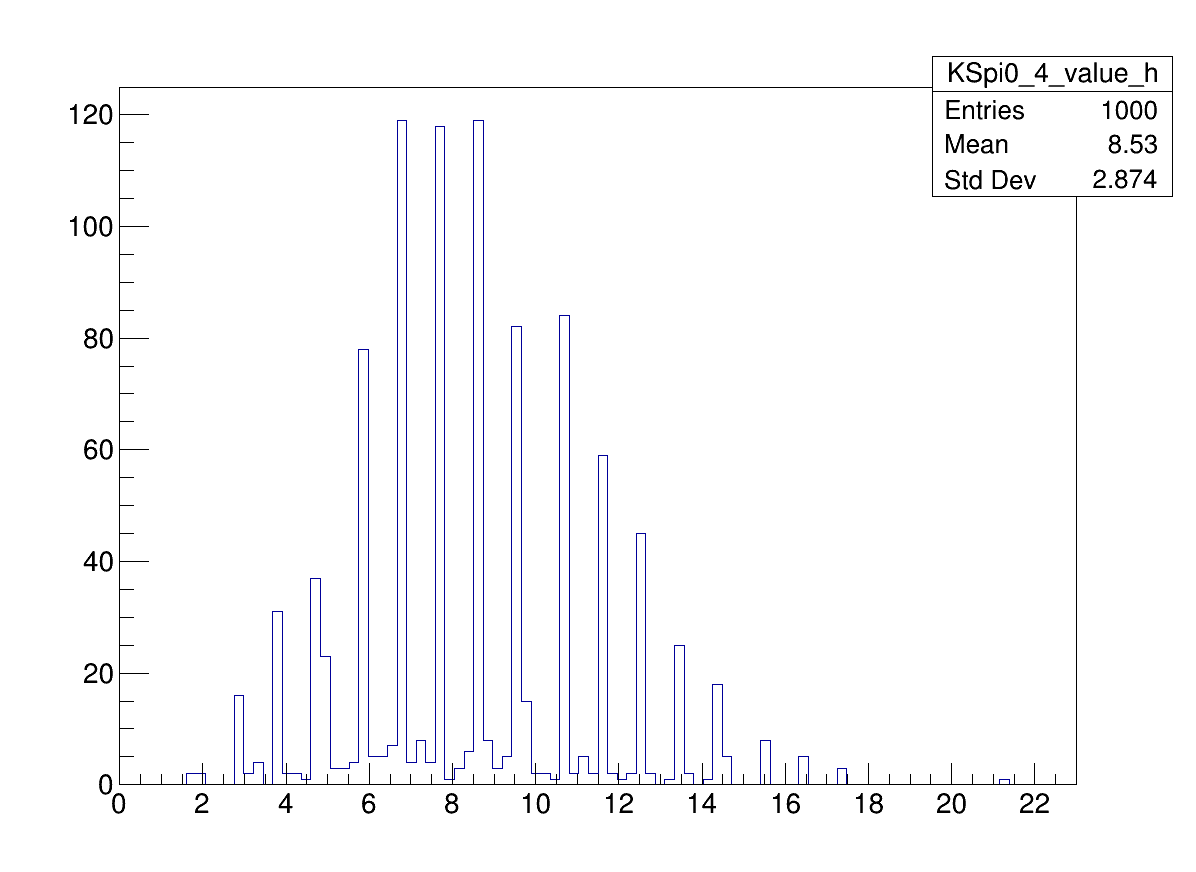

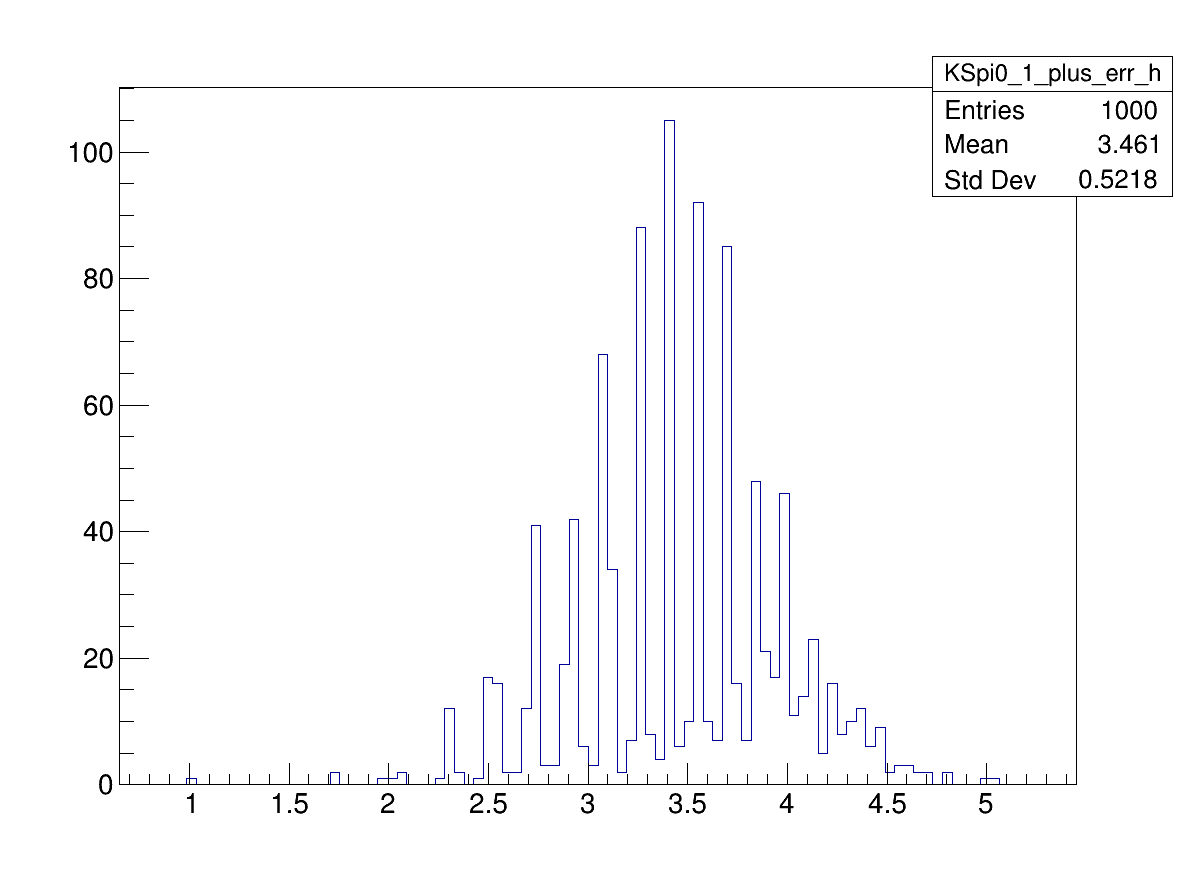

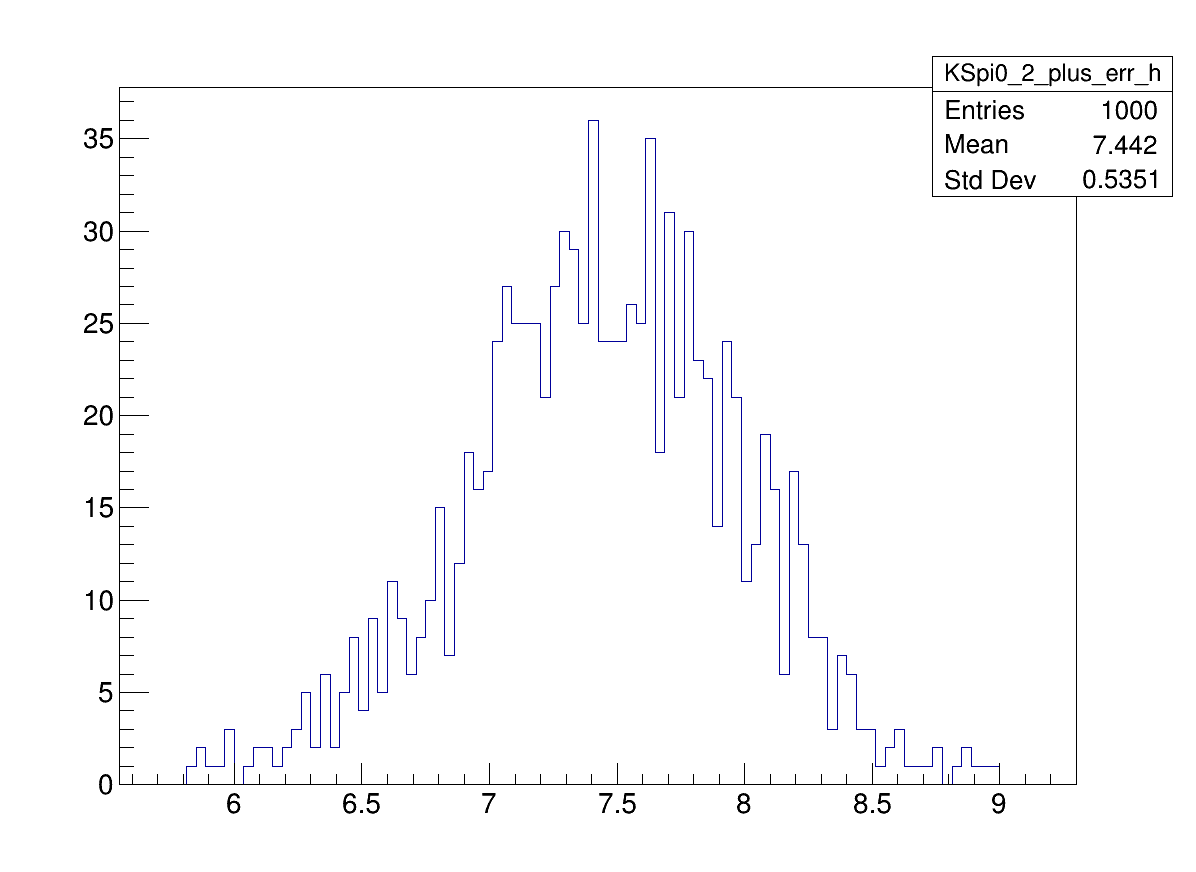

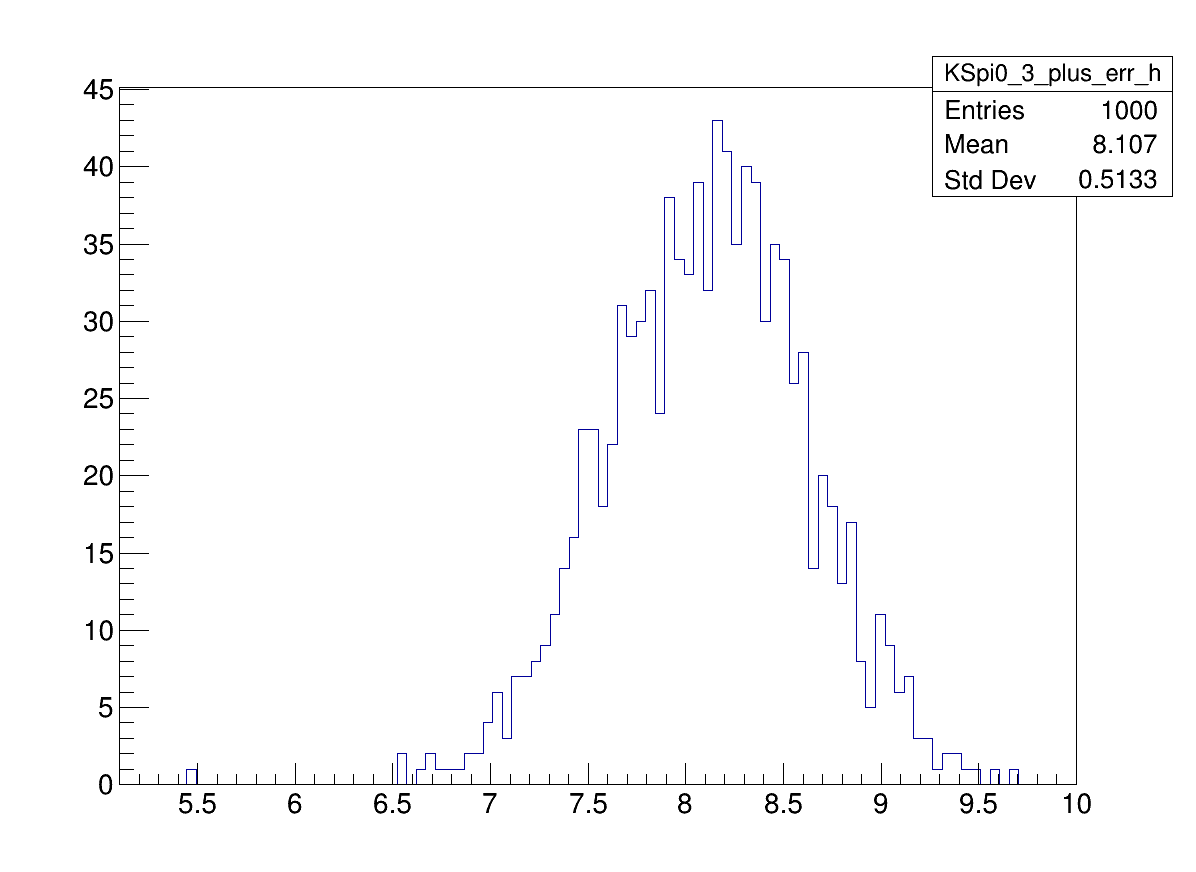

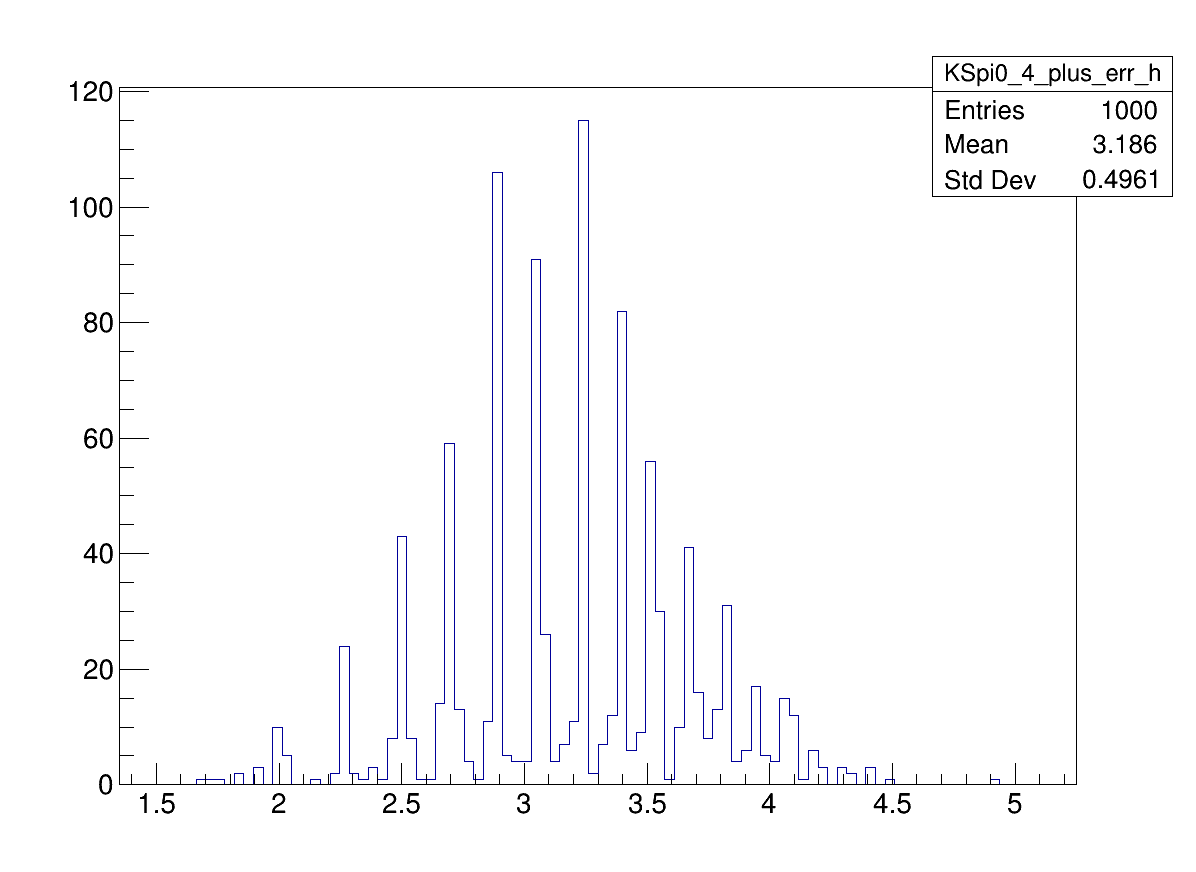

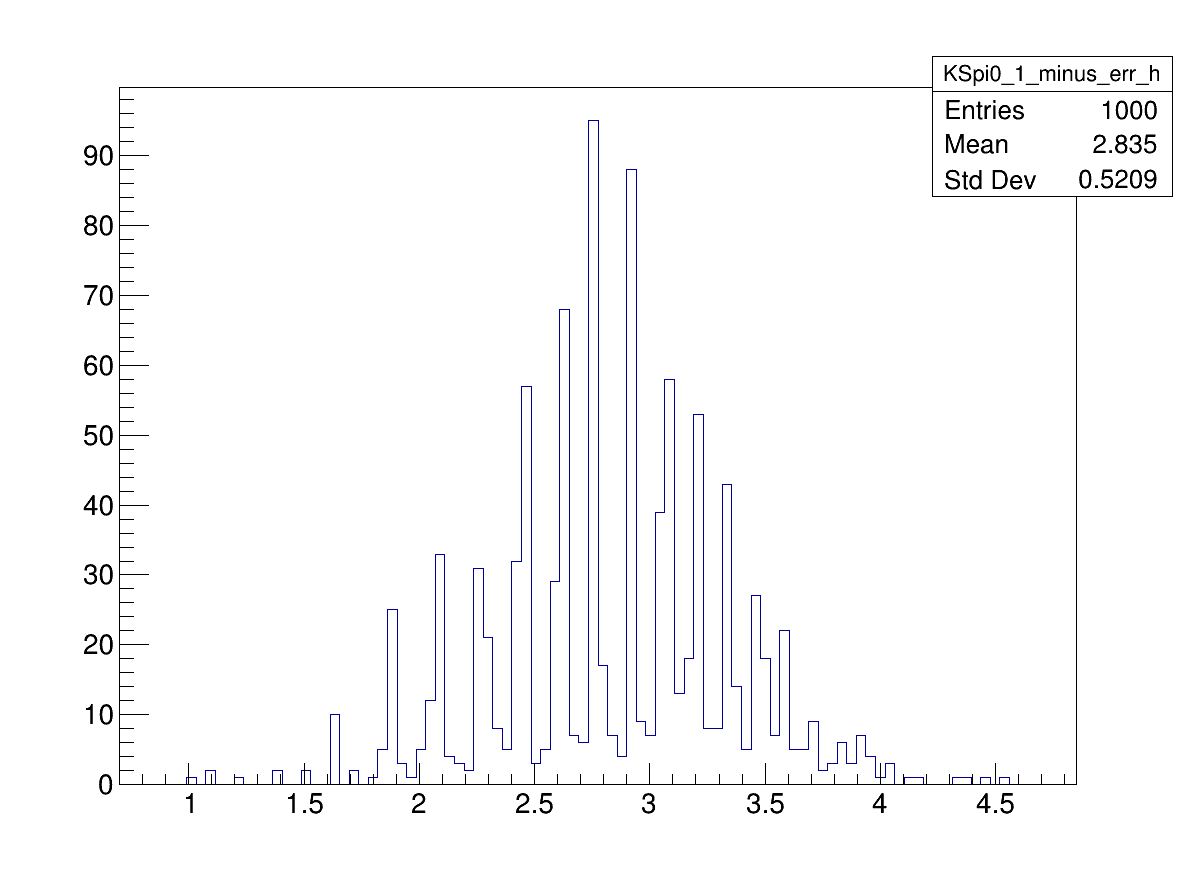

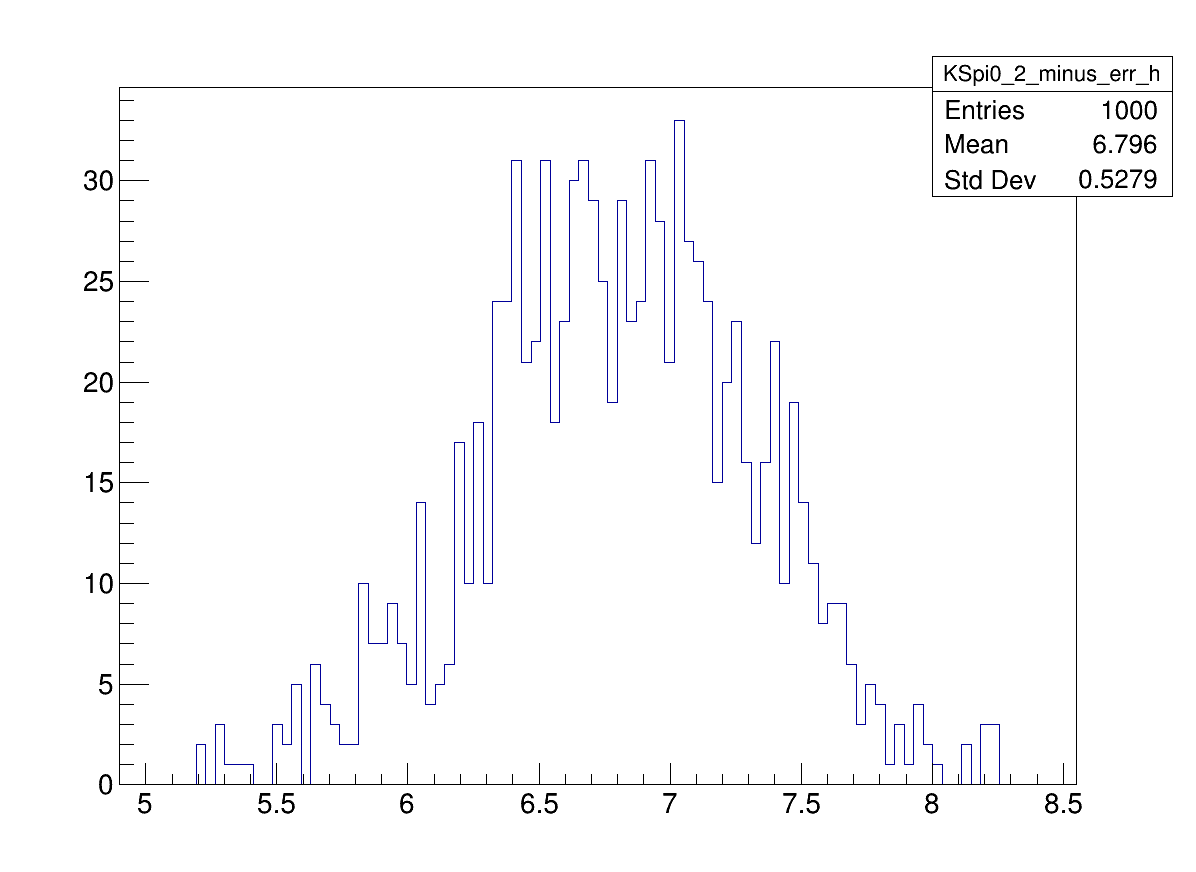

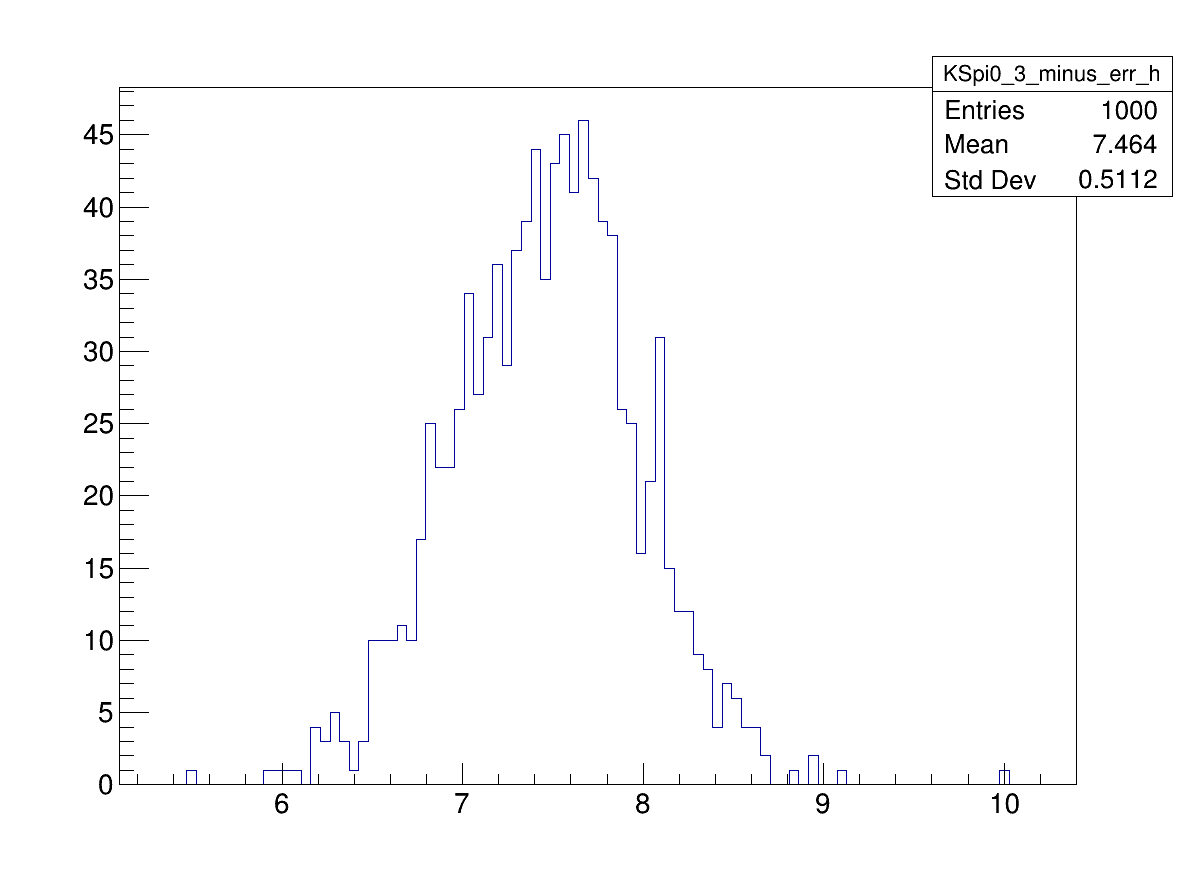

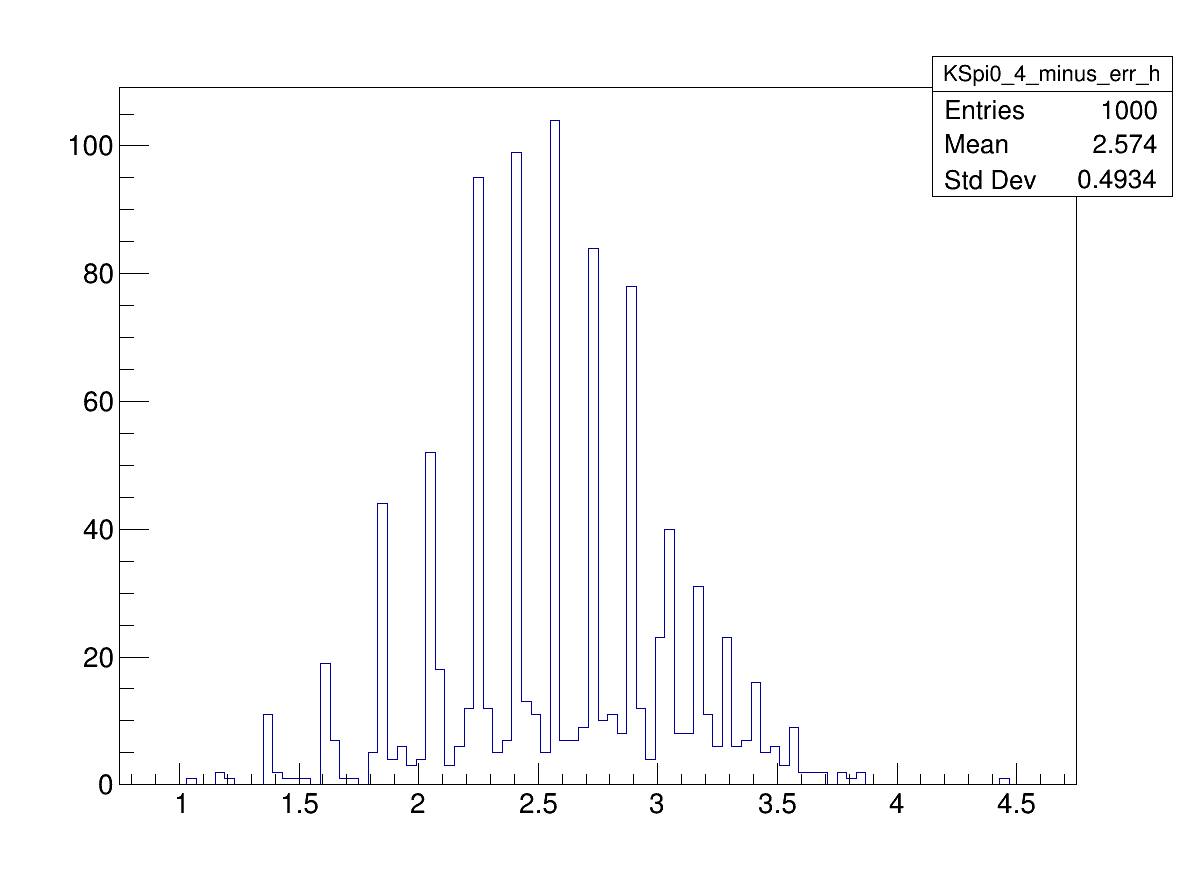

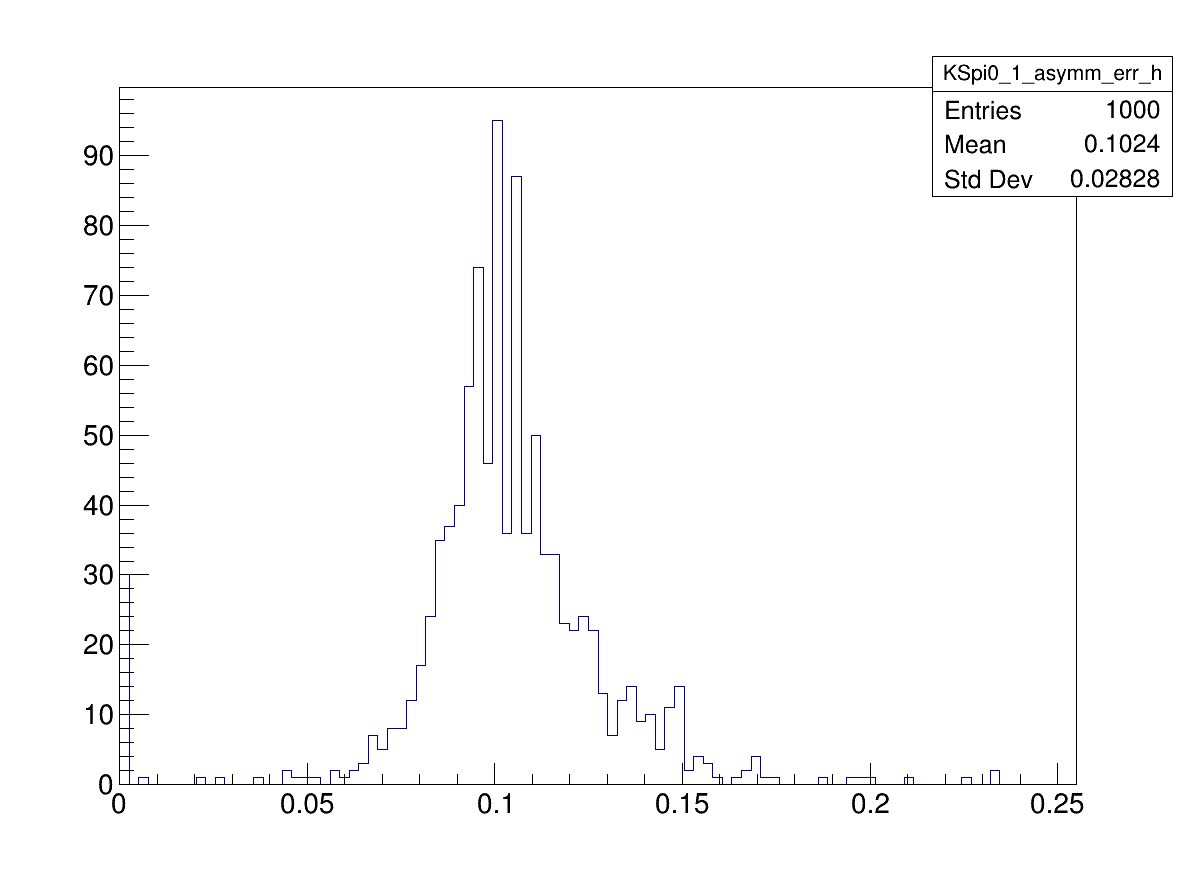

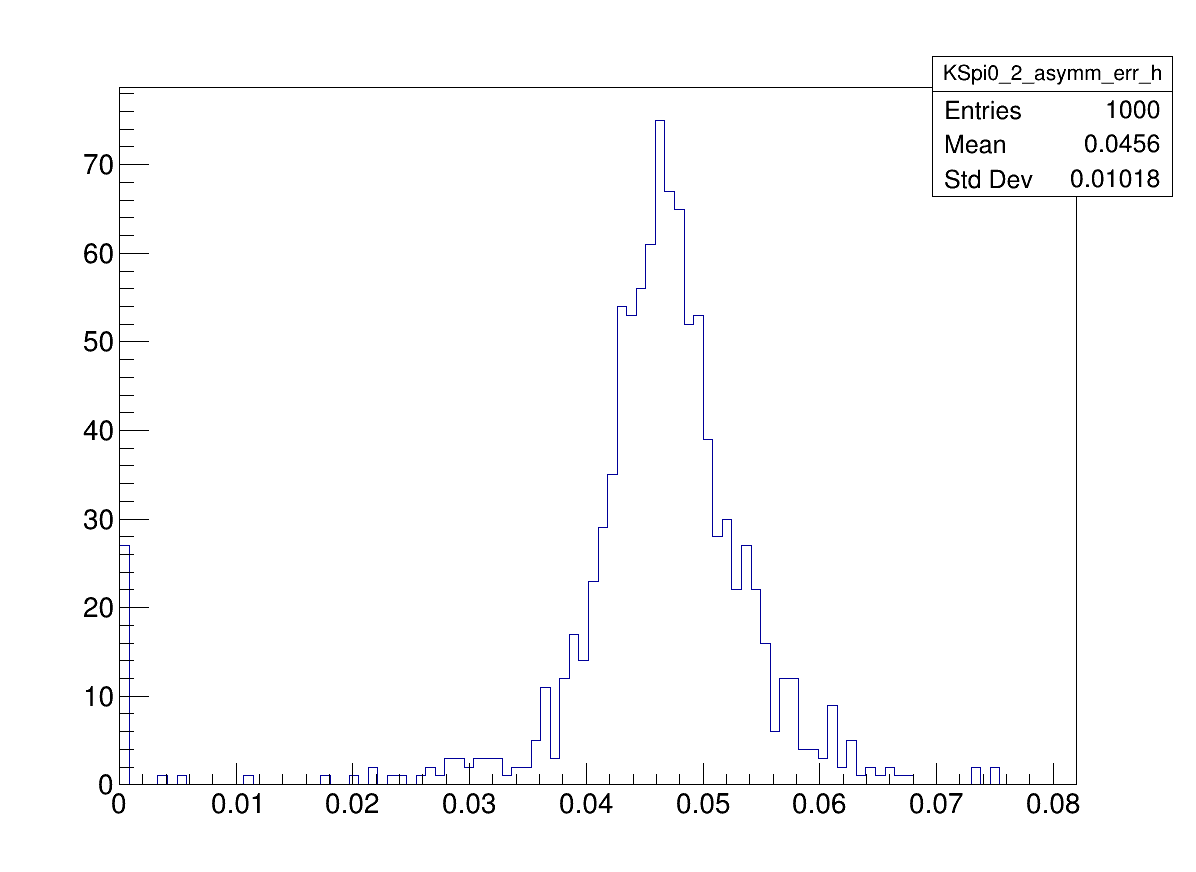

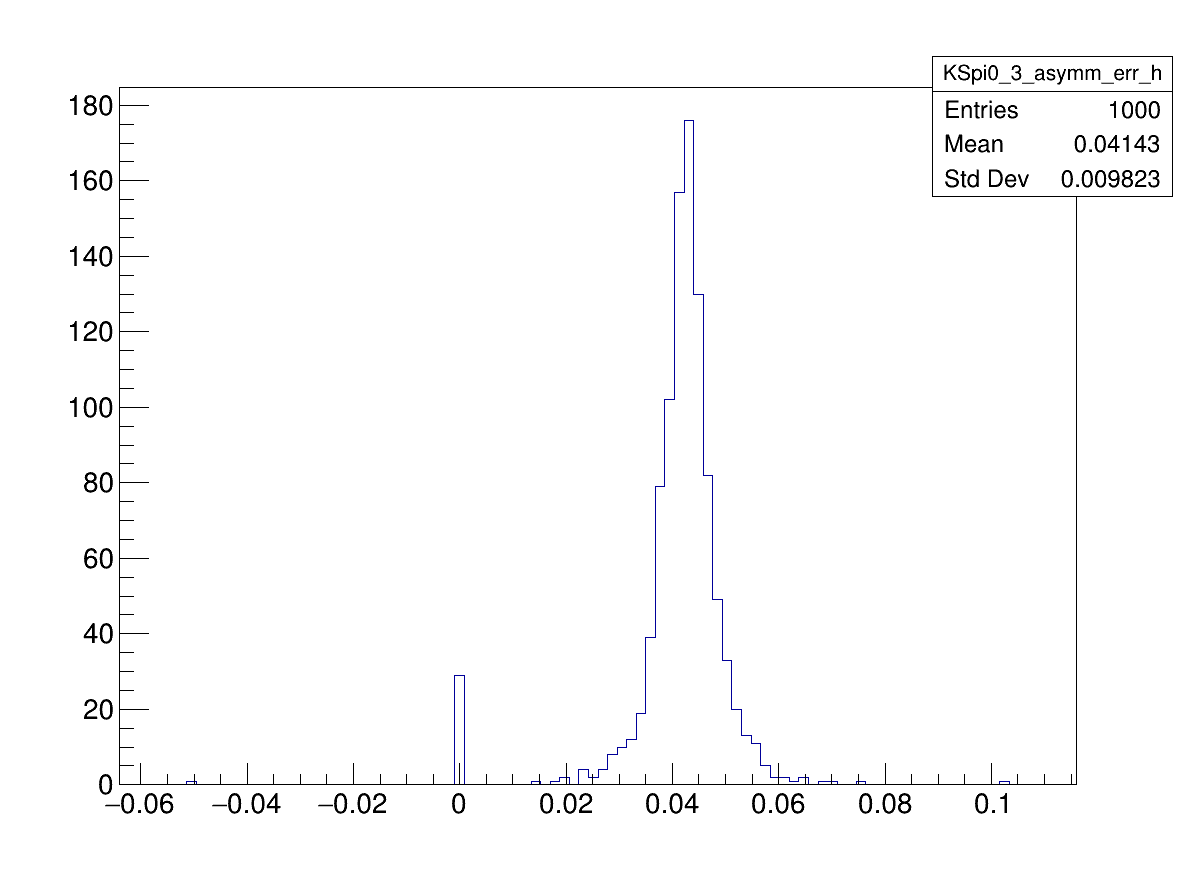

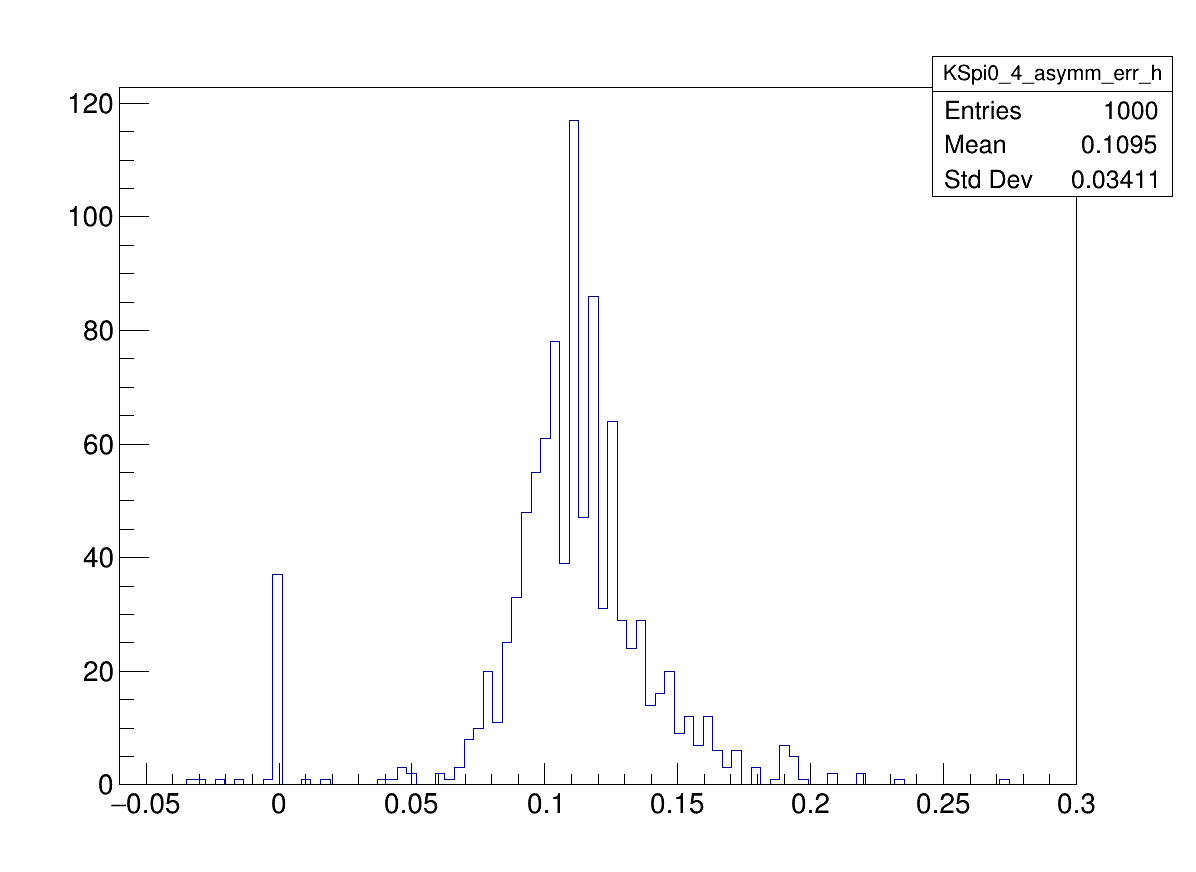

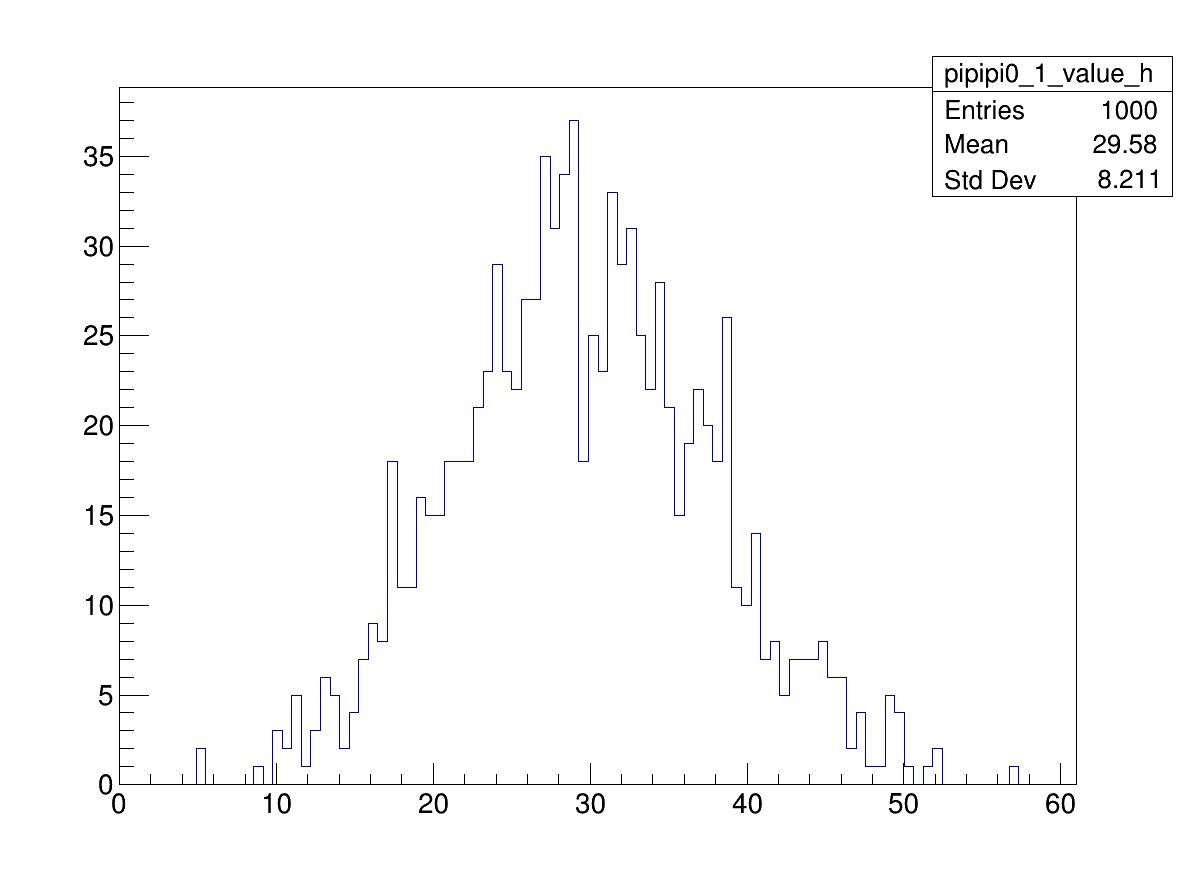

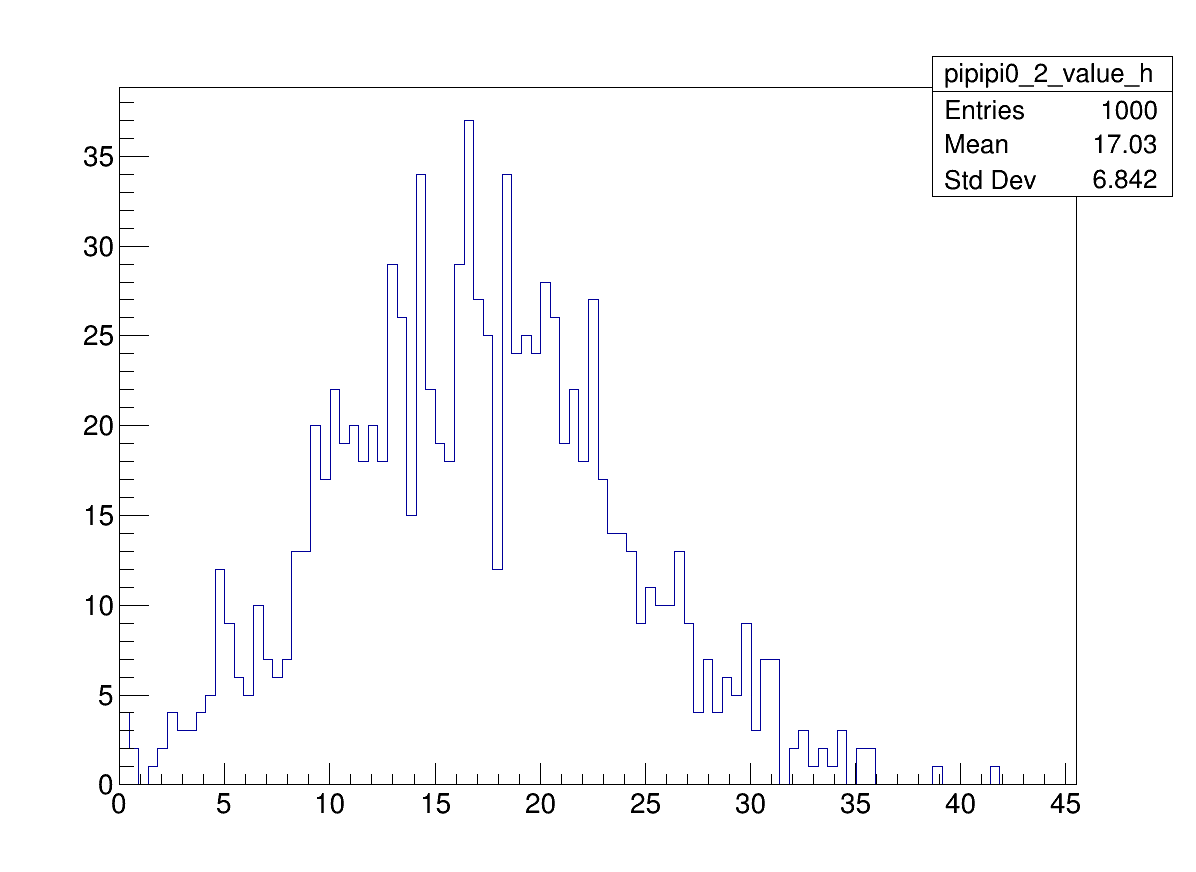

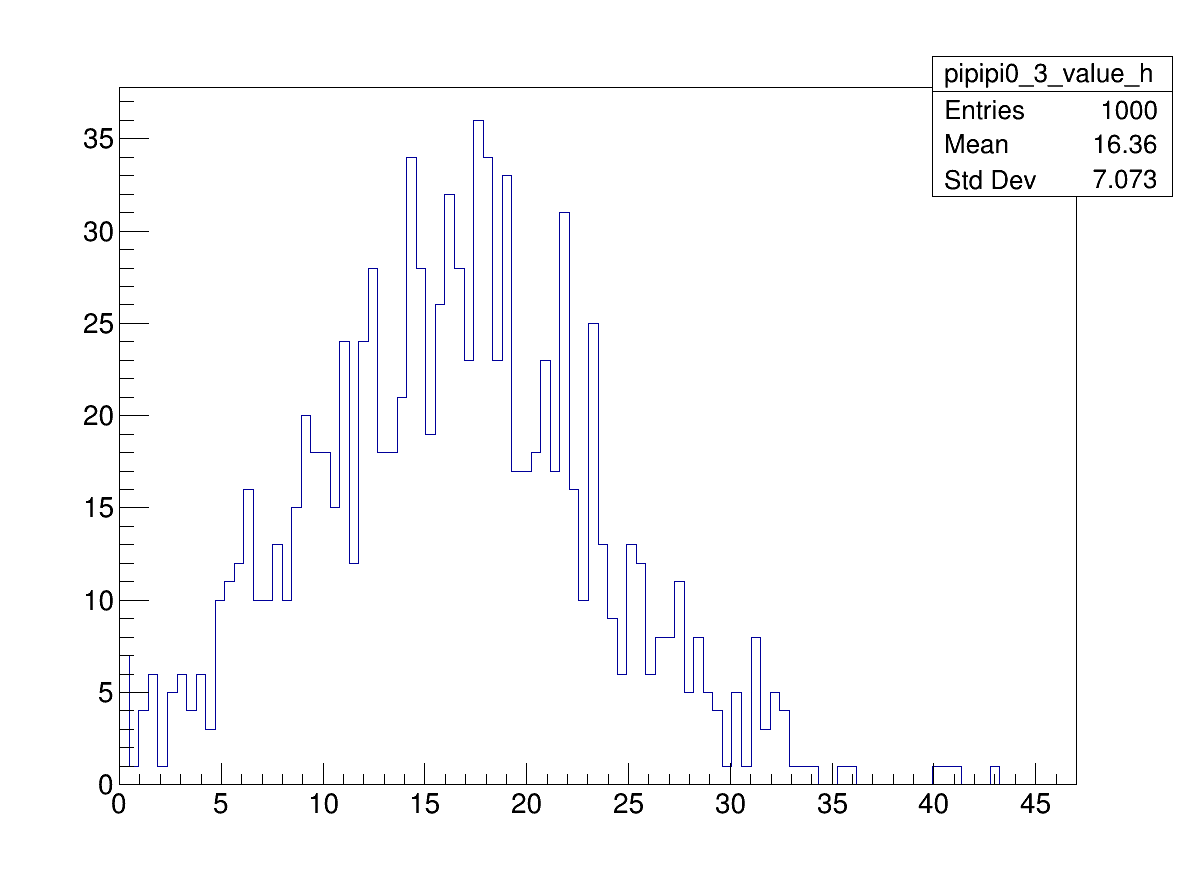

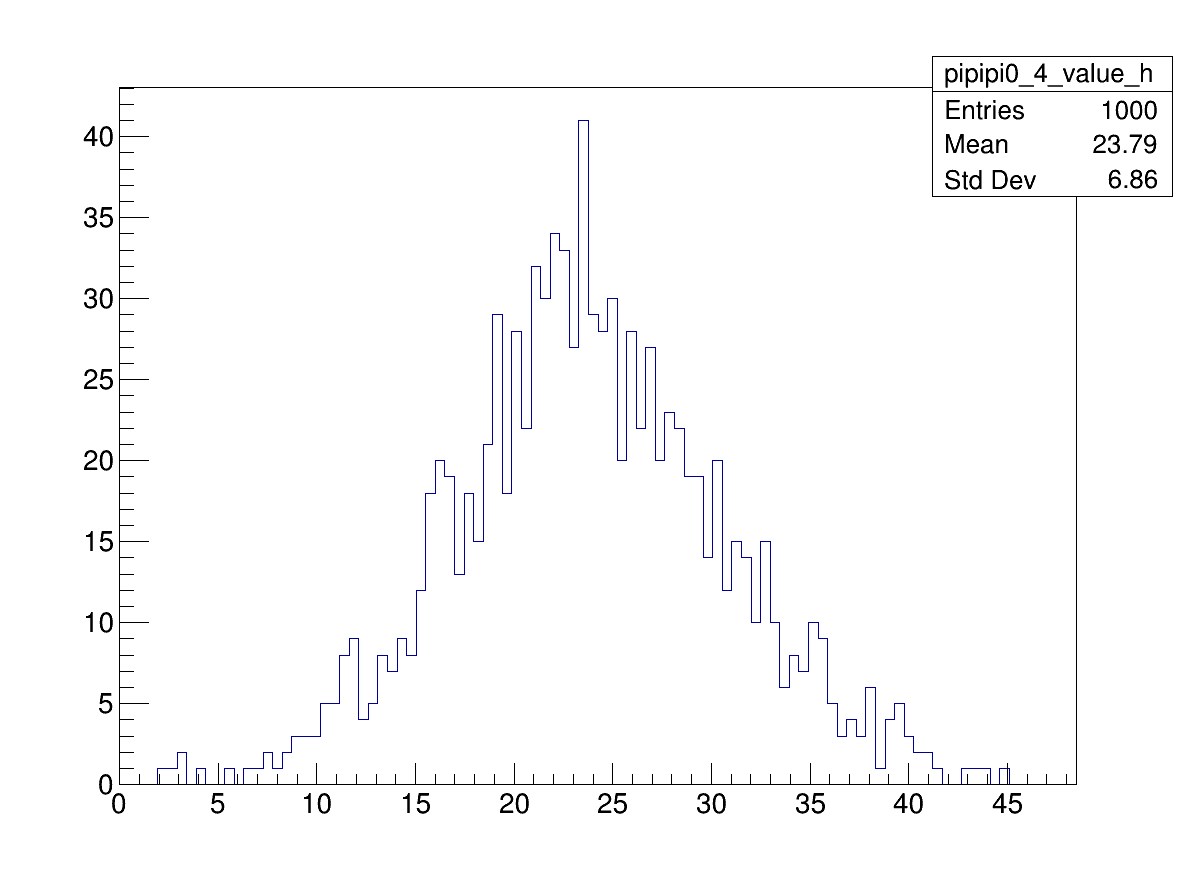

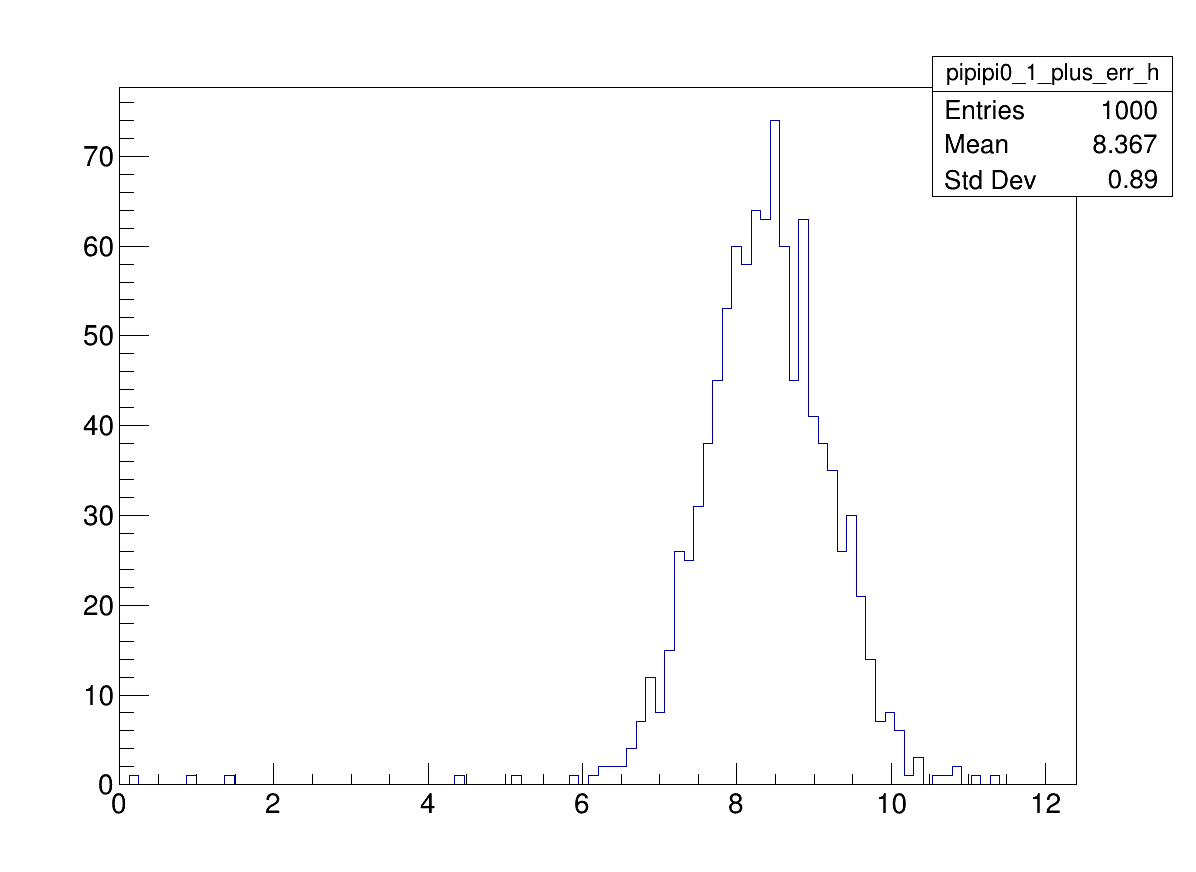

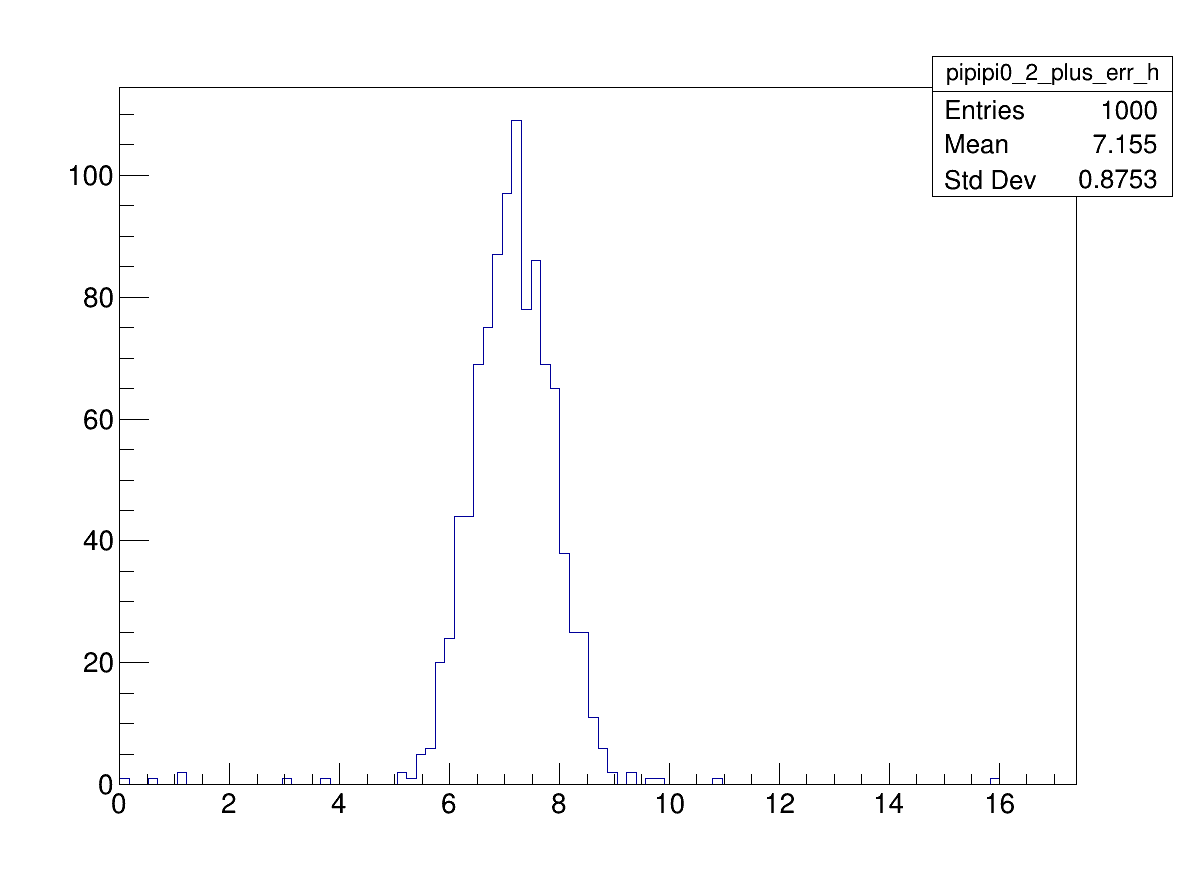

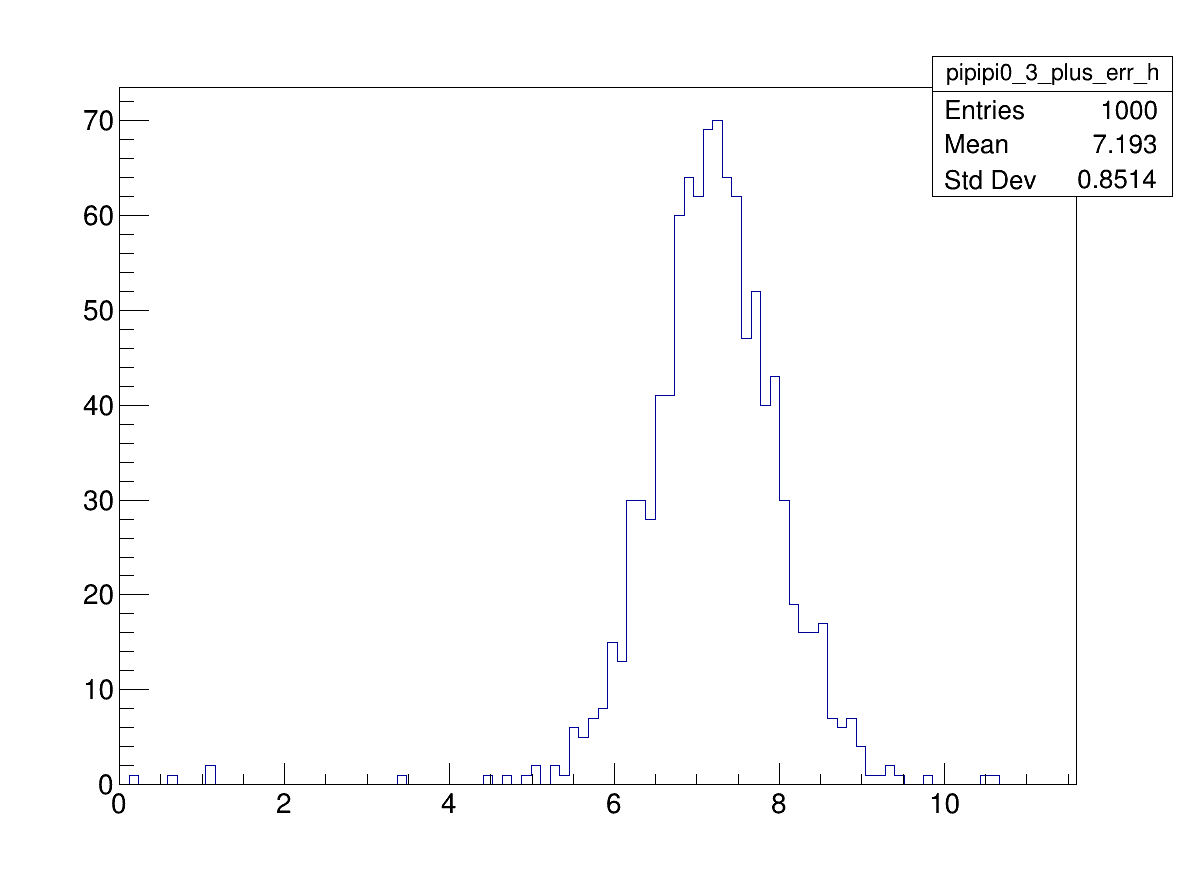

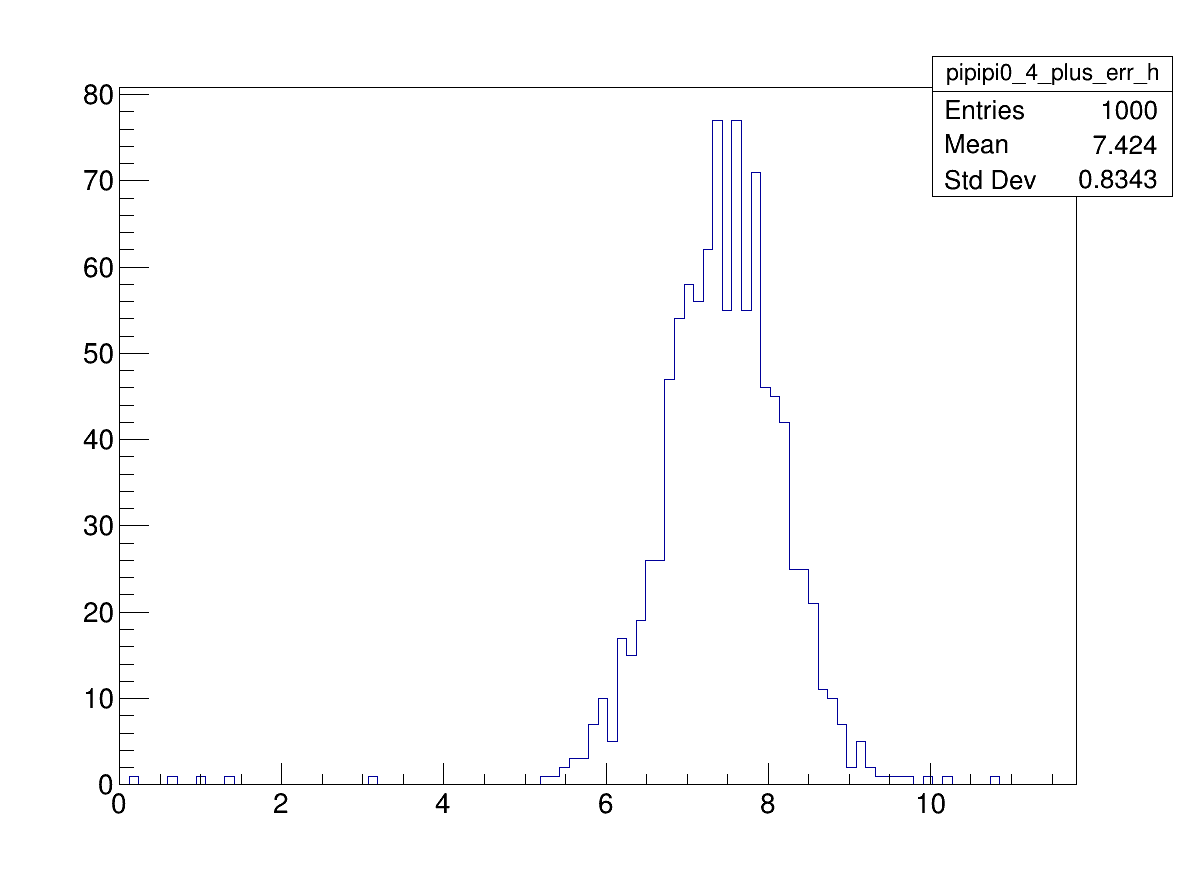

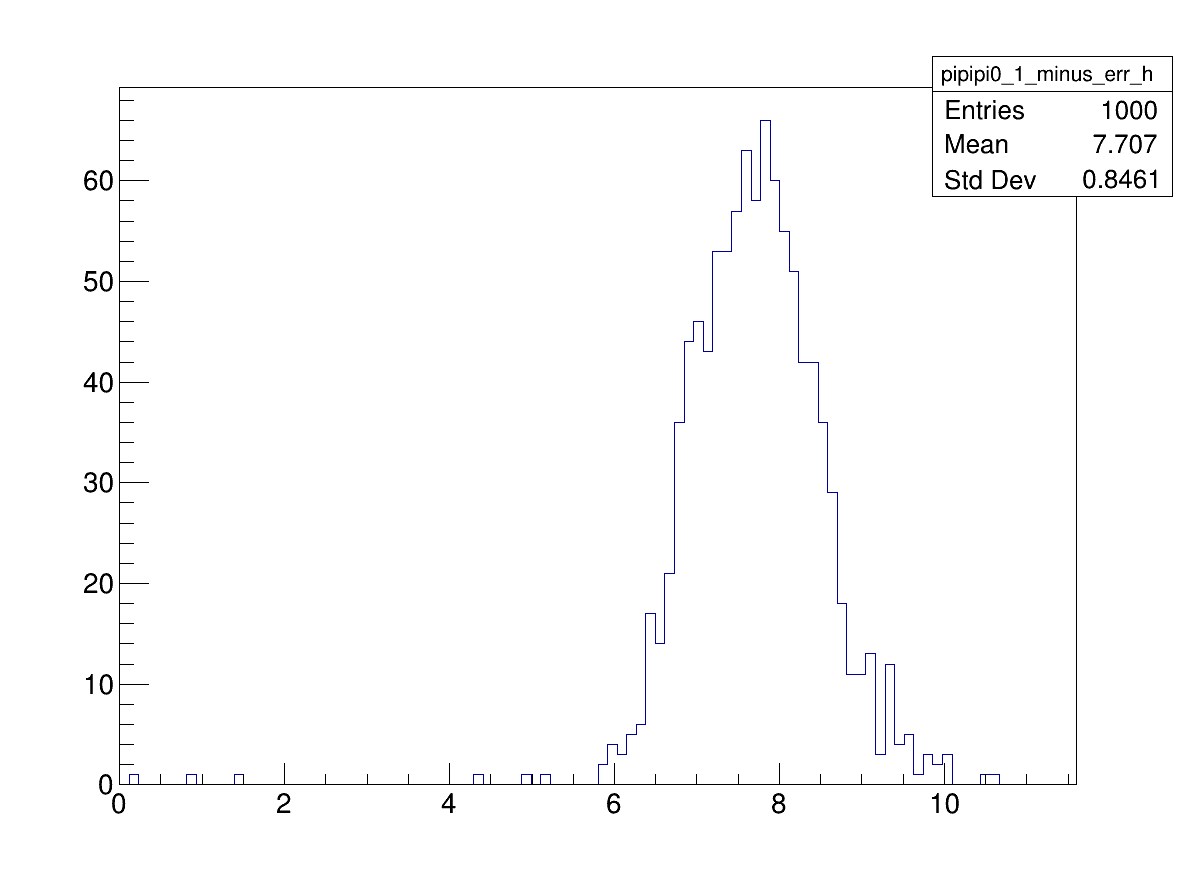

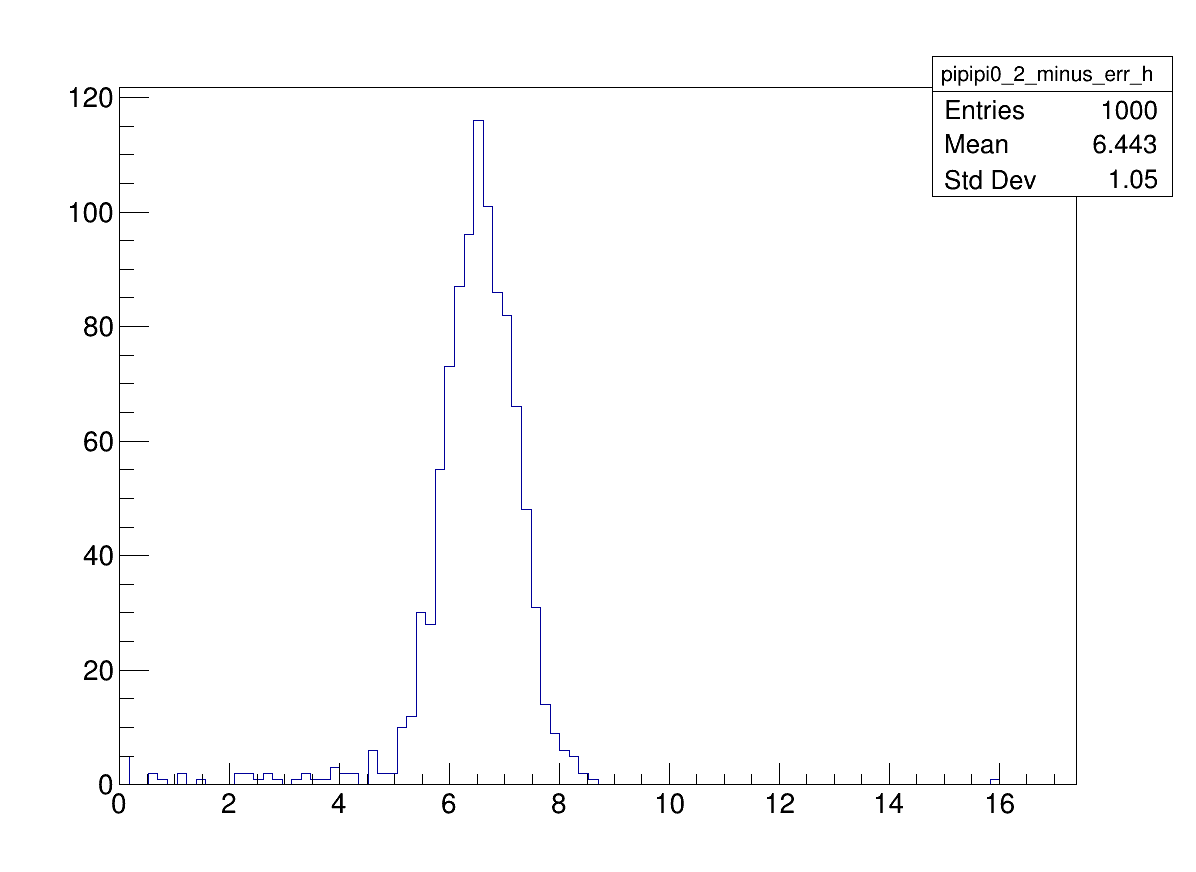

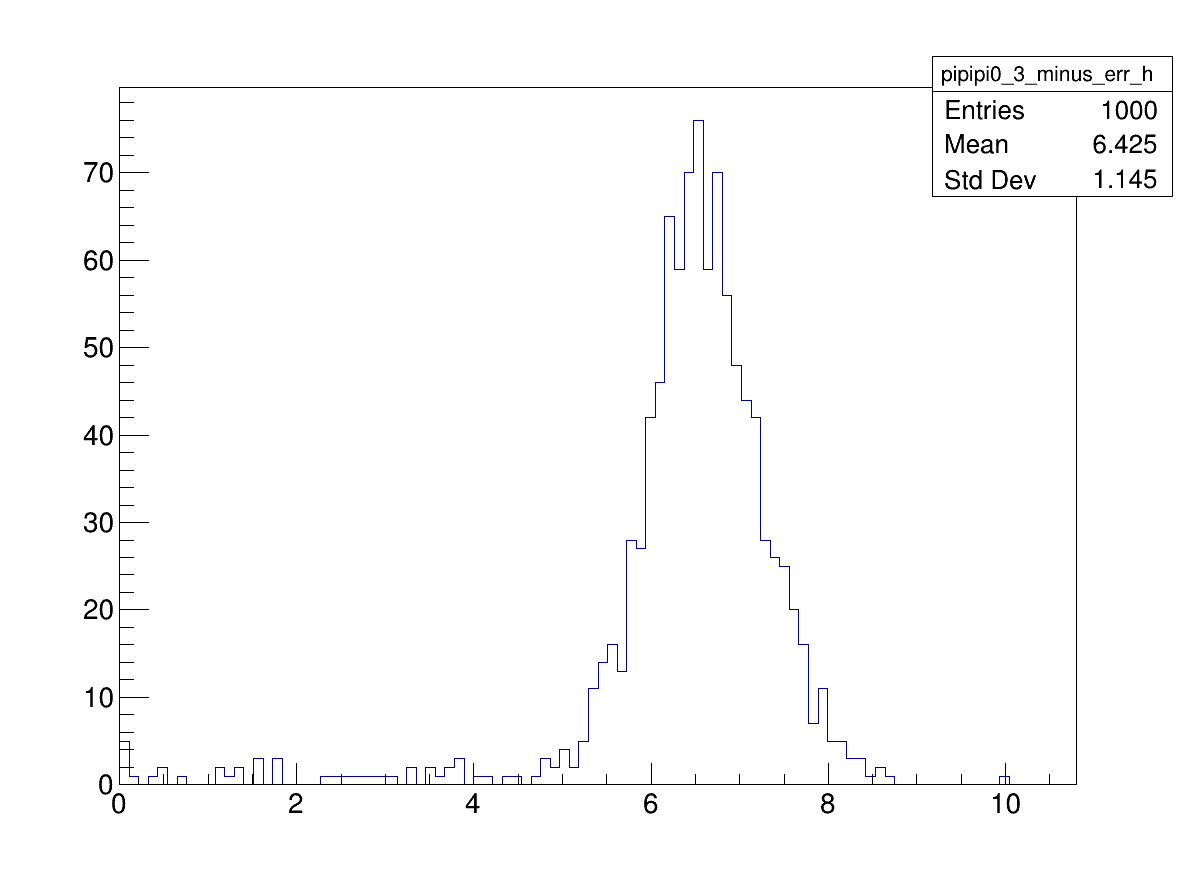

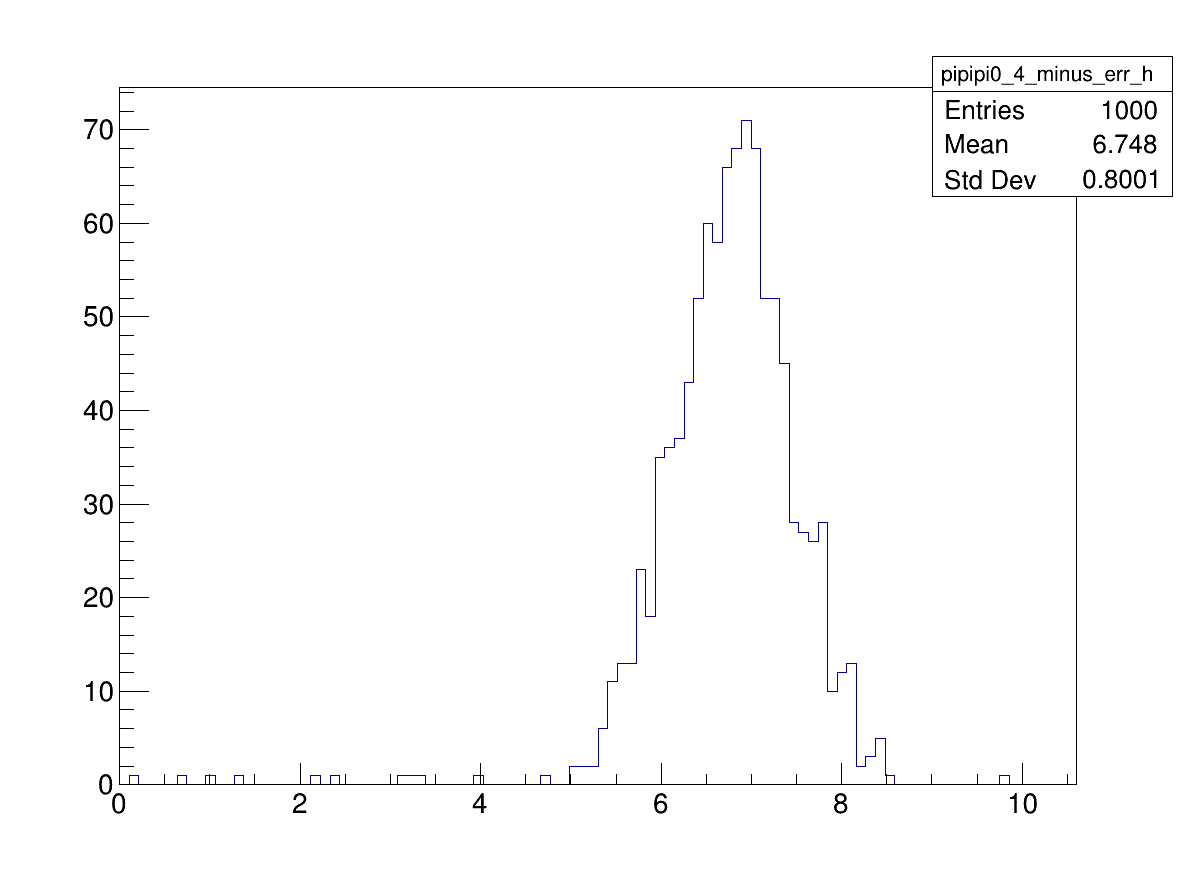

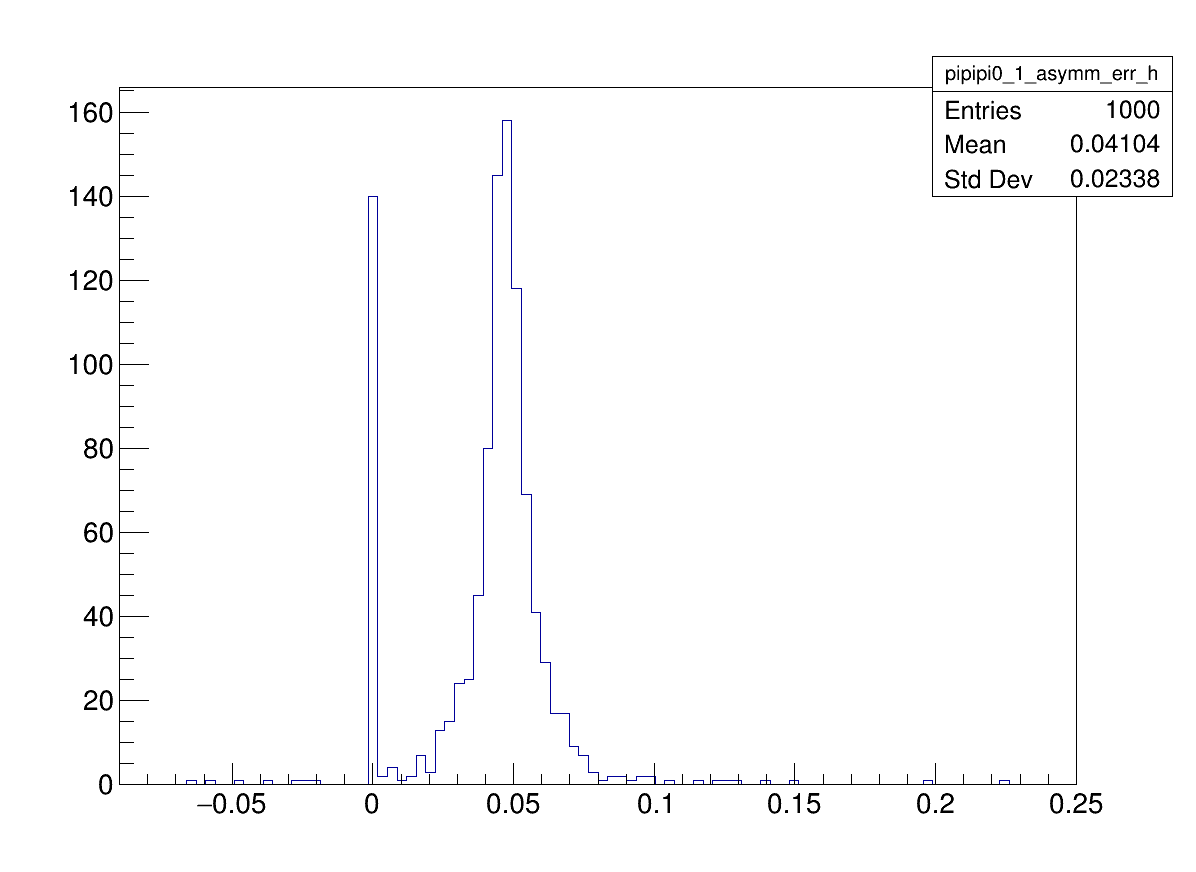

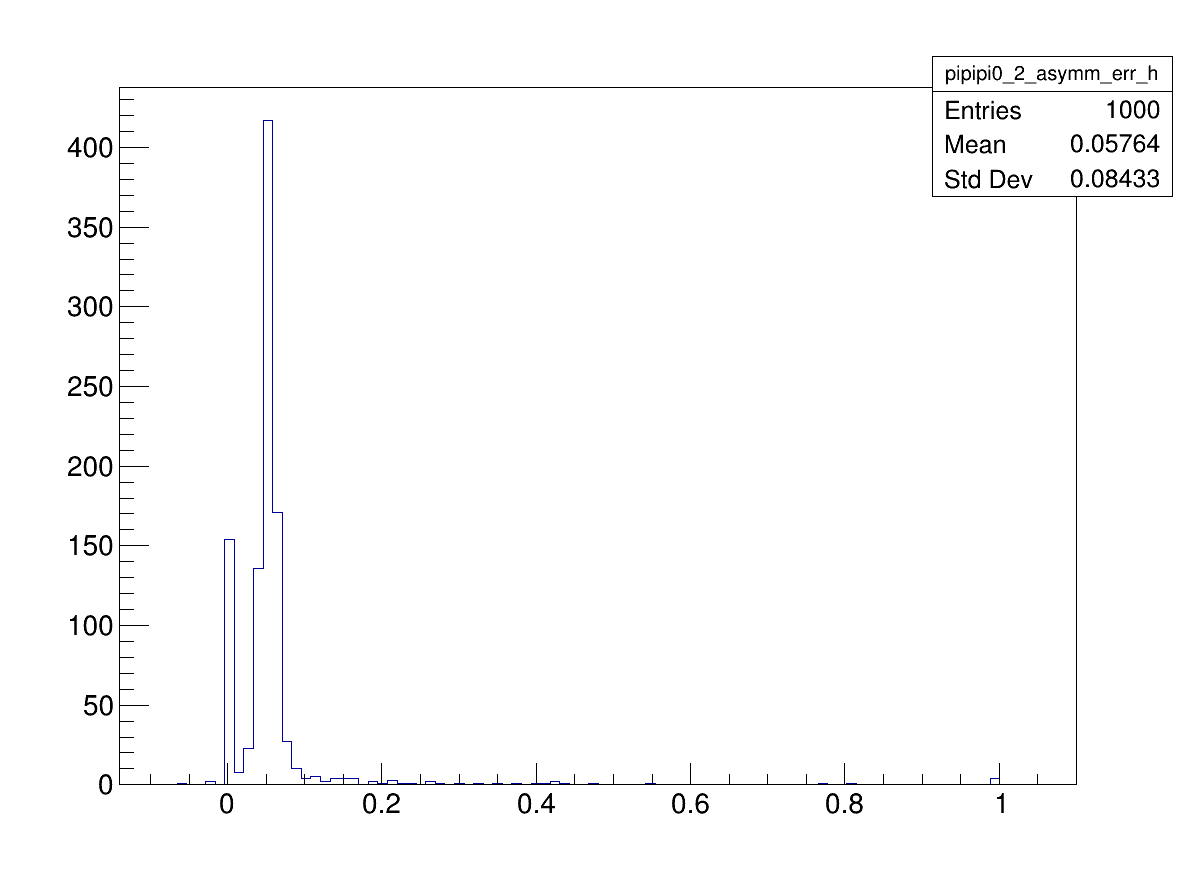

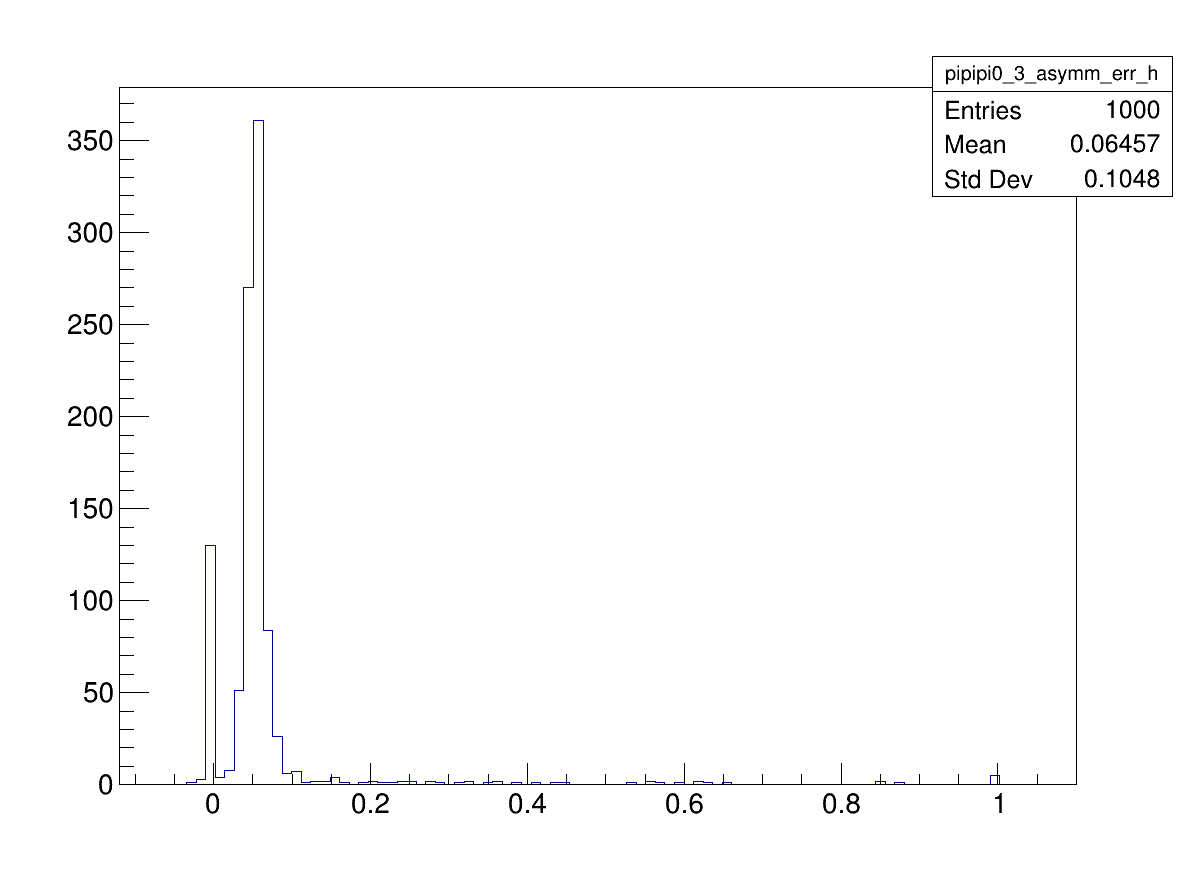

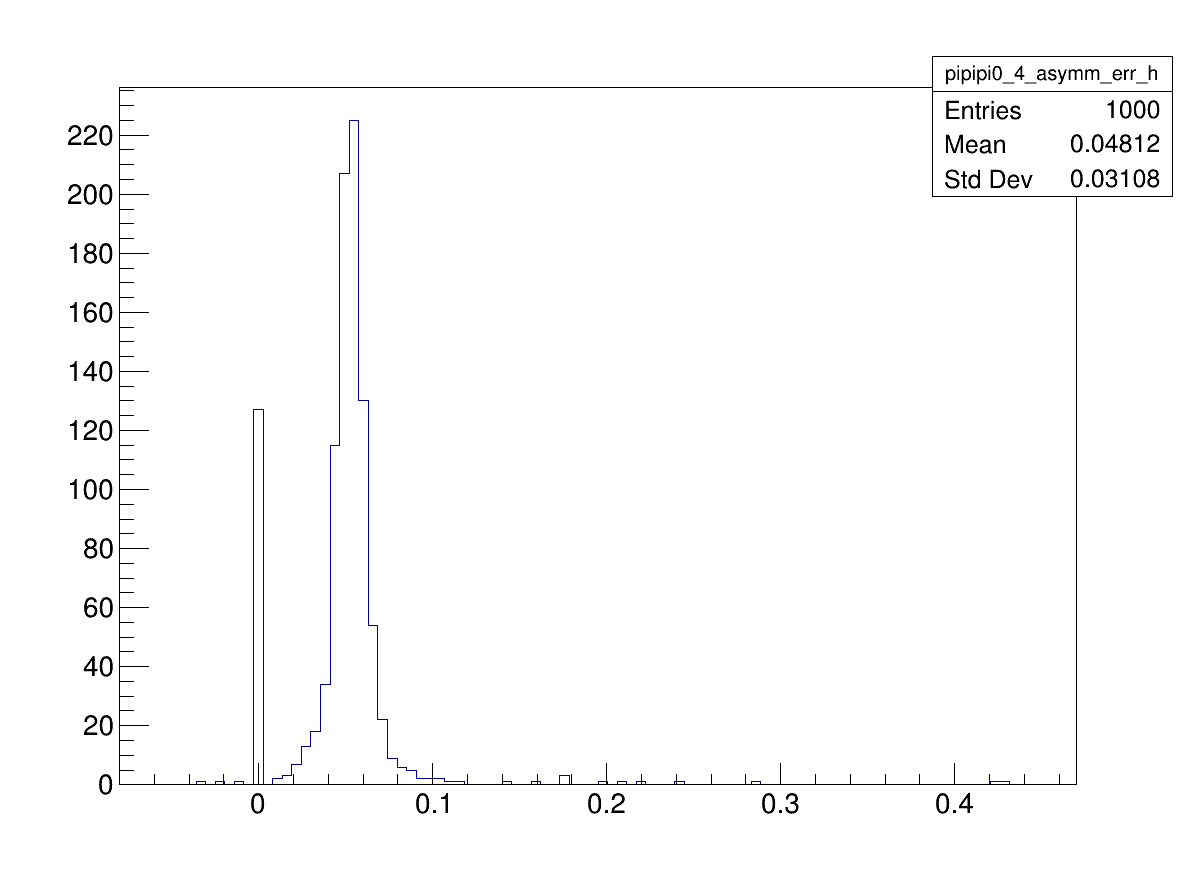

In [4]:
for(const auto &Tag : Tags) {
    std::map<std::size_t, TH1D*> Histograms_value, Histograms_plus_err,
                                 Histograms_minus_err, Histograms_asymm_err;
    for(std::size_t Bin = 1; Bin <= NumberBins; Bin++) {
        Histograms_value.insert({Bin, new TH1D((Tag + "_" + std::to_string(Bin) + "_value_h").c_str(),
                                "", 100, 0.0, 0.0)});
        Histograms_plus_err.insert({Bin, new TH1D((Tag + "_" + std::to_string(Bin) + "_plus_err_h").c_str(),
                                                  "", 100, 0.0, 0.0)});
        Histograms_minus_err.insert({Bin, new TH1D((Tag + "_" + std::to_string(Bin) + "_minus_err_h").c_str(),
                                                   "", 100, 0.0, 0.0)});
        Histograms_asymm_err.insert({Bin, new TH1D((Tag + "_" + std::to_string(Bin) + "_asymm_err_h").c_str(),
                                                   "", 100, 0.0, 0.0)});
    }
    for(std::size_t Toy = 0; Toy < NumberToys; Toy++) {
        std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/DoubleTagFit/";
        Filename += Tag + "/ToyFitResults/Toy" + std::to_string(Toy) + ".txt";
        const auto Yields = ParseParameters(Filename);
        for(std::size_t Bin = 1; Bin <= NumberBins; Bin++) {
            std::string Name = "DoubleTag_CP_KKpipi_vs_" + Tag + "_SignalBin";
            Name += std::to_string(Bin) + "_SignalYield";
            Histograms_value.at(Bin)->Fill(Yields.at(Name));
            double PlusError = Yields.at(Name + "_high_err");
            Histograms_plus_err.at(Bin)->Fill(PlusError);
            double MinusError = -Yields.at(Name + "_low_err");
            Histograms_minus_err.at(Bin)->Fill(MinusError);
            double Asymm = (PlusError - MinusError)/(PlusError + MinusError);
            Histograms_asymm_err.at(Bin)->Fill(Asymm);
        }
    }
    for(std::size_t Bin = 1; Bin <= NumberBins; Bin++) {
        TCanvas *c = new TCanvas((Tag + "_" + std::to_string(Bin) + "_value_h").c_str(), "", 1200, 900);
        Histograms_value.at(Bin)->Draw();
        c->Draw();
    }
    for(std::size_t Bin = 1; Bin <= NumberBins; Bin++) {
        TCanvas *c = new TCanvas((Tag + "_" + std::to_string(Bin) + "_plus_err_h").c_str(), "", 1200, 900);
        Histograms_plus_err.at(Bin)->Draw();
        c->Draw();
    }
    for(std::size_t Bin = 1; Bin <= NumberBins; Bin++) {
        TCanvas *c = new TCanvas((Tag + "_" + std::to_string(Bin) + "_minus_err_h").c_str(), "", 1200, 900);
        Histograms_minus_err.at(Bin)->Draw();
        c->Draw();
    }
    for(std::size_t Bin = 1; Bin <= NumberBins; Bin++) {
        TCanvas *c = new TCanvas((Tag + "_" + std::to_string(Bin) + "_asymm_err_h").c_str(), "", 1200, 900);
        Histograms_asymm_err.at(Bin)->Draw();
        c->Draw();
    }
}

### Then flavour tags

In [5]:
std::vector<std::string> Tags{/*"Kpi", "Kpipi0", "Kpipipi", "KeNu"*/};

In [6]:
for(const auto &Tag : Tags) {
    std::map<int, TH1D*> Histograms_value, Histograms_plus_err,
                                 Histograms_minus_err, Histograms_asymm_err;
    for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        Histograms_value.insert({Bin, new TH1D((Tag + "_" + BinName + "_value_h").c_str(), "",
                                               100, 0.0, 0.0)});
        Histograms_plus_err.insert({Bin, new TH1D((Tag + "_" + BinName + "_plus_err_h").c_str(), "",
                                                  100, 0.0, 0.0)});
        Histograms_minus_err.insert({Bin, new TH1D((Tag + "_" + BinName + "_minus_err_h").c_str(), "",
                                                   100, 0.0, 0.0)});
        Histograms_asymm_err.insert({Bin, new TH1D((Tag + "_" + BinName + "_asymm_err_h").c_str(), "",
                                                   100, 0.0, 0.0)});
    }
    for(int Toy = 0; Toy < NumberToys; Toy++) {
        std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/DoubleTagFit/";
        Filename += Tag + "/ToyFitResults/Toy" + std::to_string(Toy) + ".txt";
        const auto Yields = ParseParameters(Filename);
        for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
            if(Bin == 0) {
                continue;
            }
            std::string Name = "DoubleTag_Flavour_KKpipi_vs_" + Tag + "_SignalBin";
            std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
            Name += BinName + "_TagBin0" + "_SignalYield";
            Histograms_value.at(Bin)->Fill(Yields.at(Name));
            double PlusError = Yields.at(Name + "_high_err");
            Histograms_plus_err.at(Bin)->Fill(PlusError);
            double MinusError = -Yields.at(Name + "_low_err");
            Histograms_minus_err.at(Bin)->Fill(MinusError);
            double Asymm = (PlusError - MinusError)/(PlusError + MinusError);
            Histograms_asymm_err.at(Bin)->Fill(Asymm);
        }
    }
    for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        TCanvas *c = new TCanvas((Tag + "_" + BinName + "_value_h").c_str(), "", 1200, 900);
        Histograms_value.at(Bin)->Draw();
        c->Draw();
    }
    for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        TCanvas *c = new TCanvas((Tag + "_" + BinName + "_plus_err_h").c_str(), "", 1200, 900);
        Histograms_plus_err.at(Bin)->Draw();
        c->Draw();
    }
    for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        TCanvas *c = new TCanvas((Tag + "_" + BinName + "_minus_err_h").c_str(), "", 1200, 900);
        Histograms_minus_err.at(Bin)->Draw();
        c->Draw();
    }
    for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        TCanvas *c = new TCanvas((Tag + "_" + BinName + "_asymm_err_h").c_str(), "", 1200, 900);
        Histograms_asymm_err.at(Bin)->Draw();
        c->Draw();
    }
}

### Finally the SCMB tags

In [7]:
std::vector<std::string> Tags{"KSpipi"};

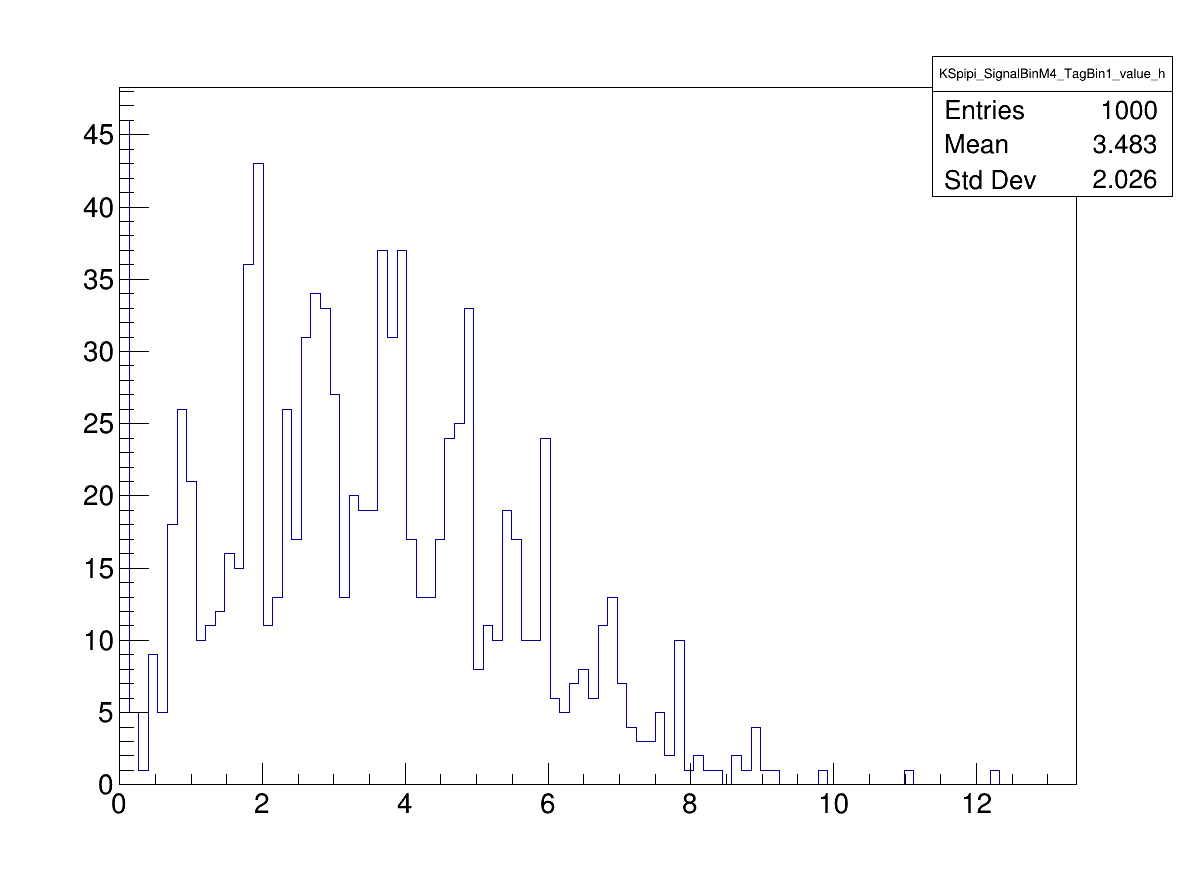

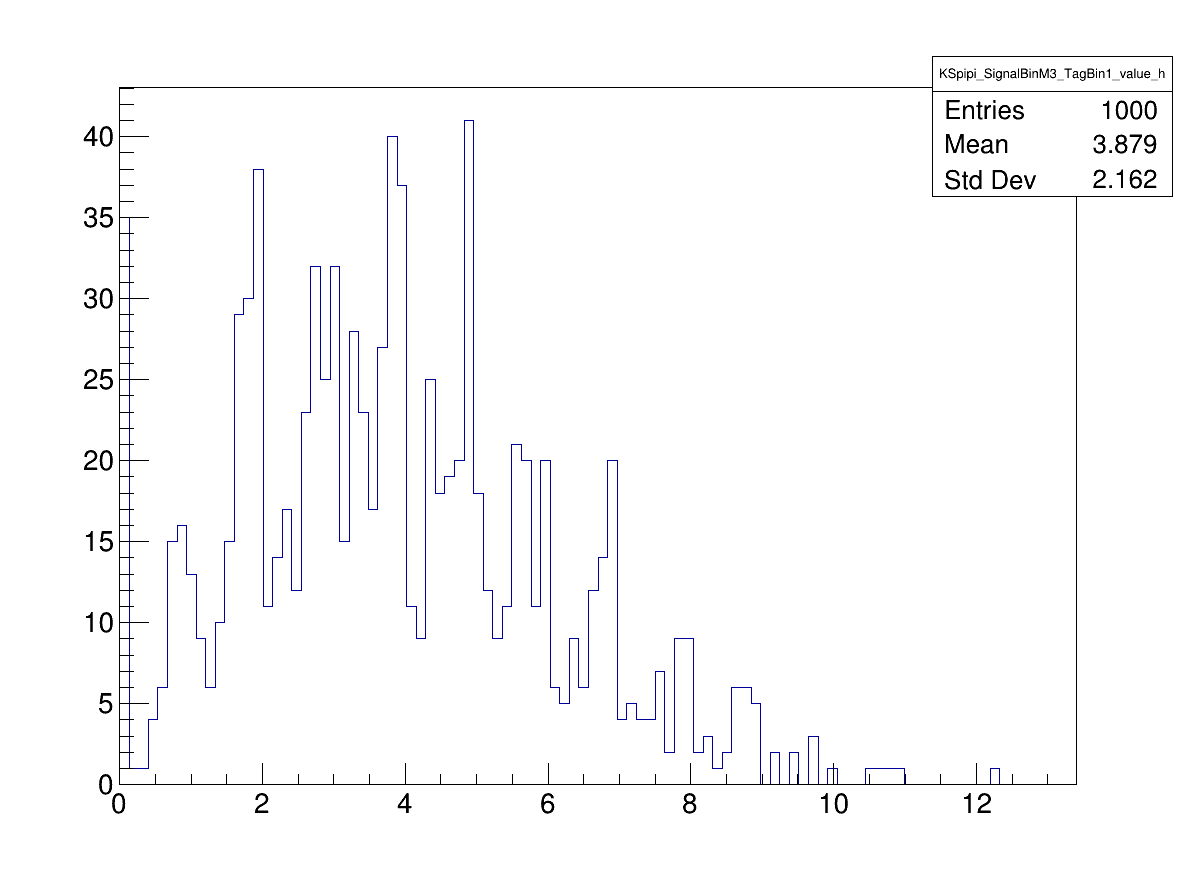

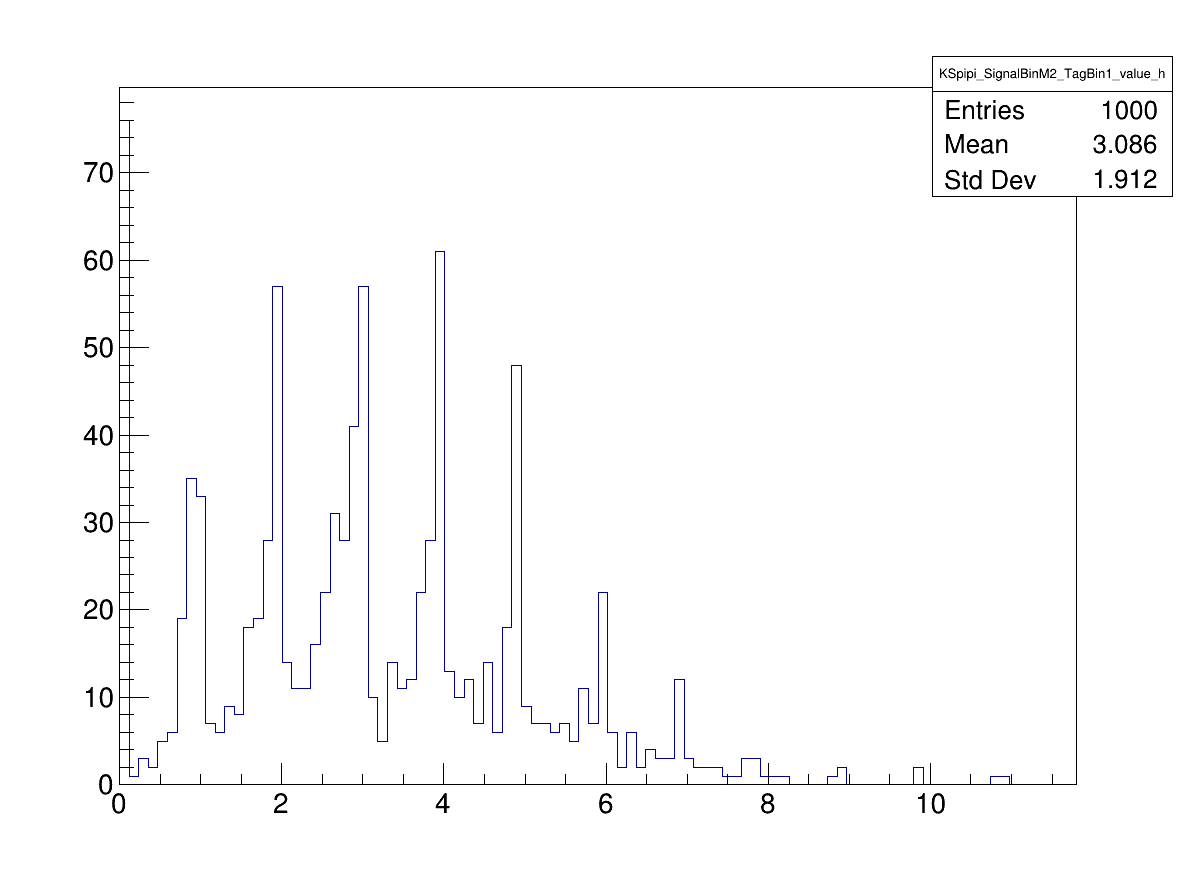

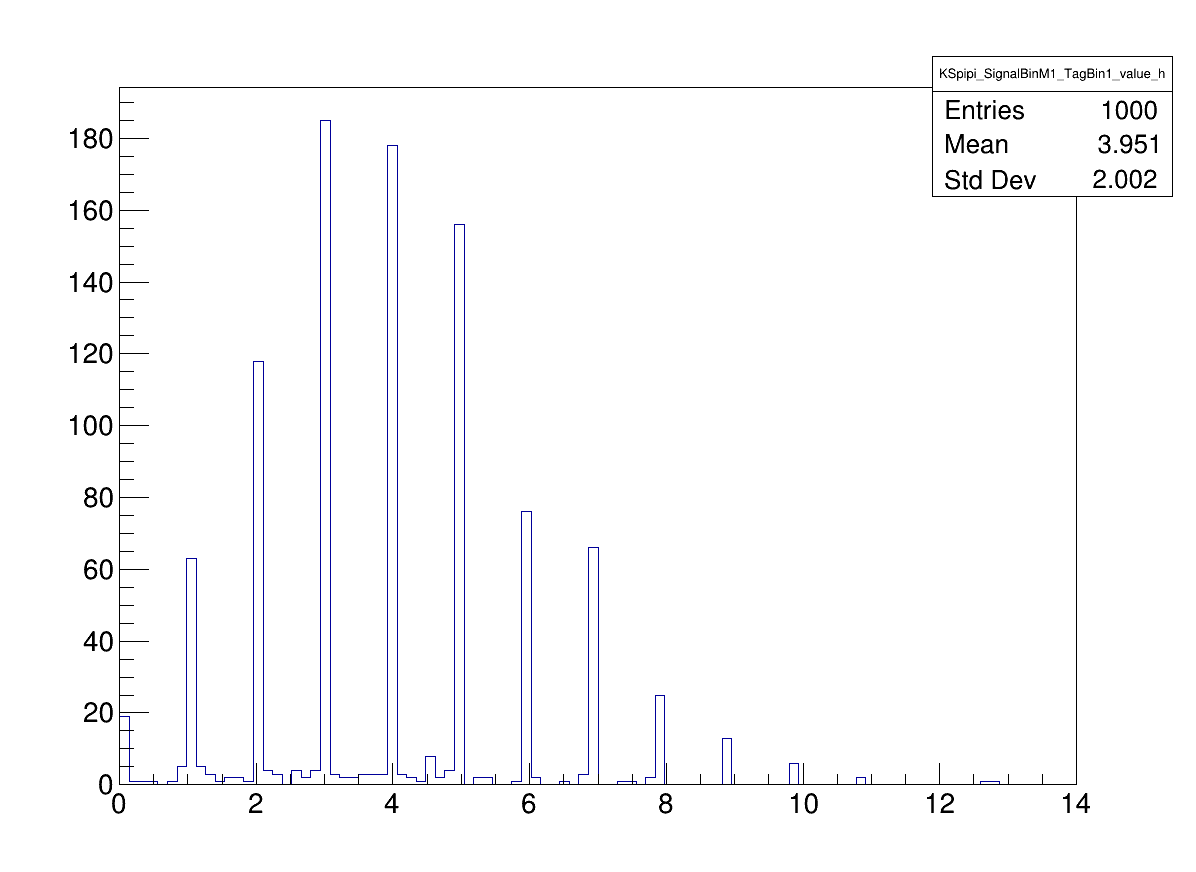

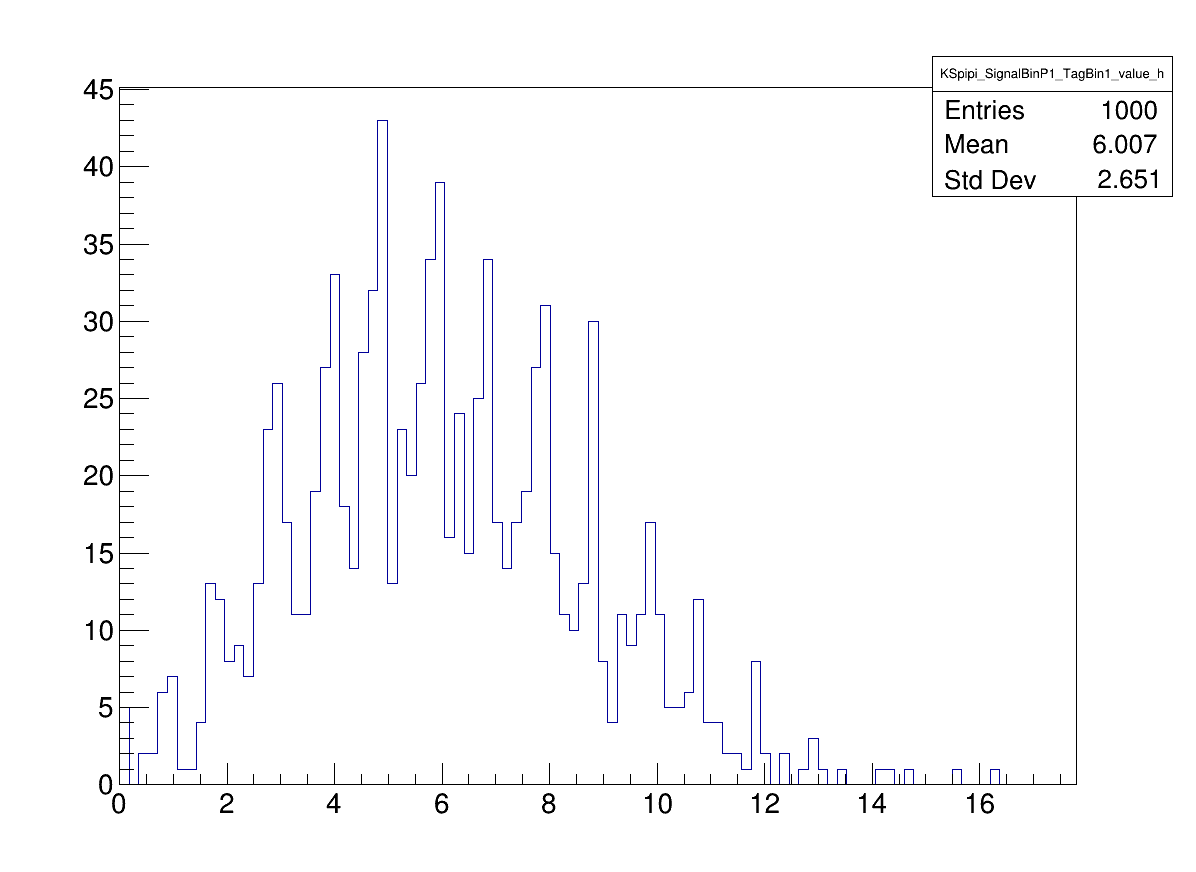

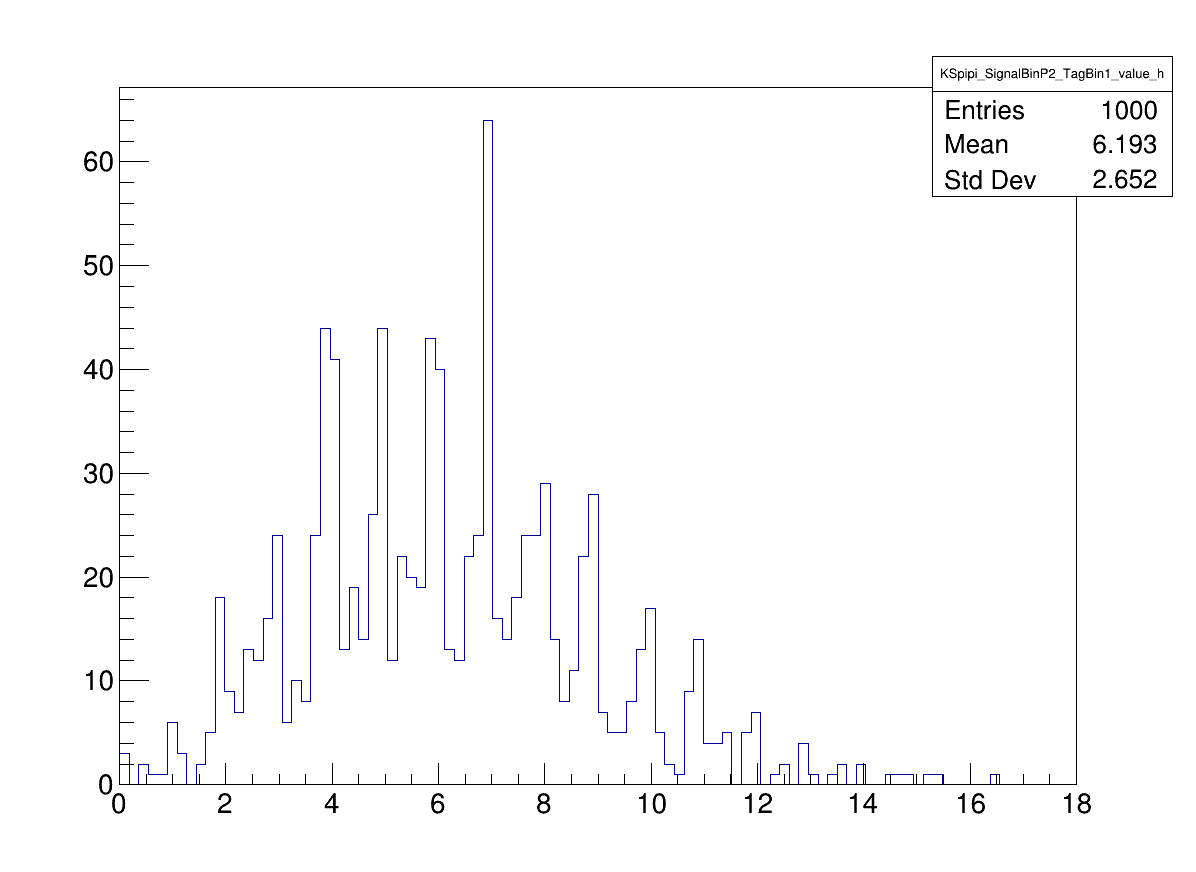

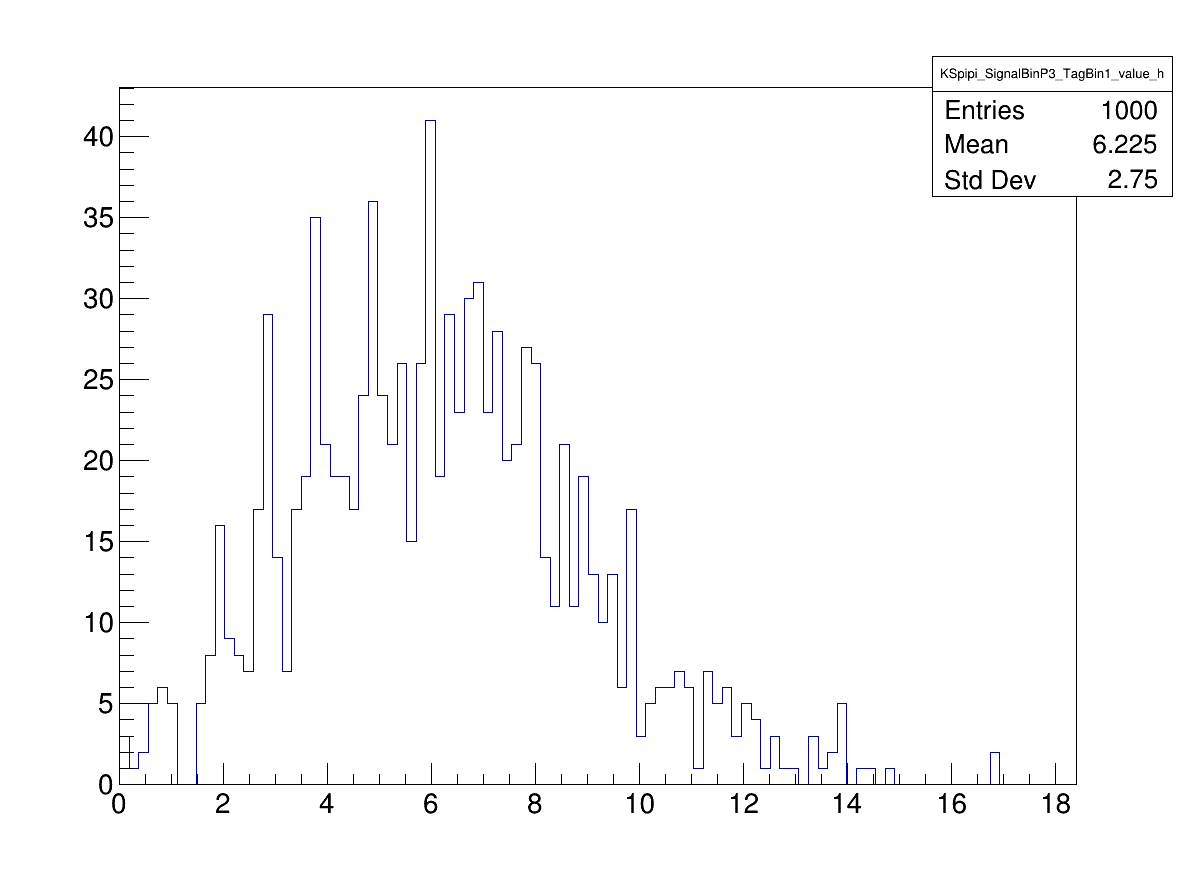

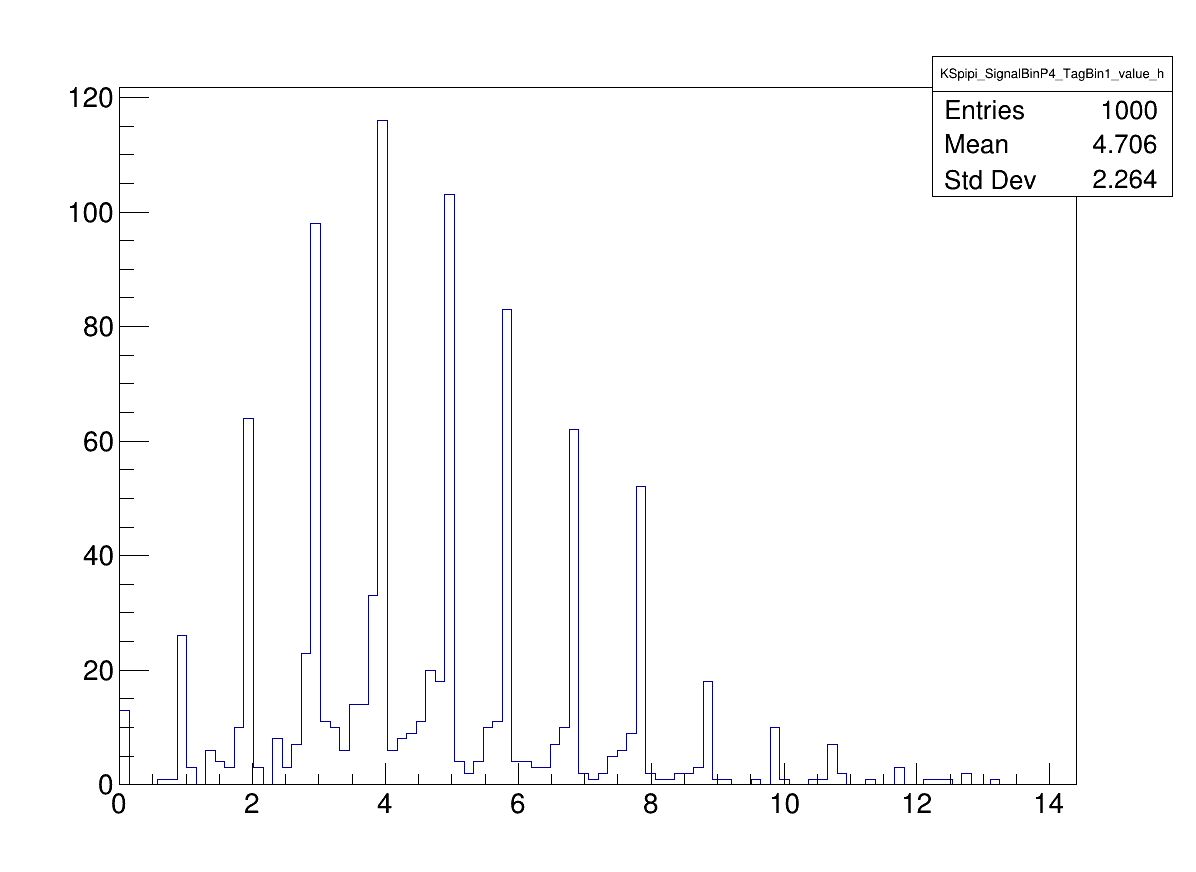

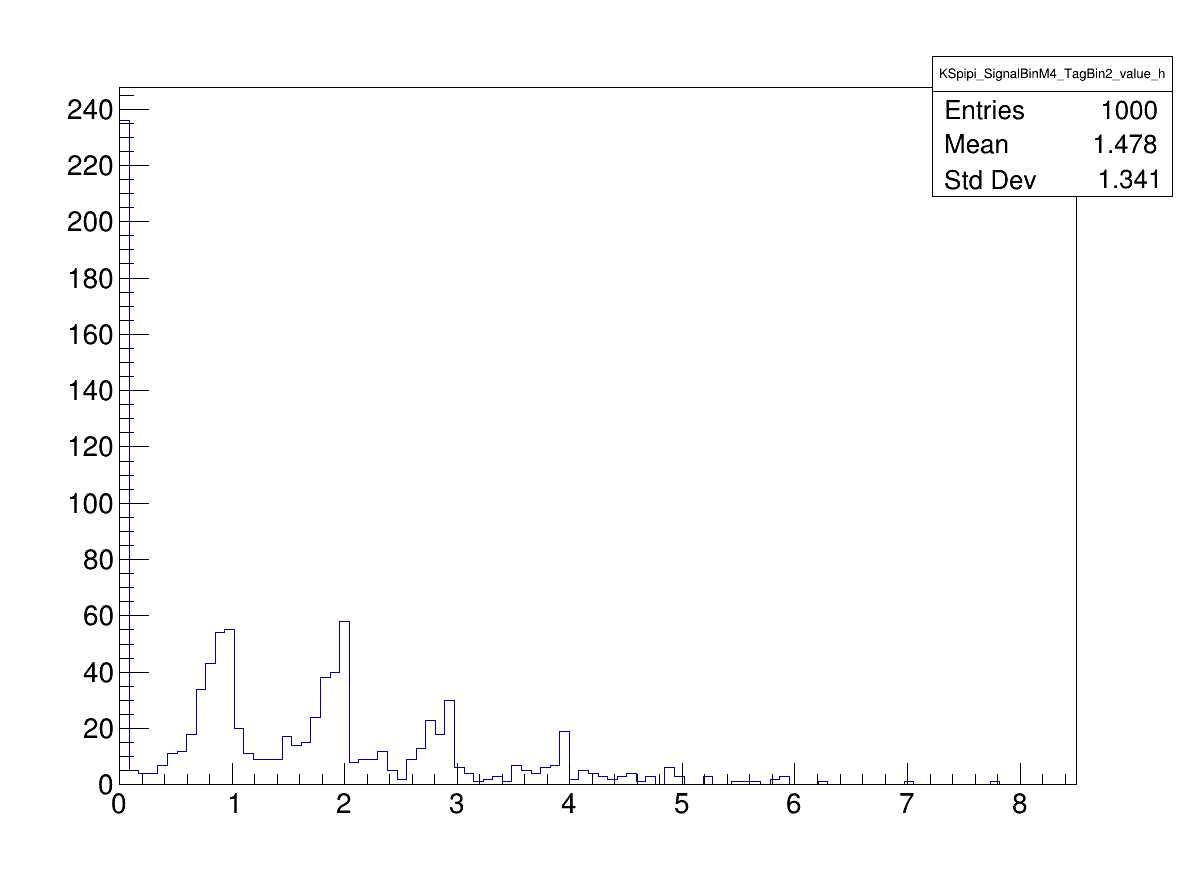

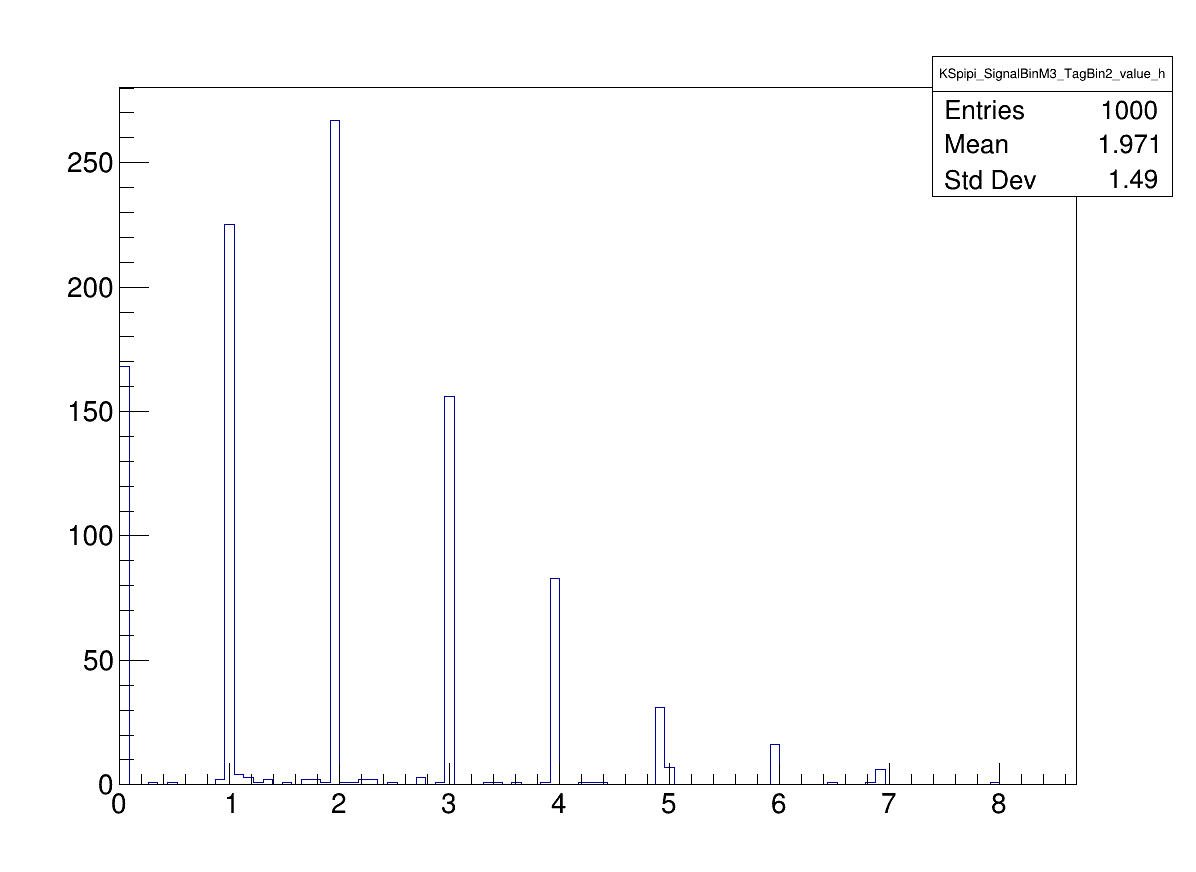

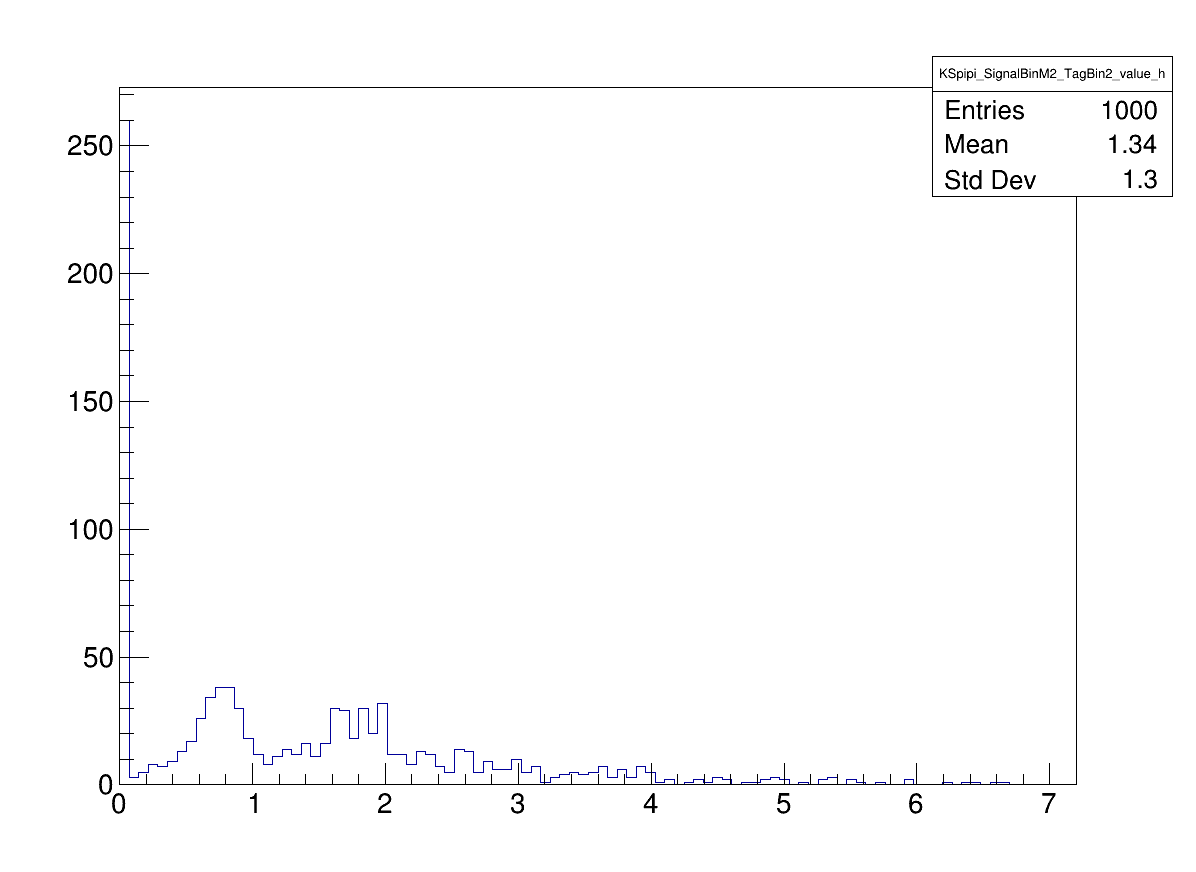

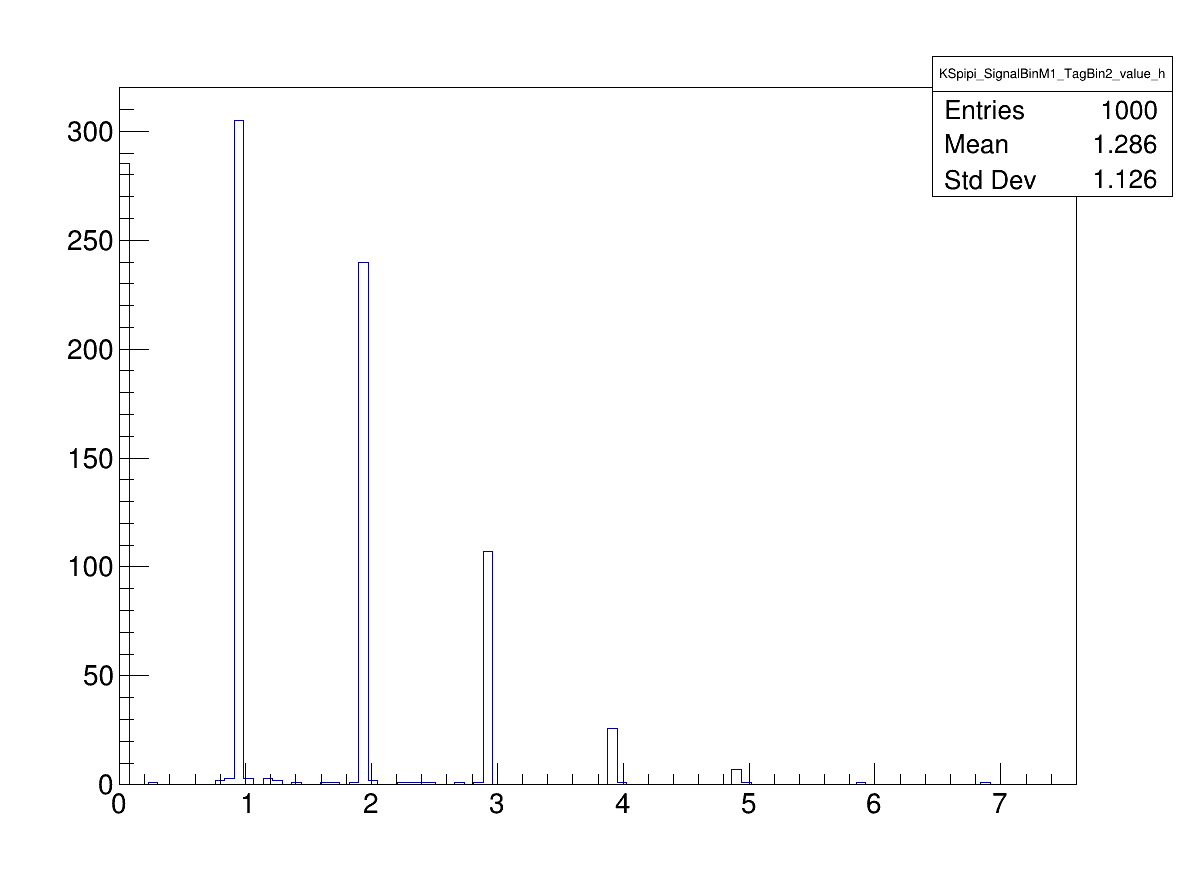

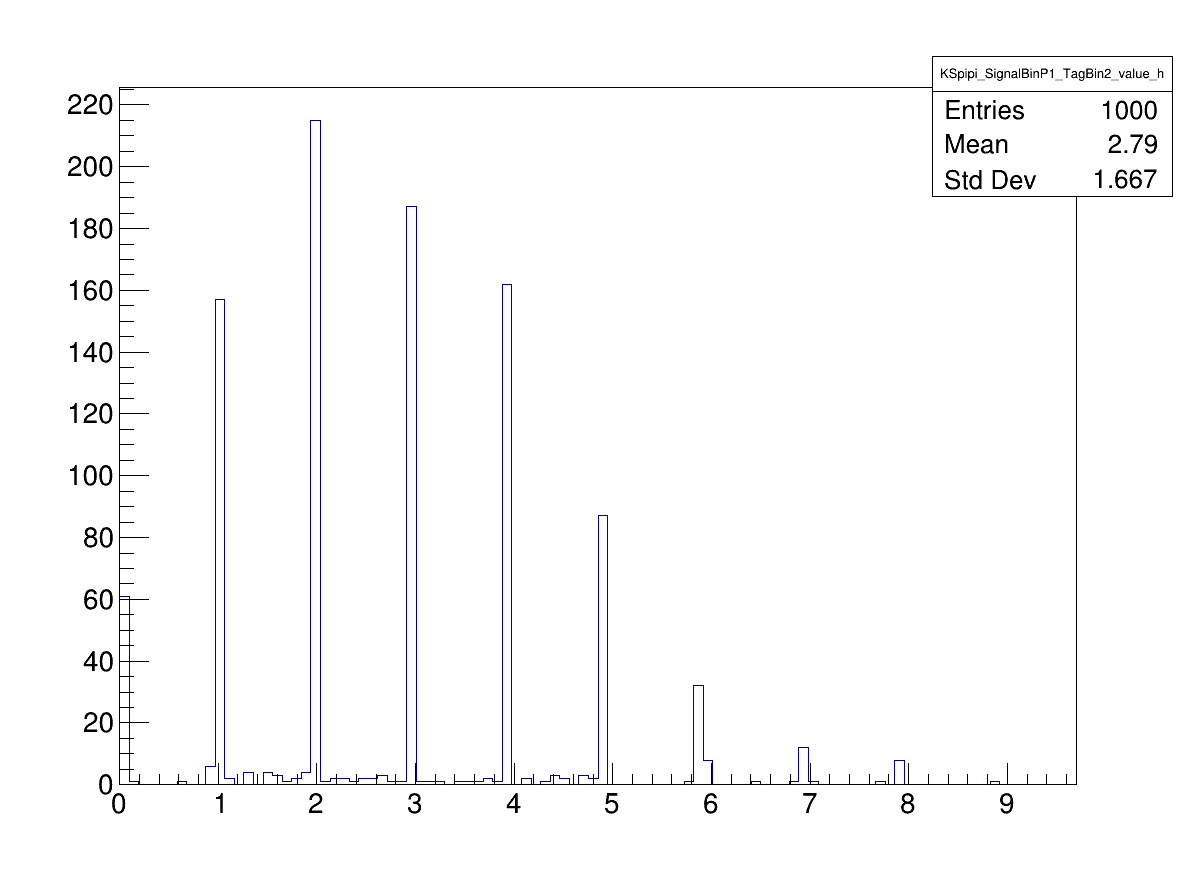

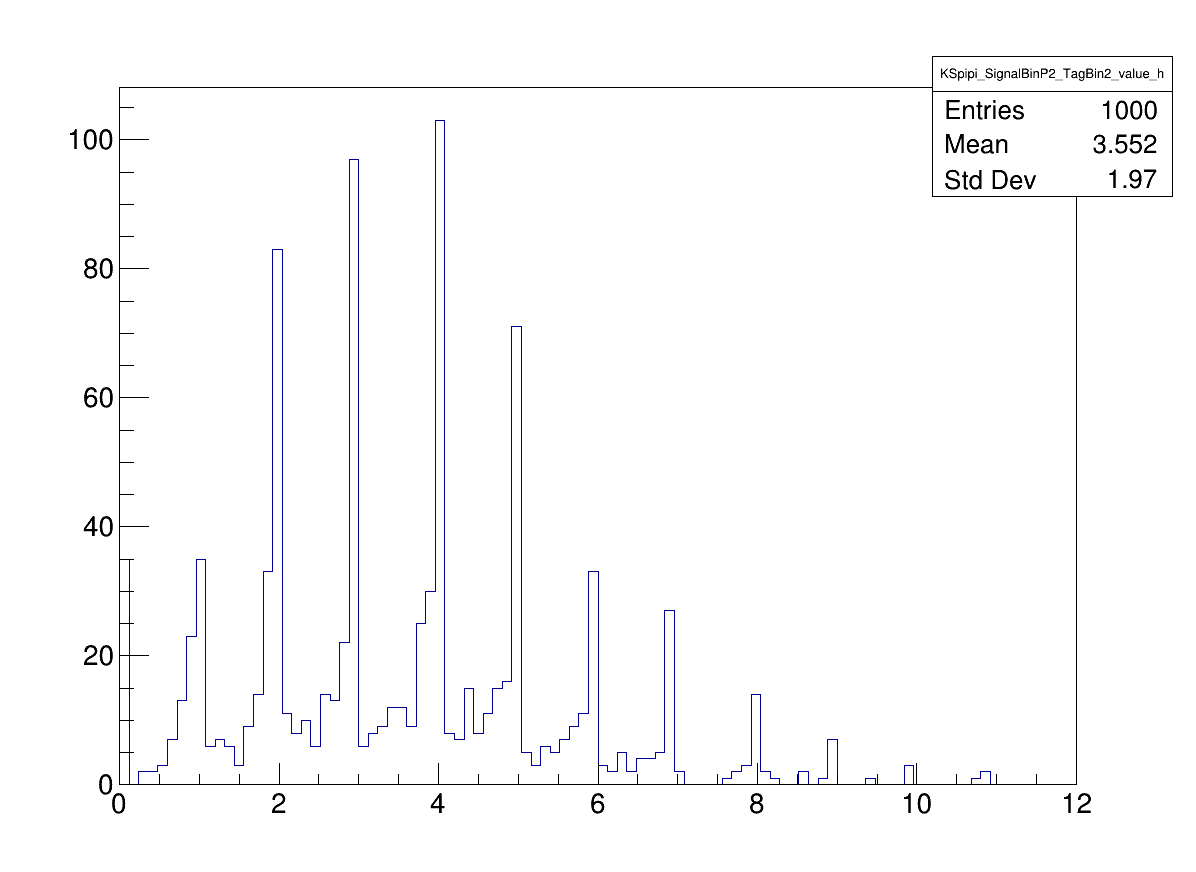

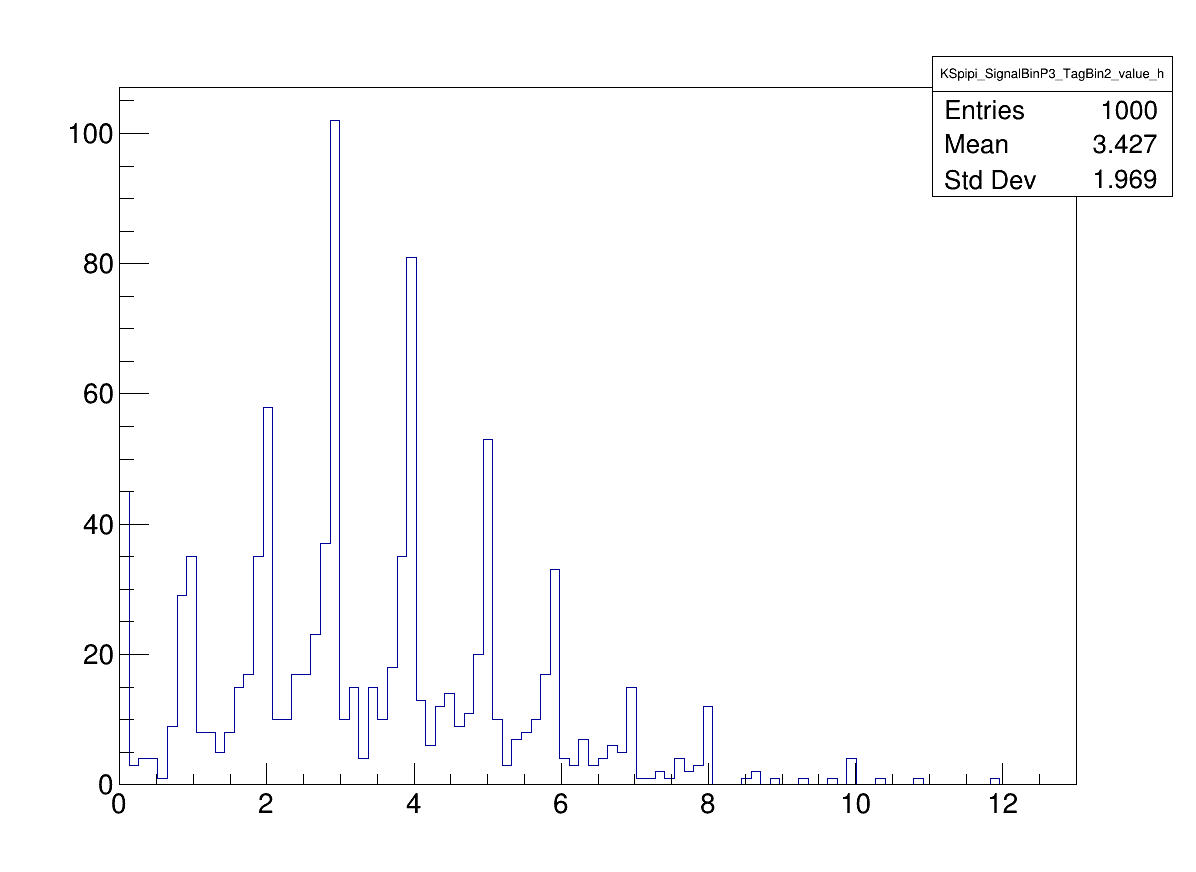

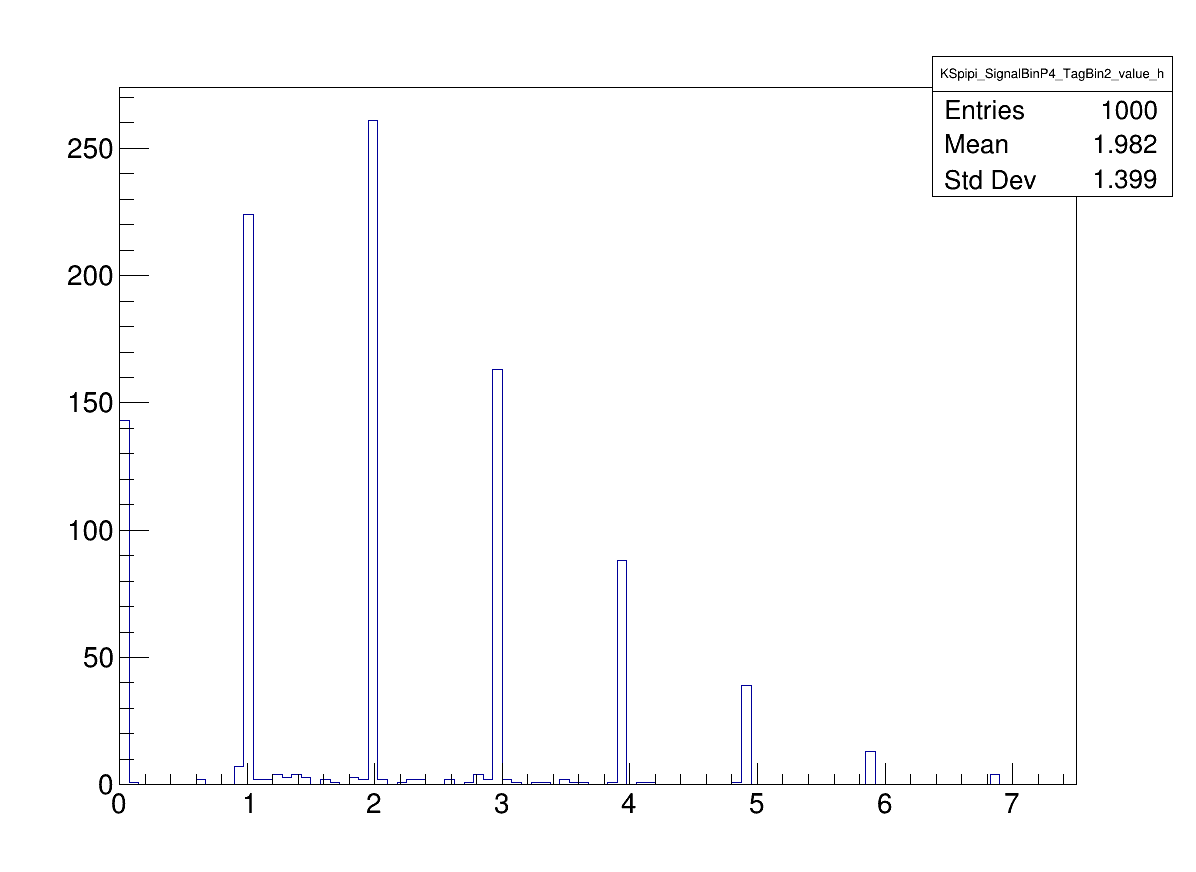

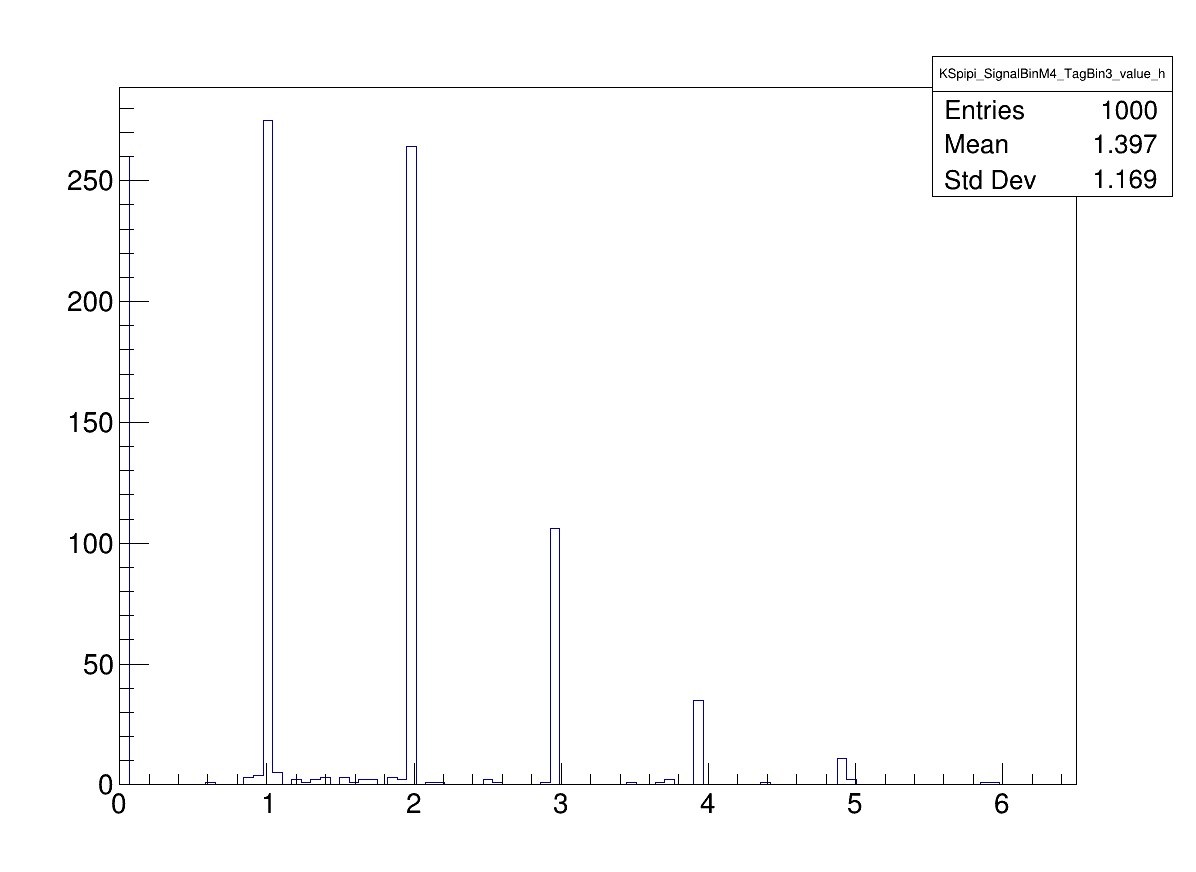

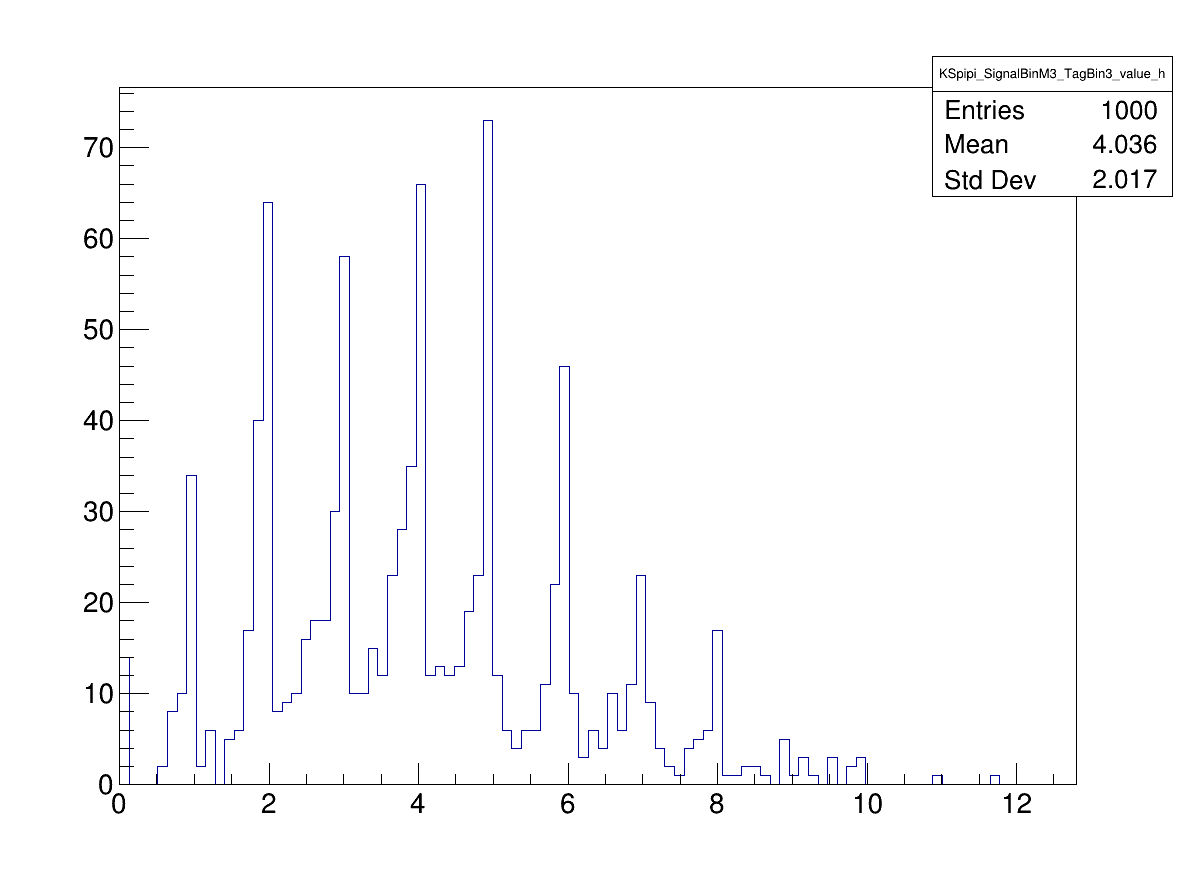

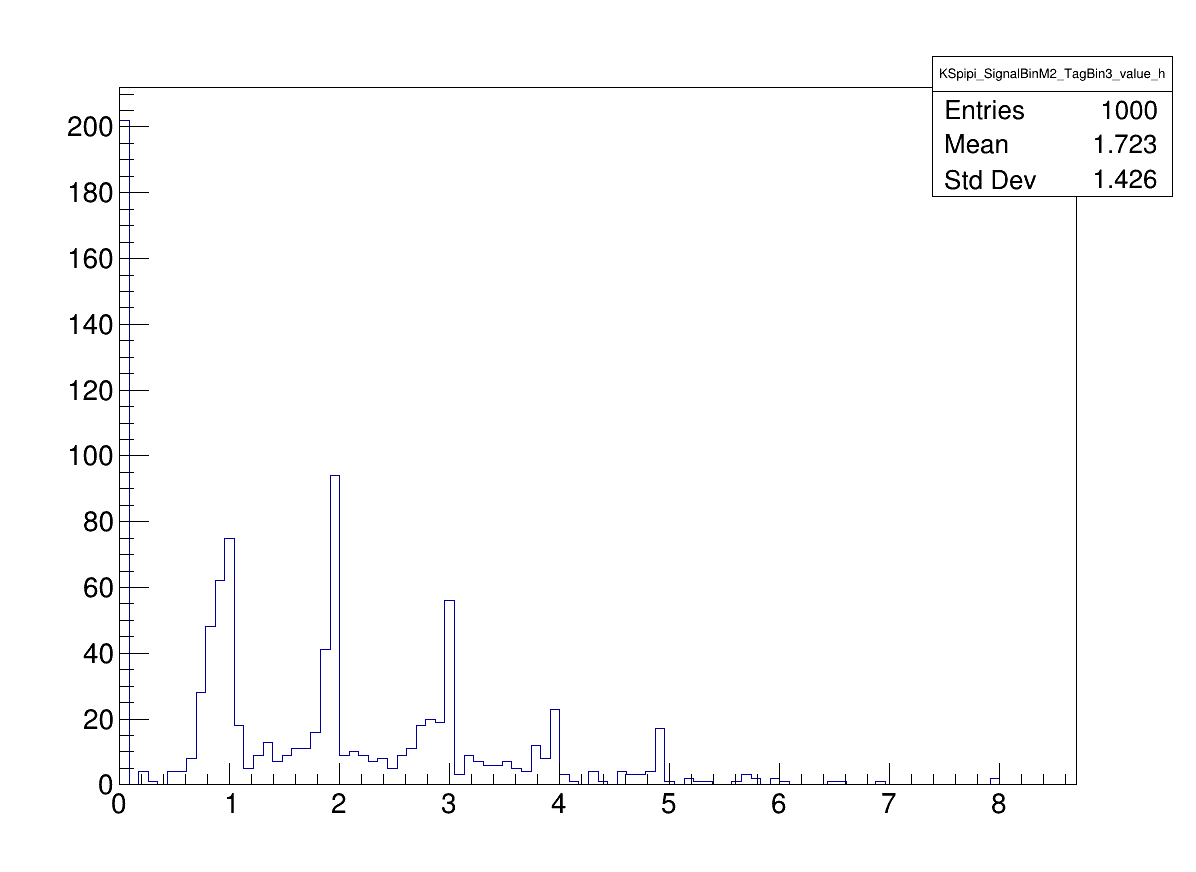

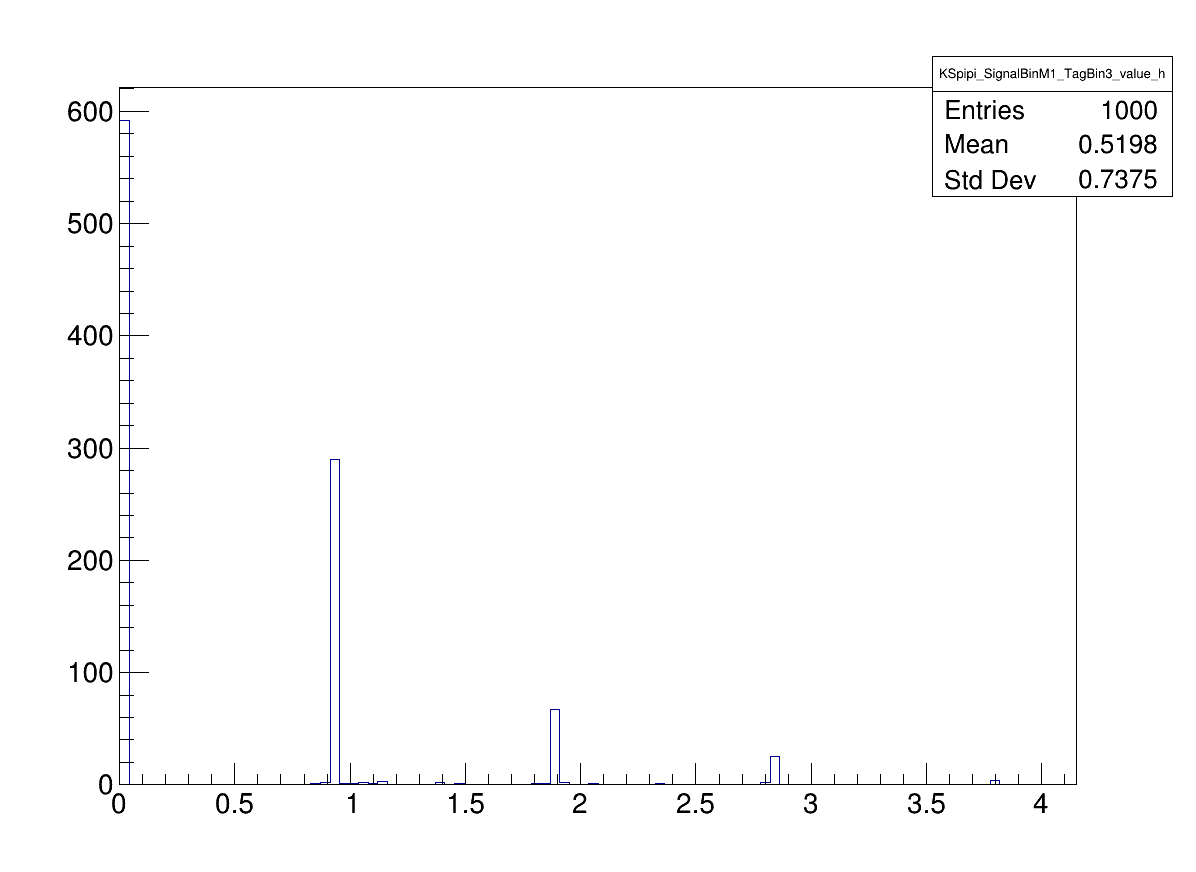

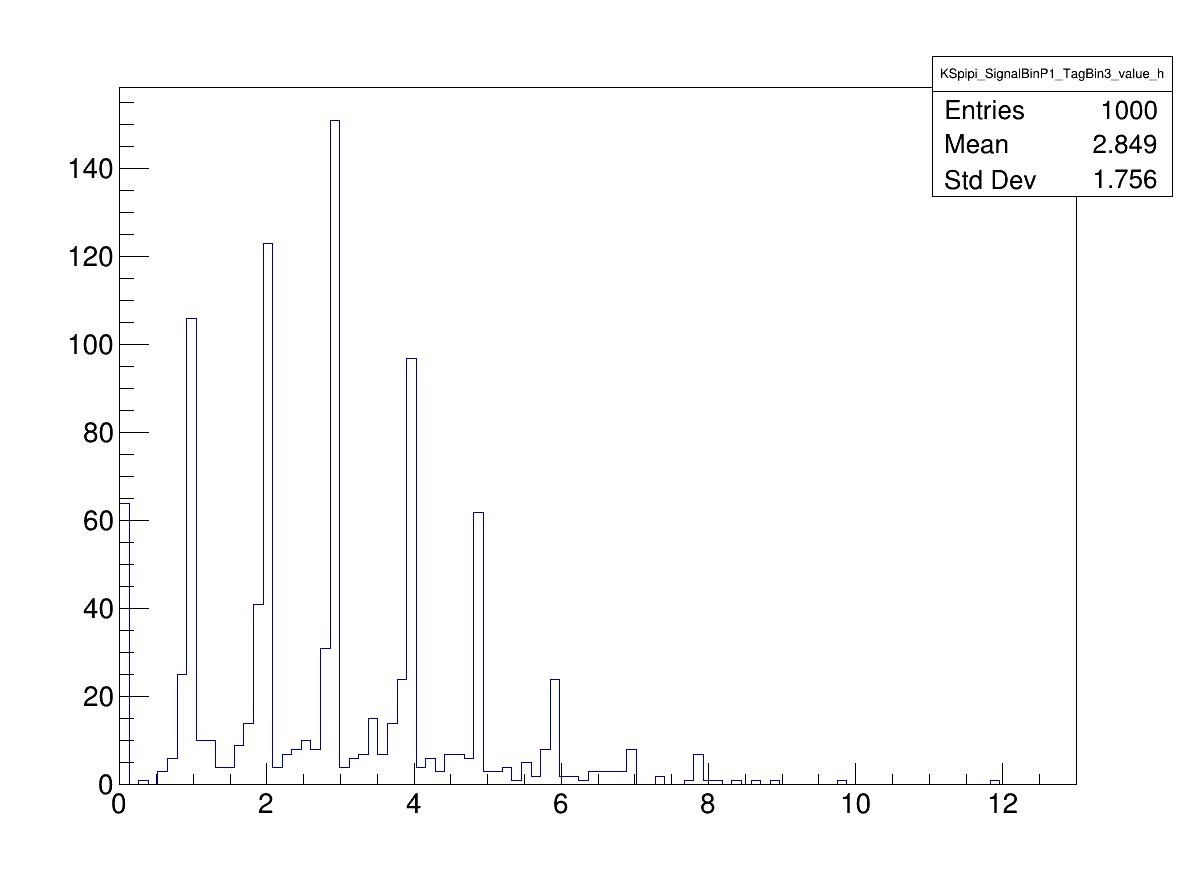

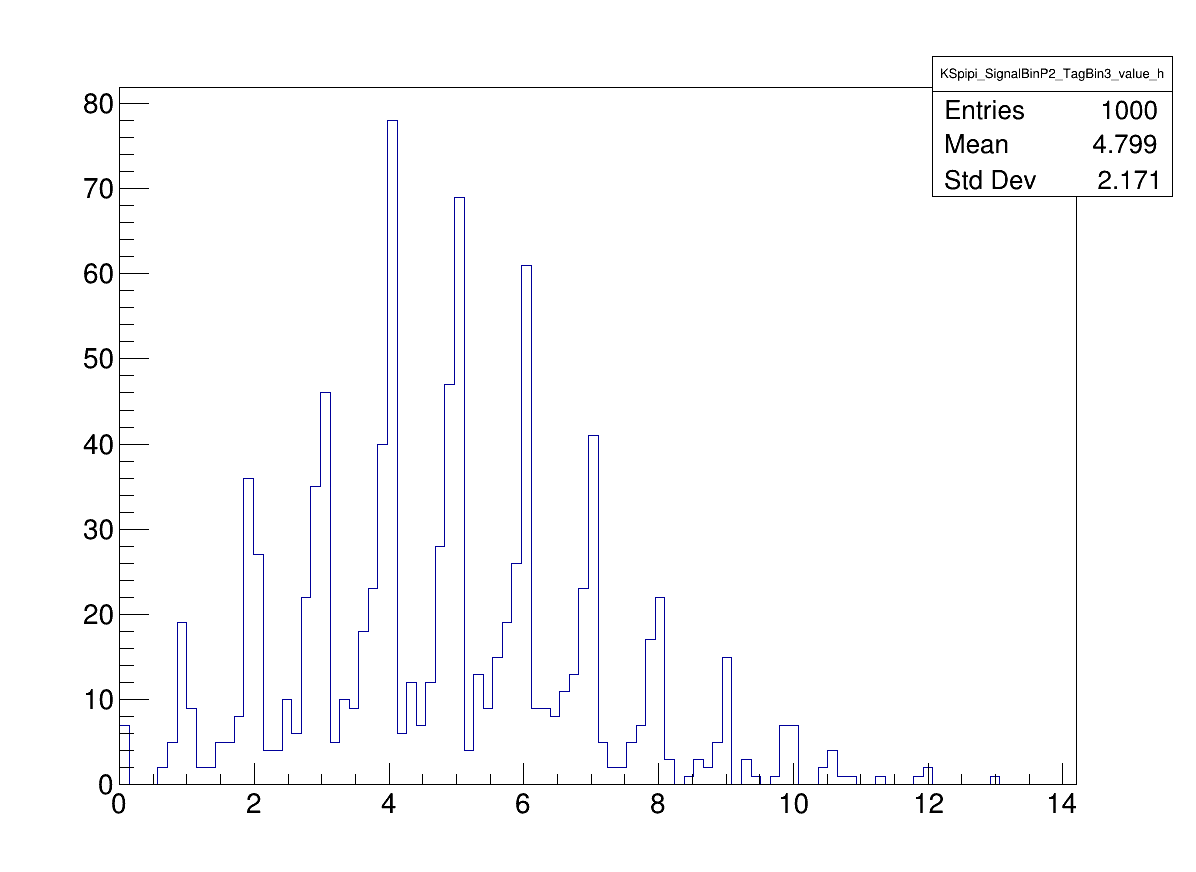

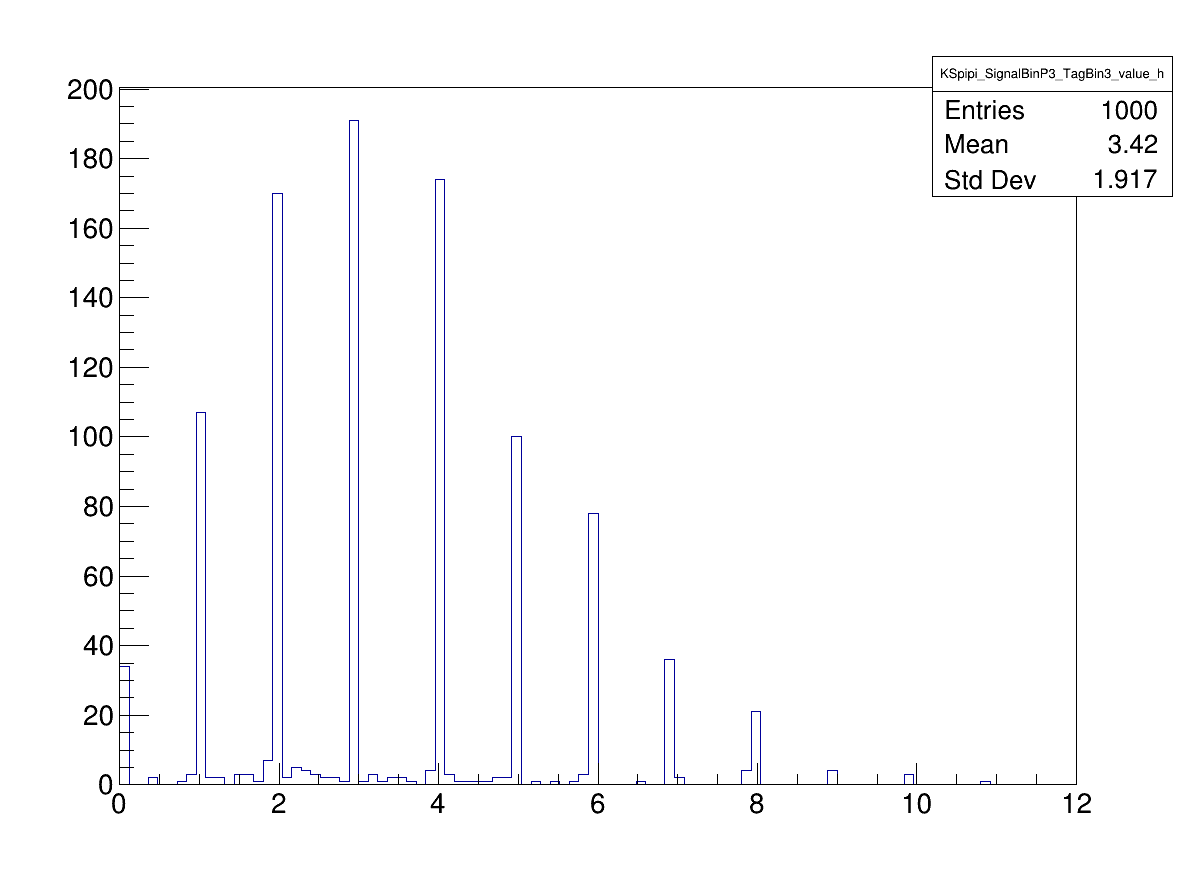

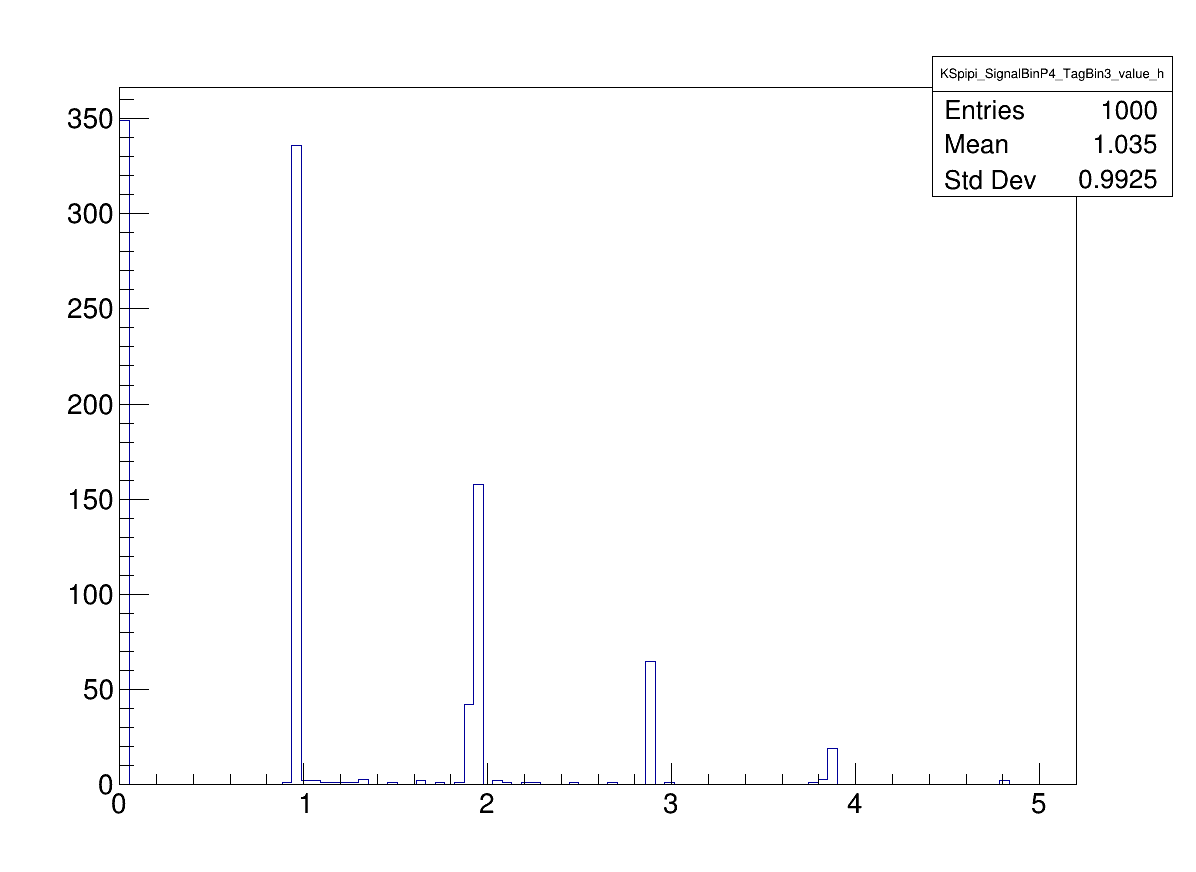

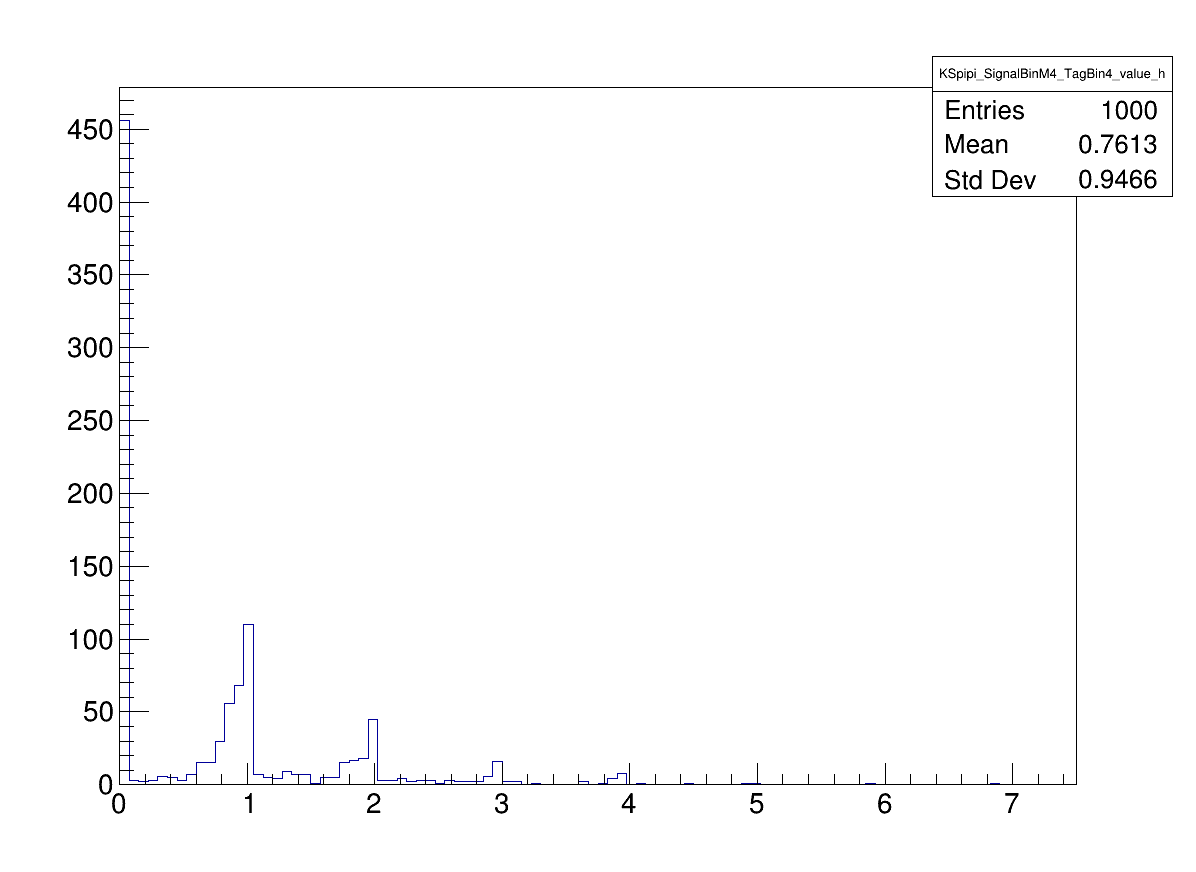

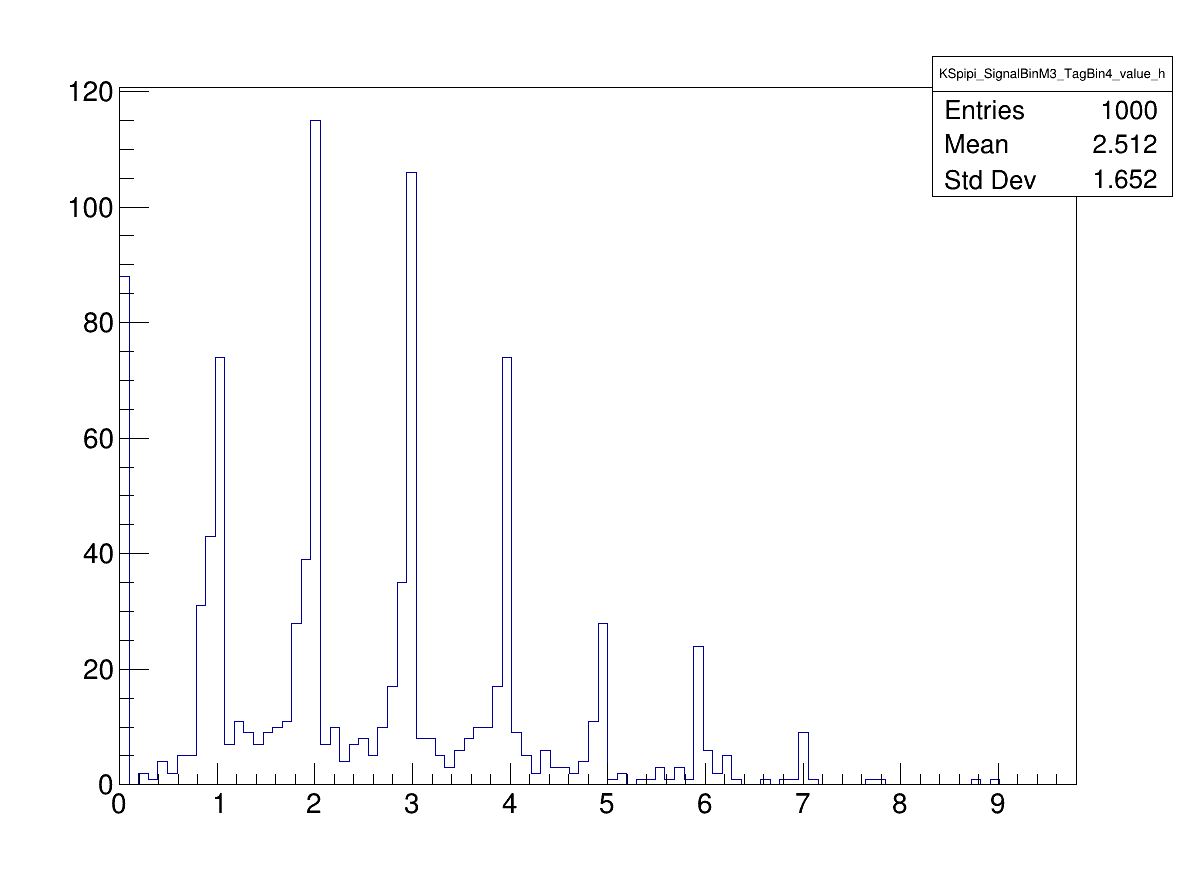

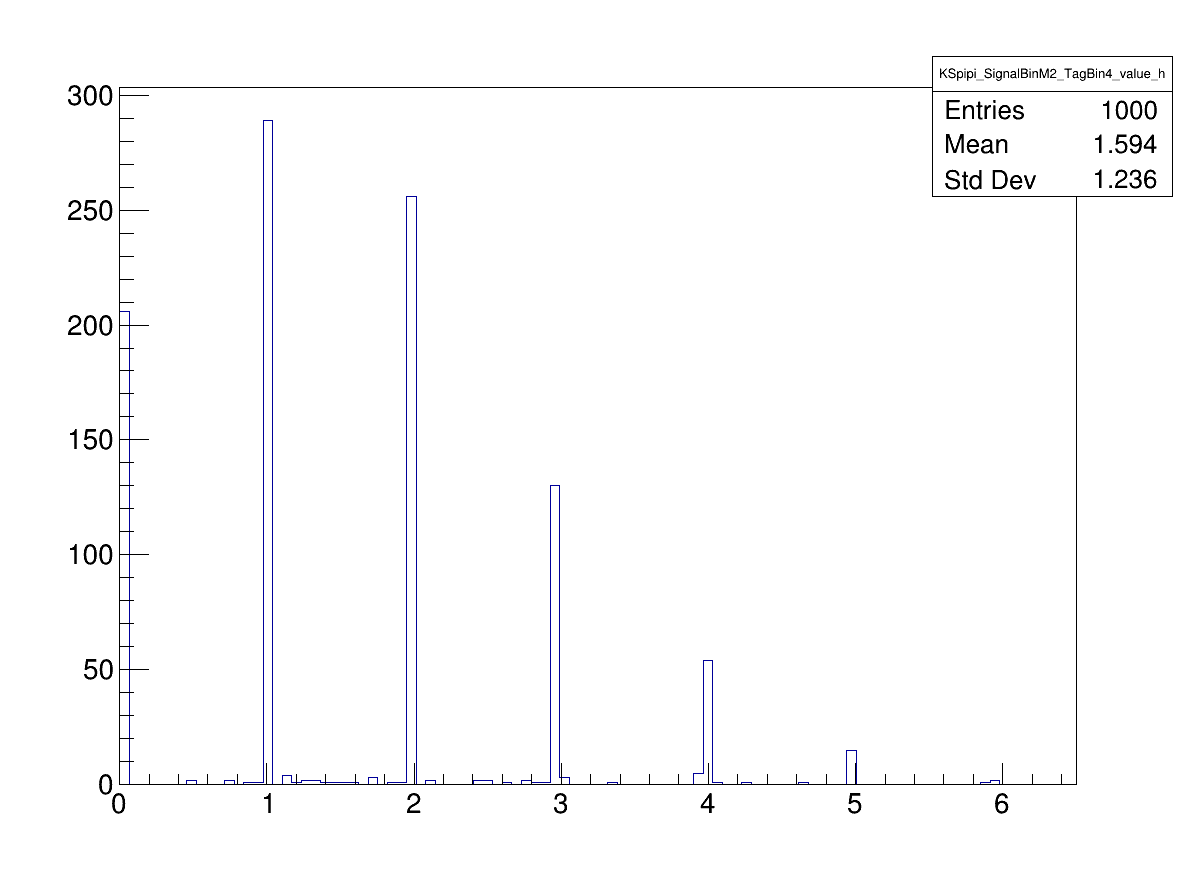

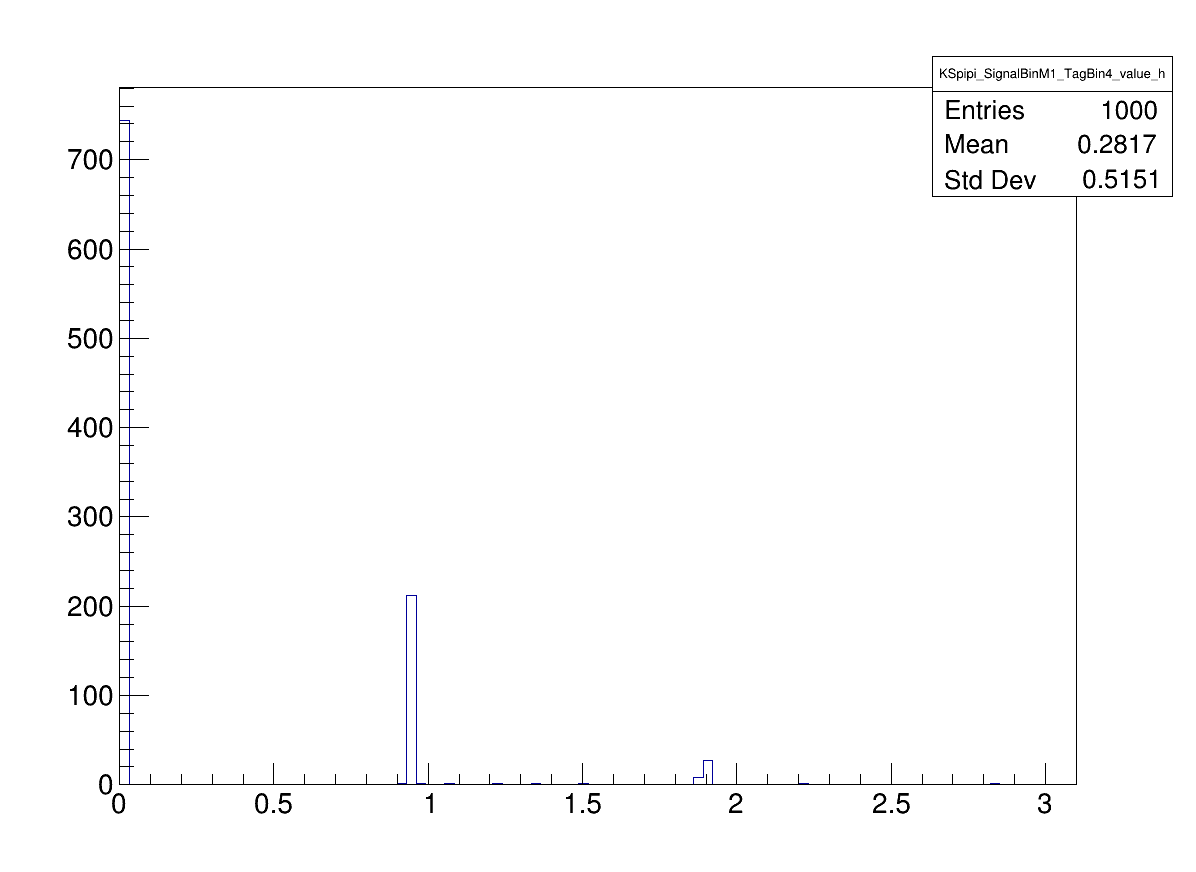

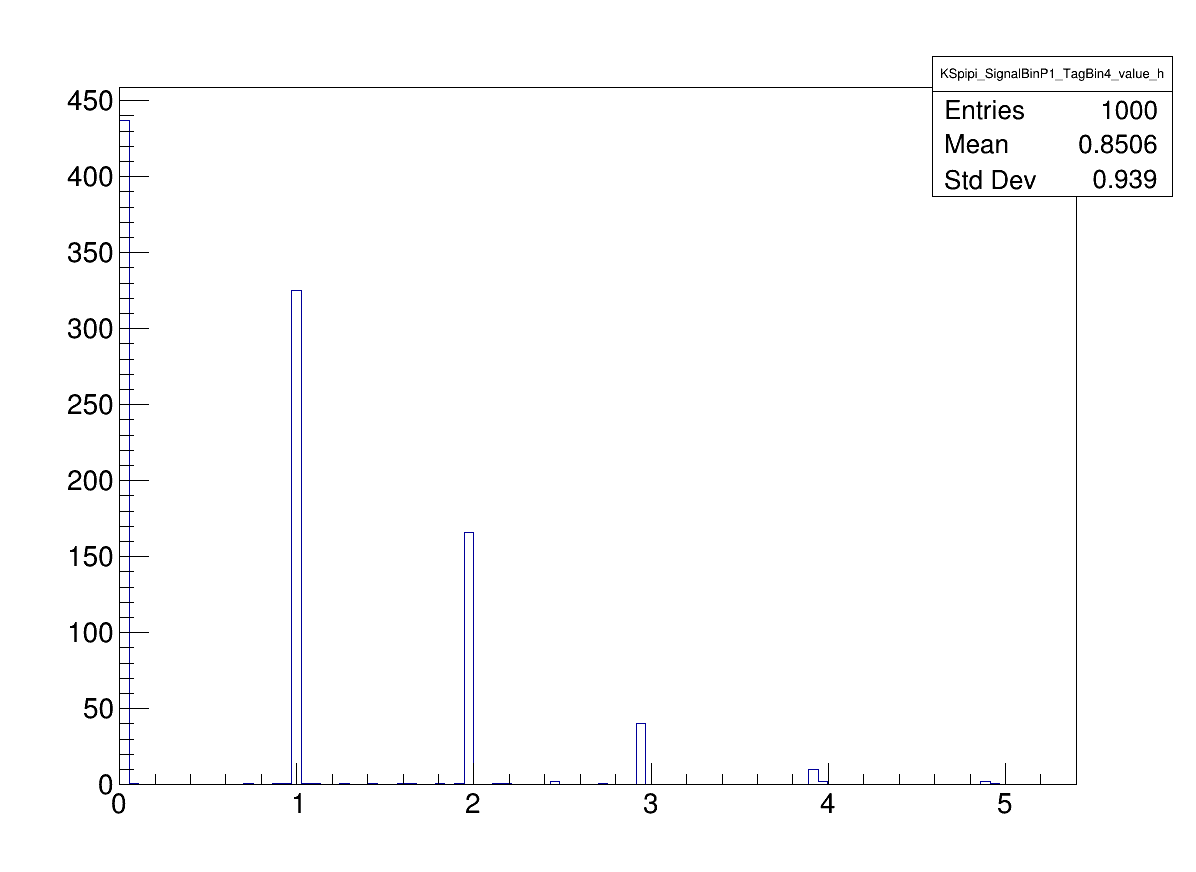

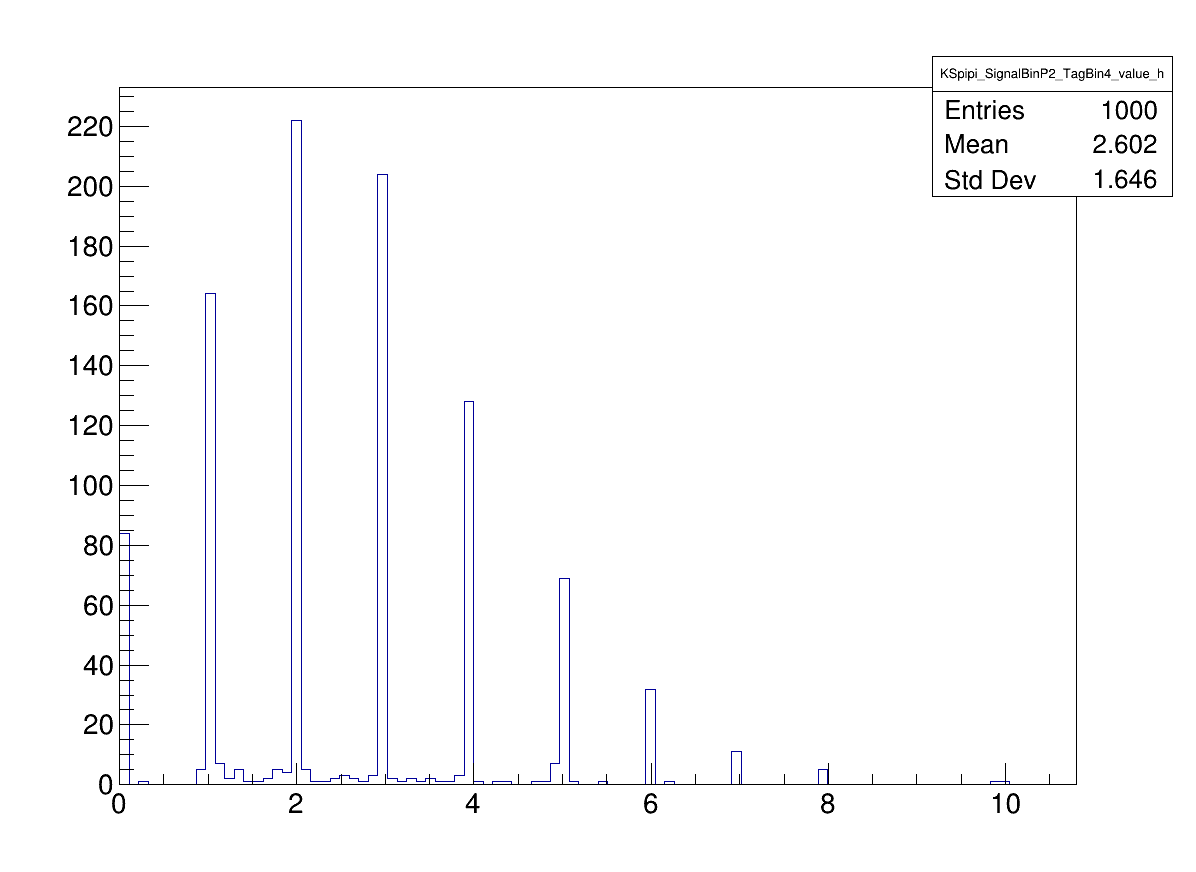

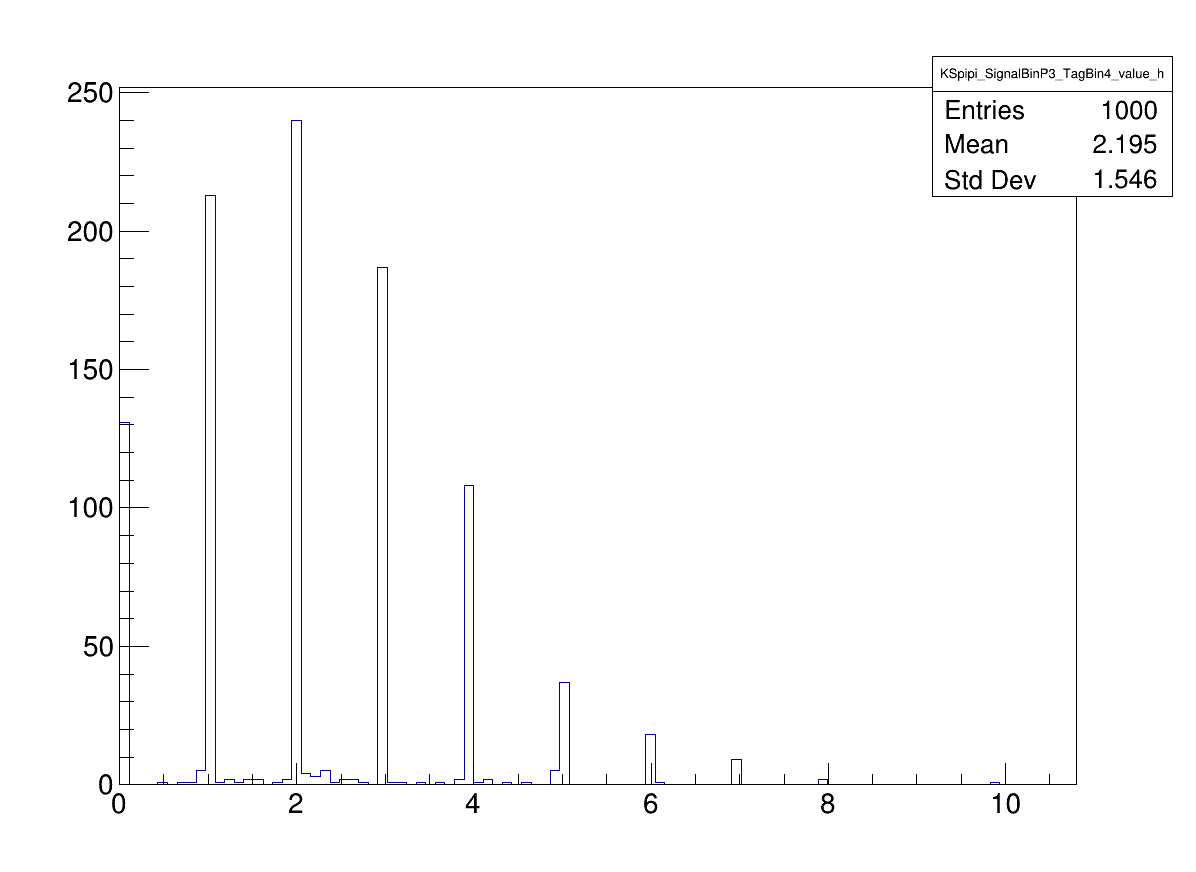

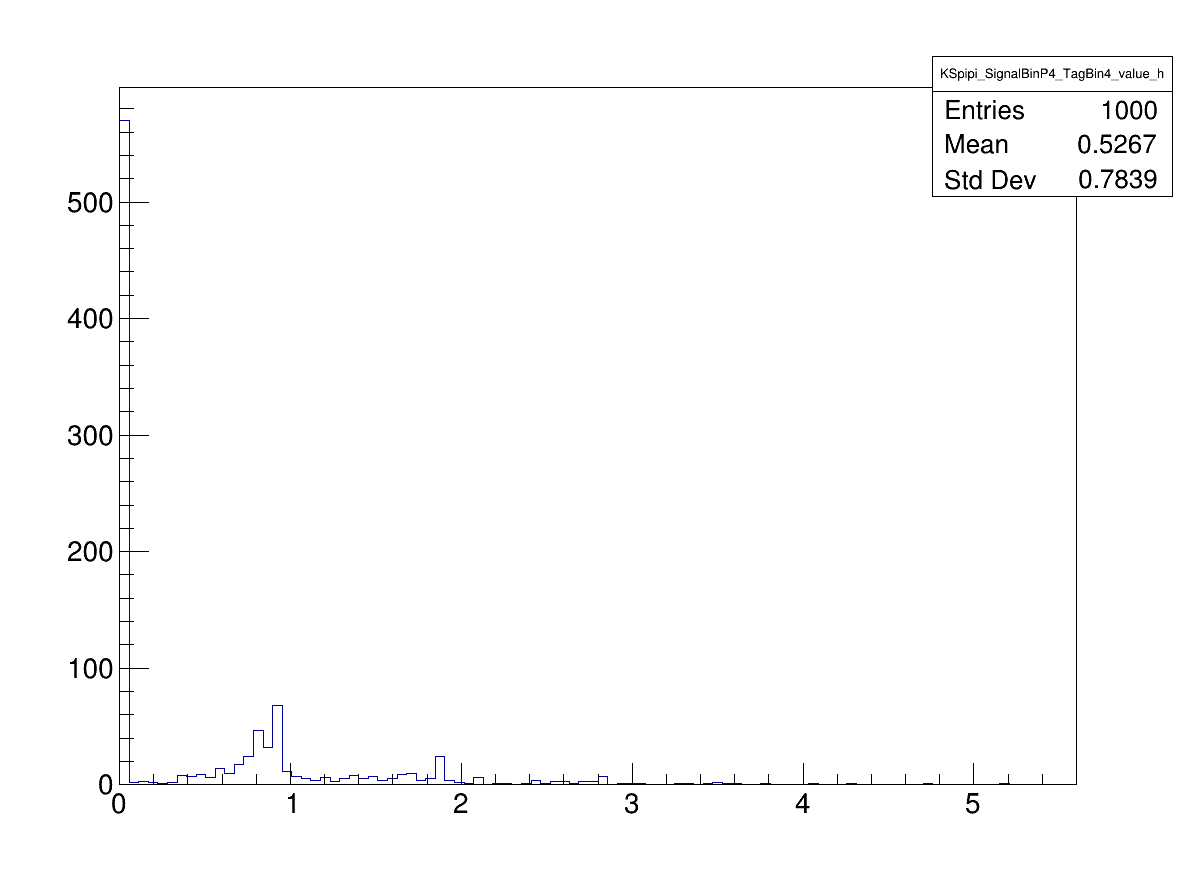

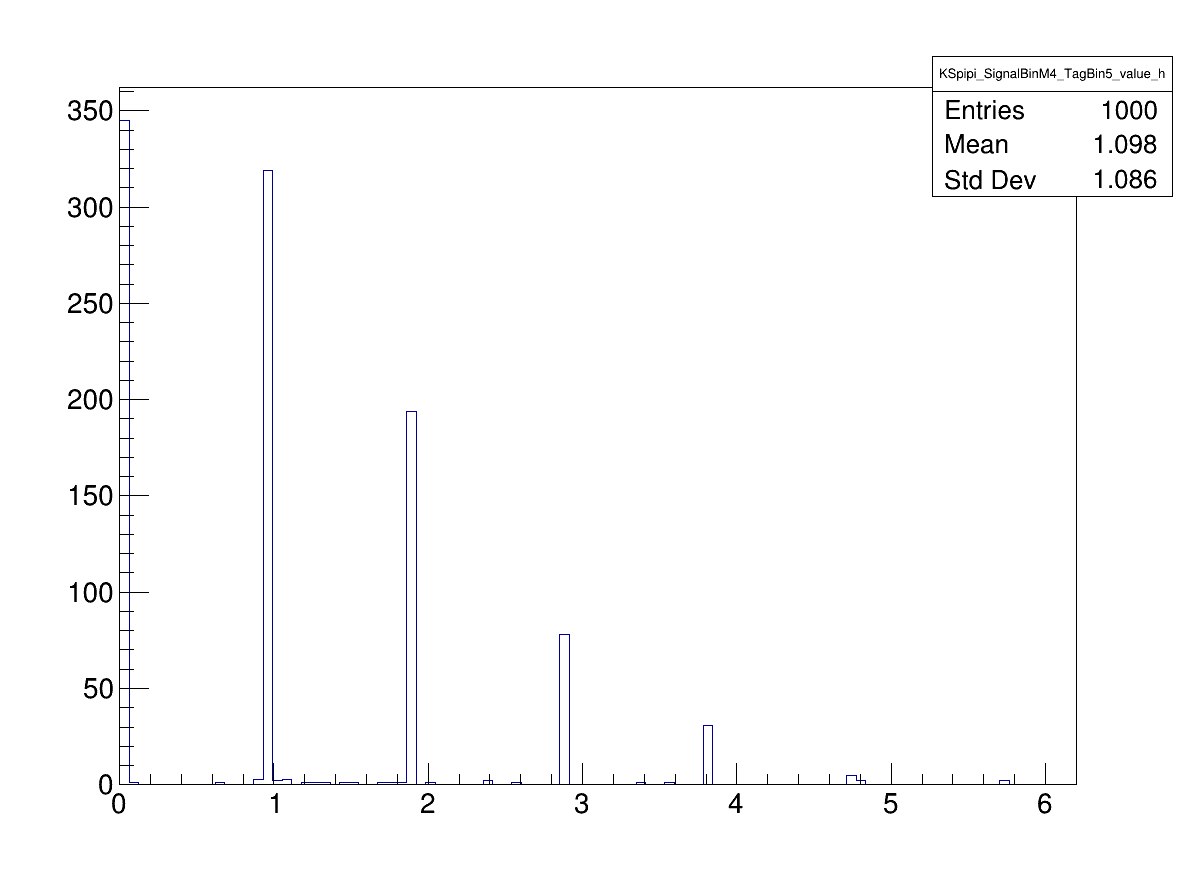

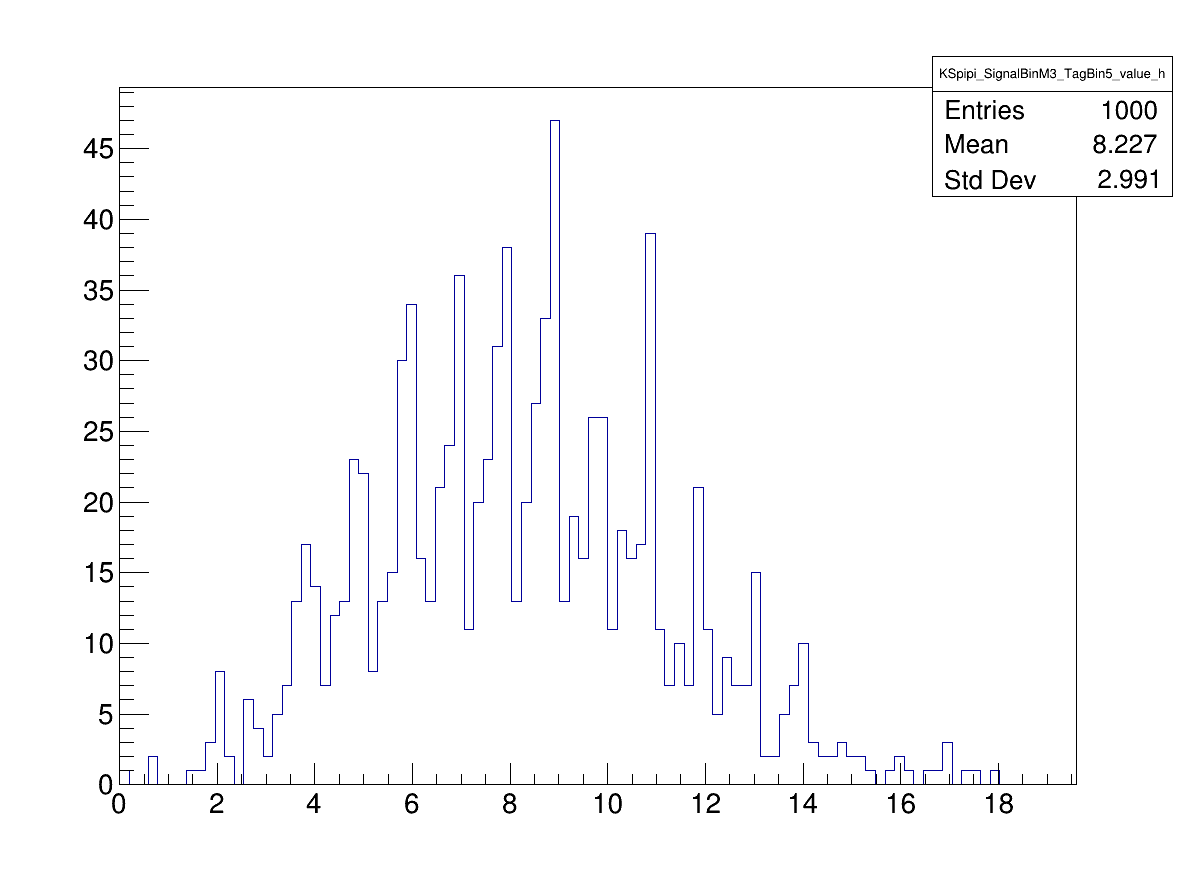

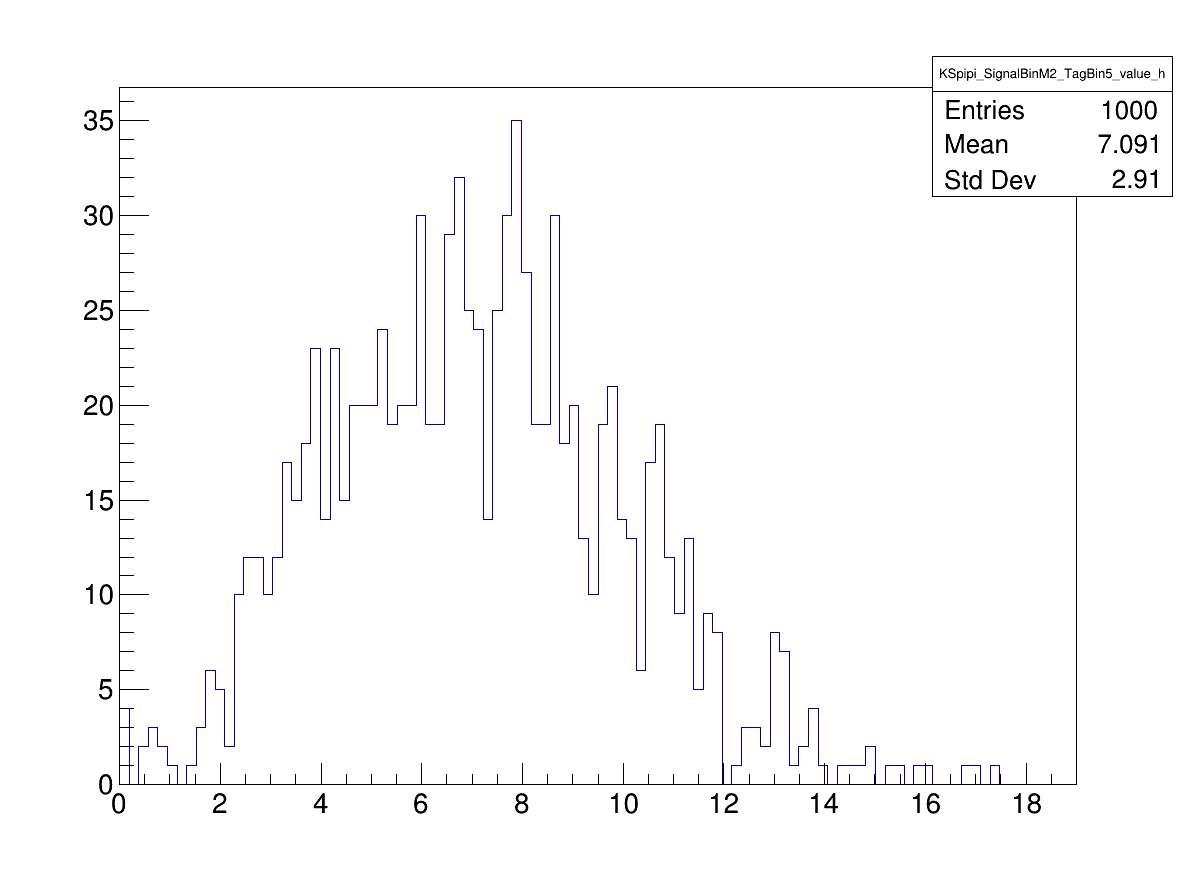

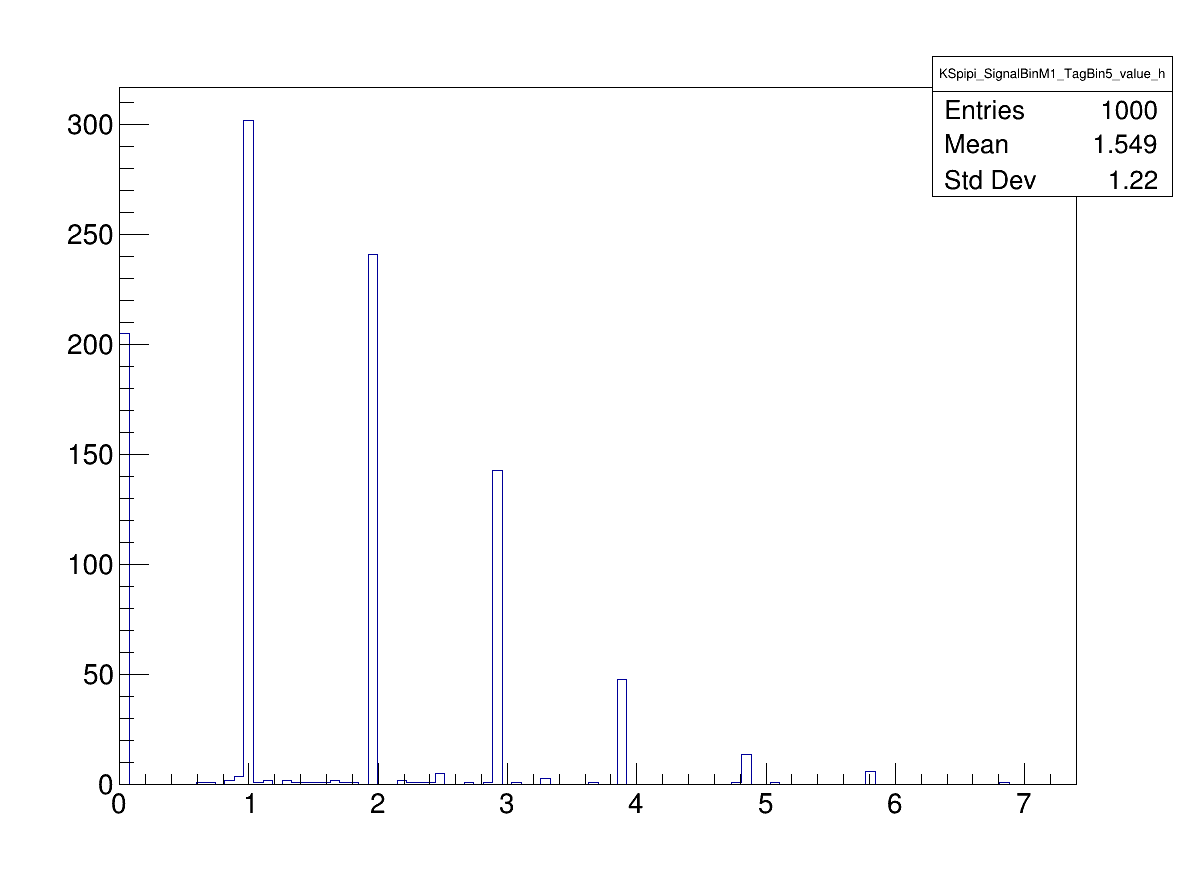

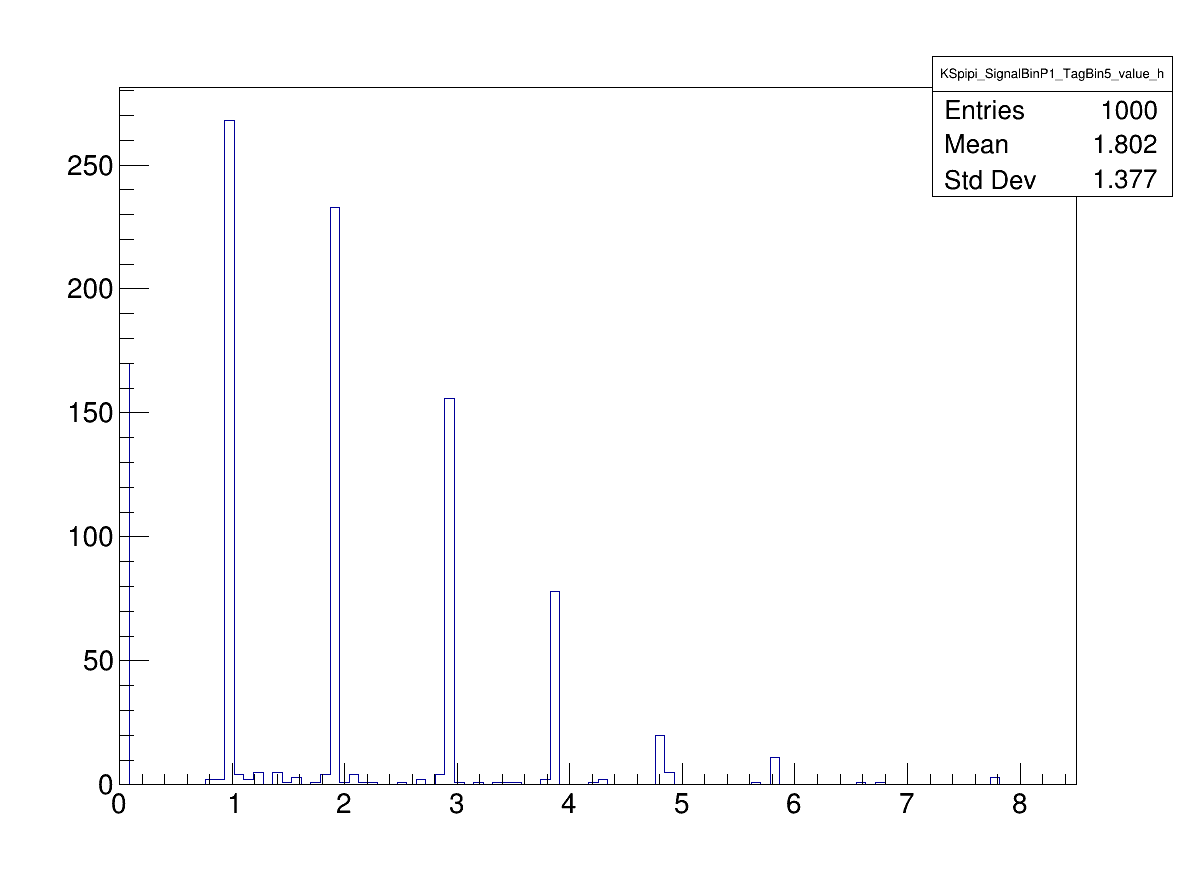

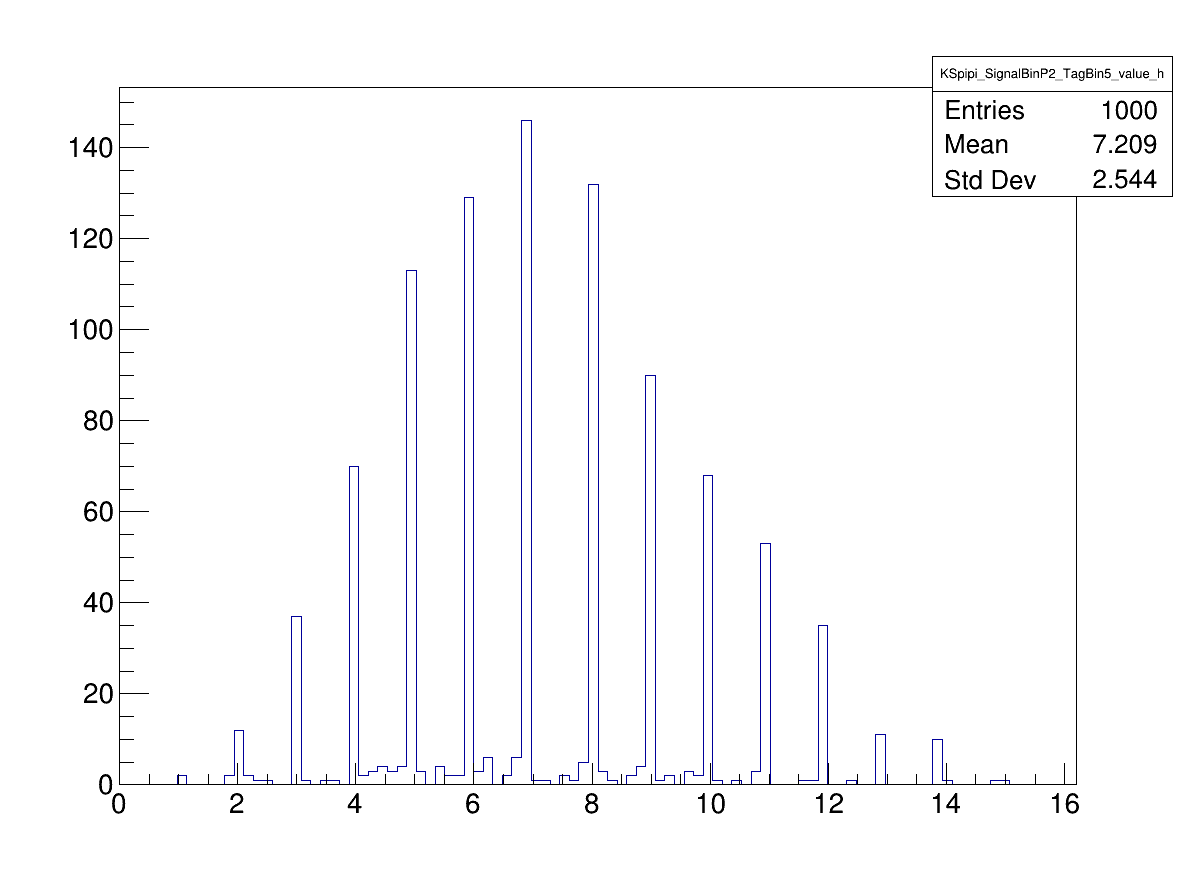

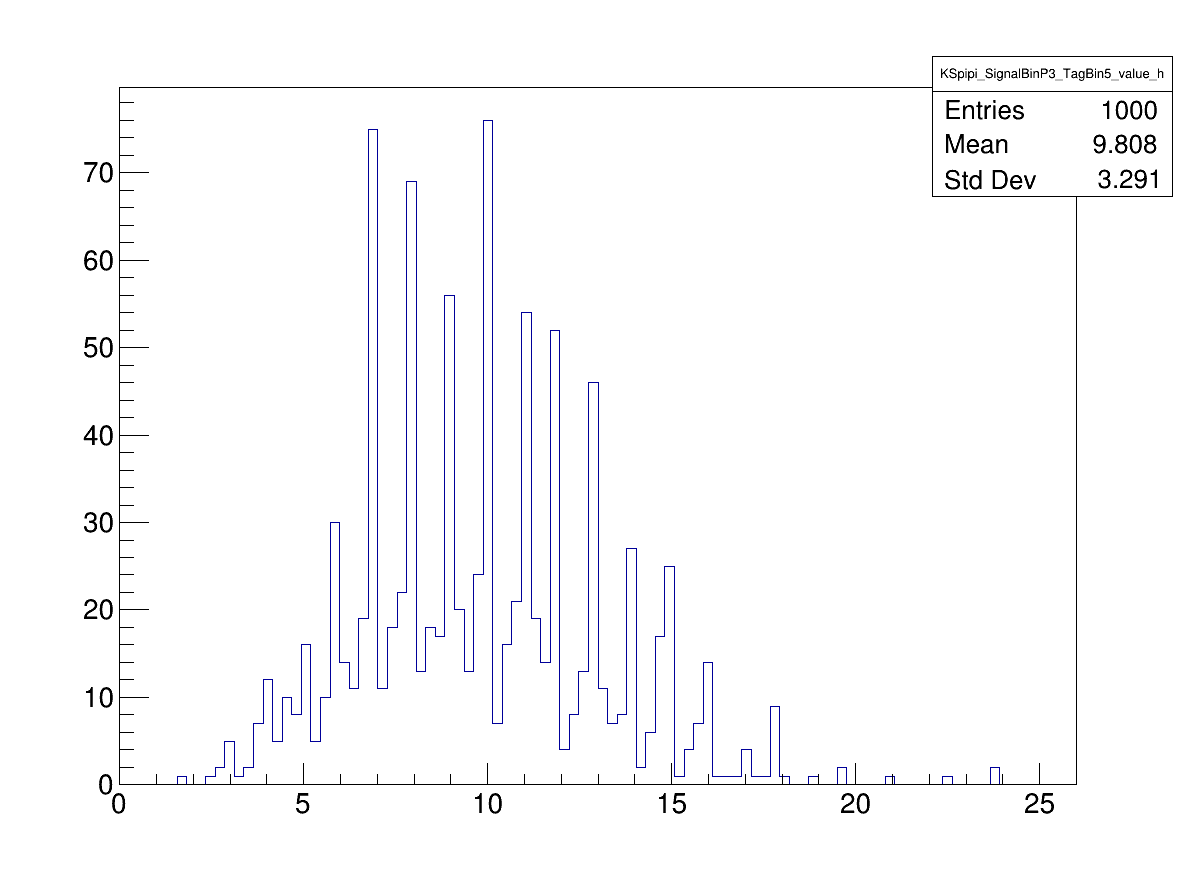

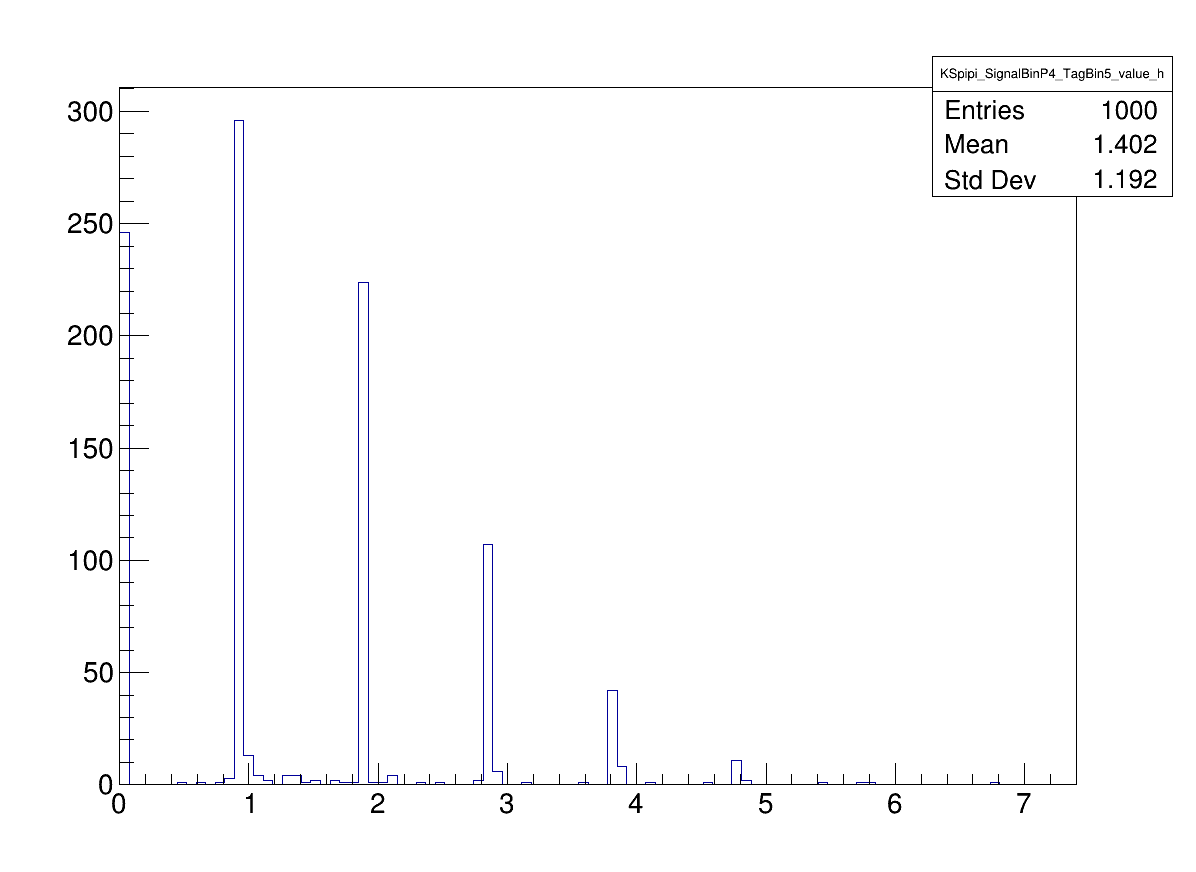

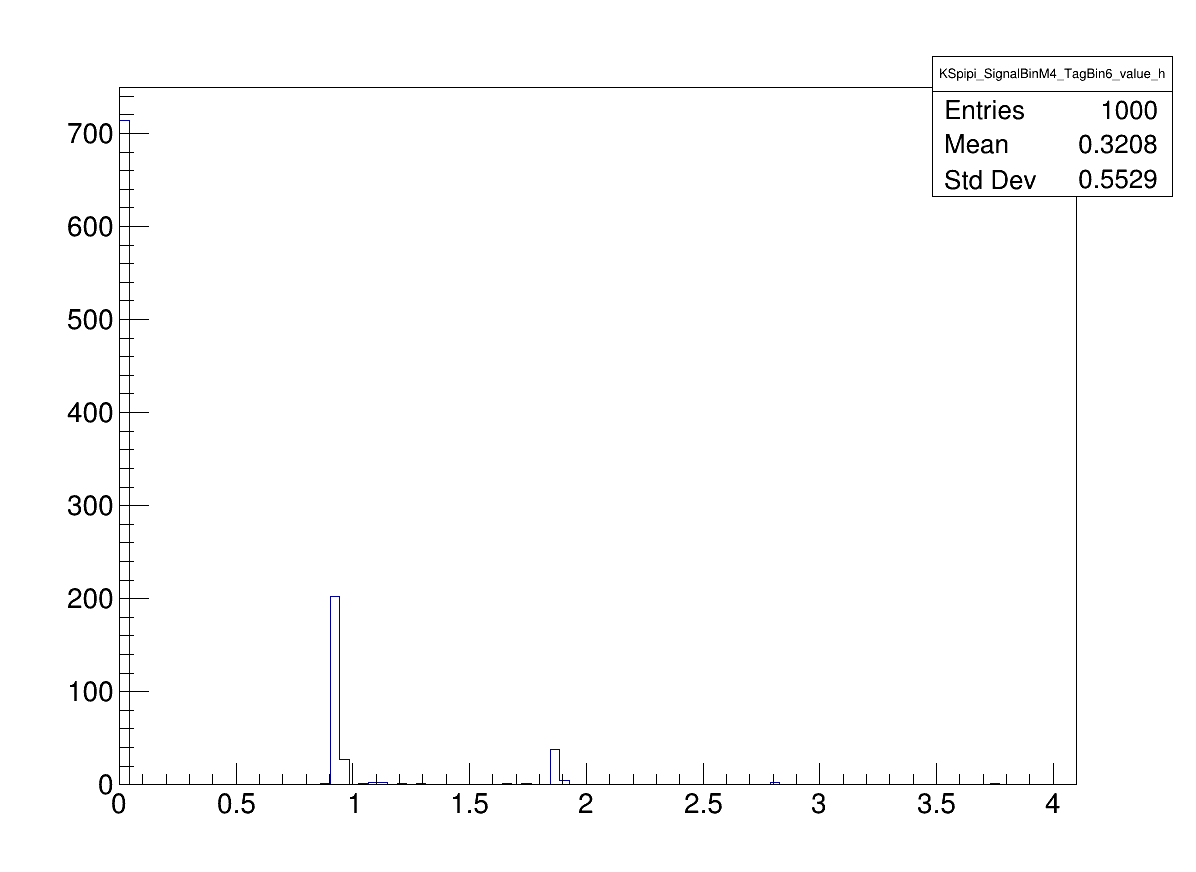

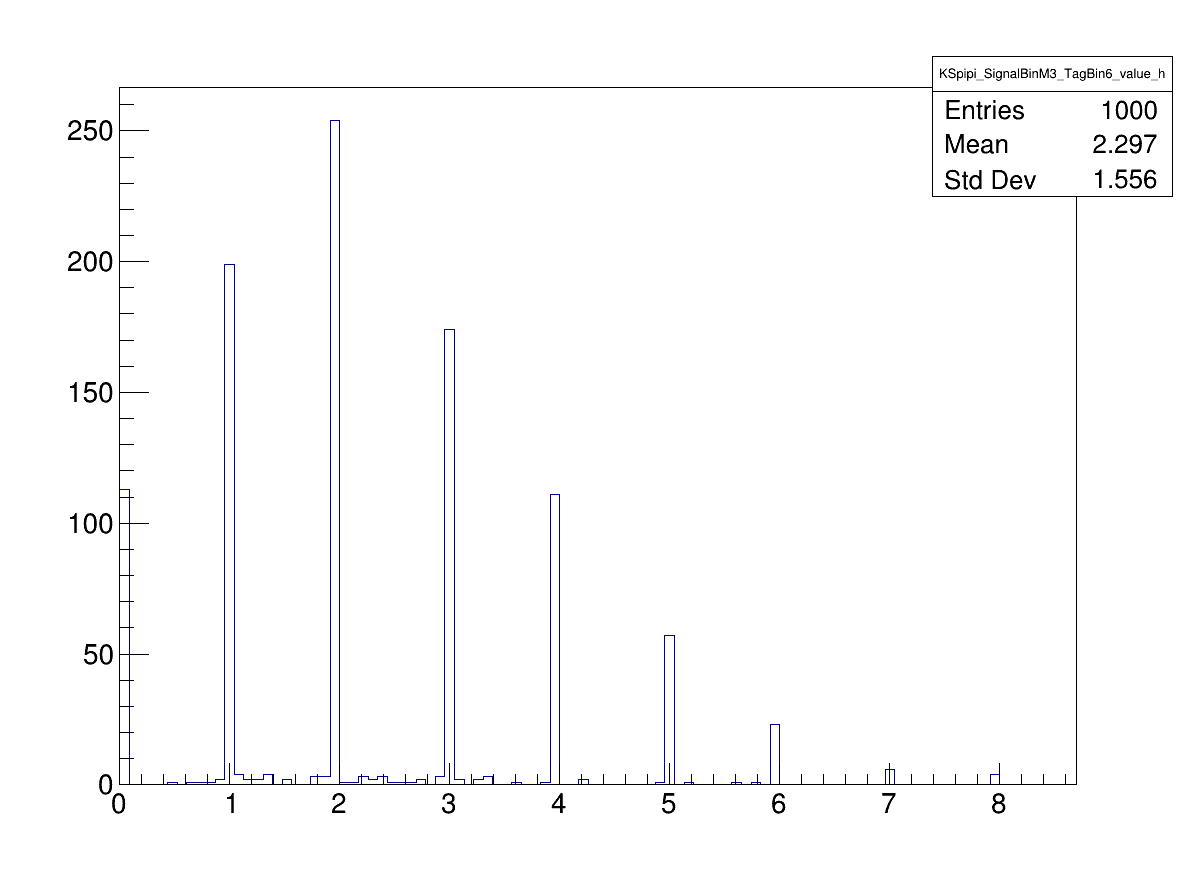

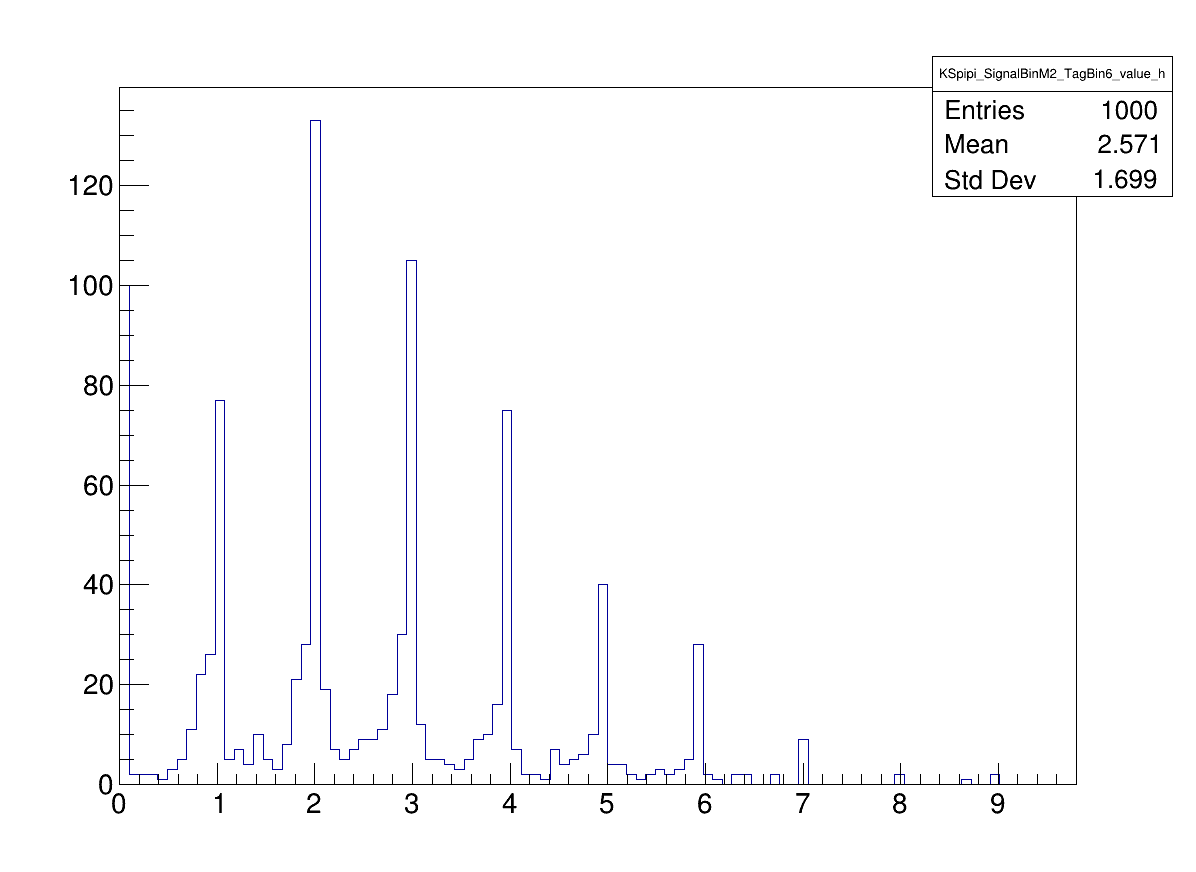

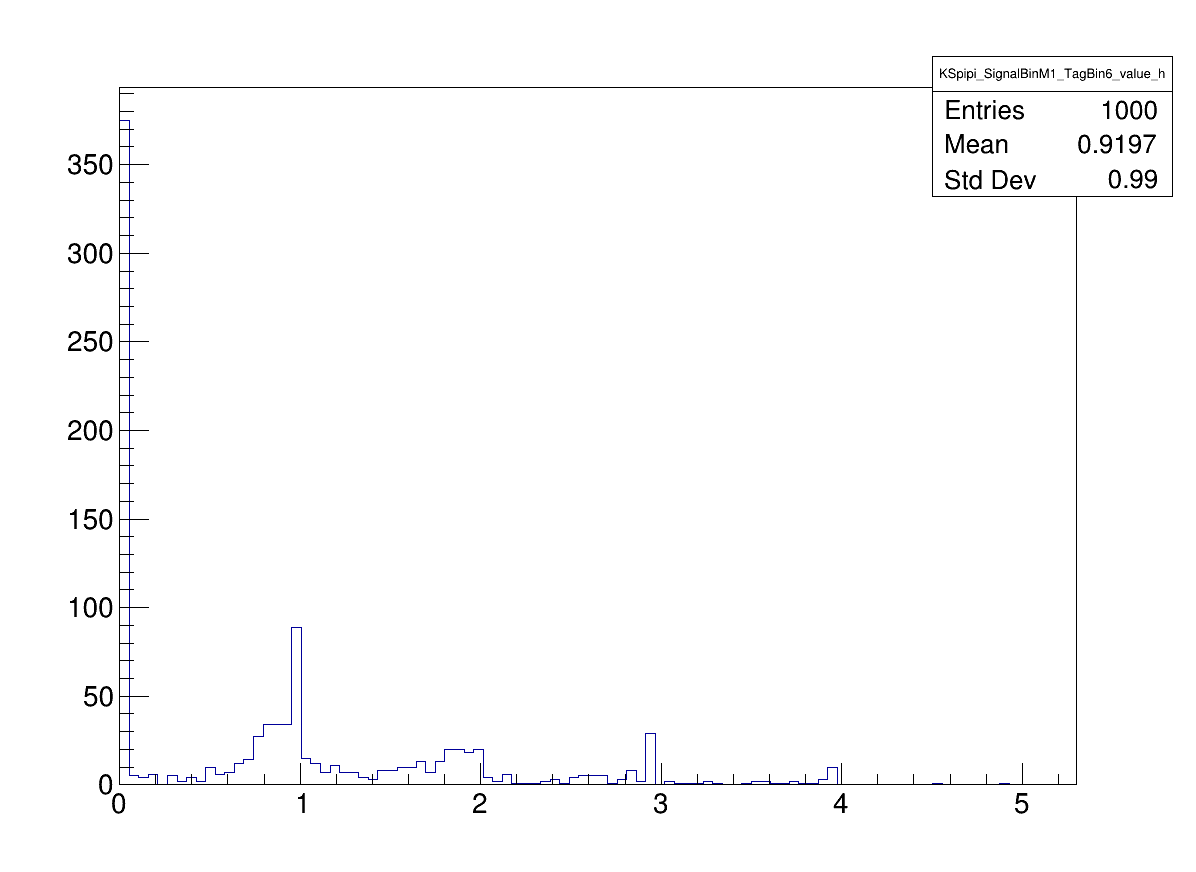

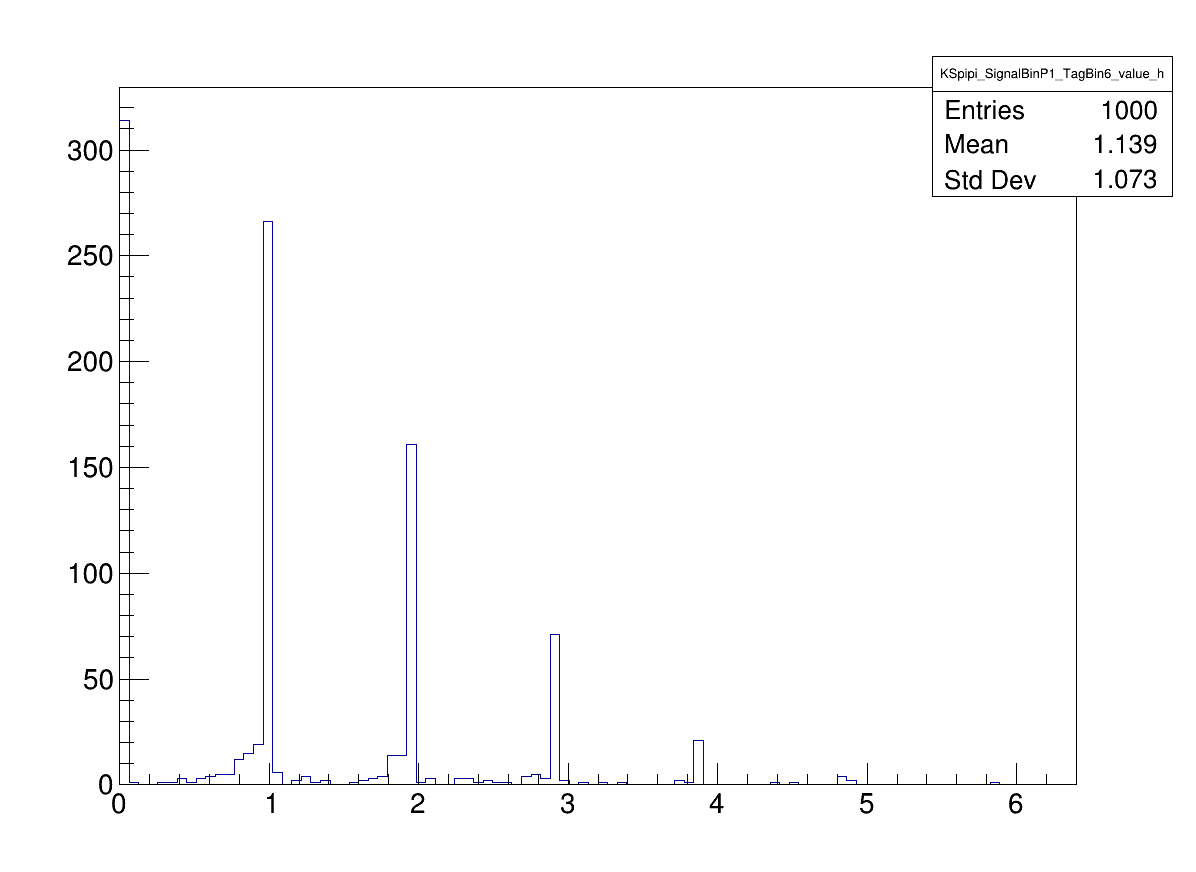

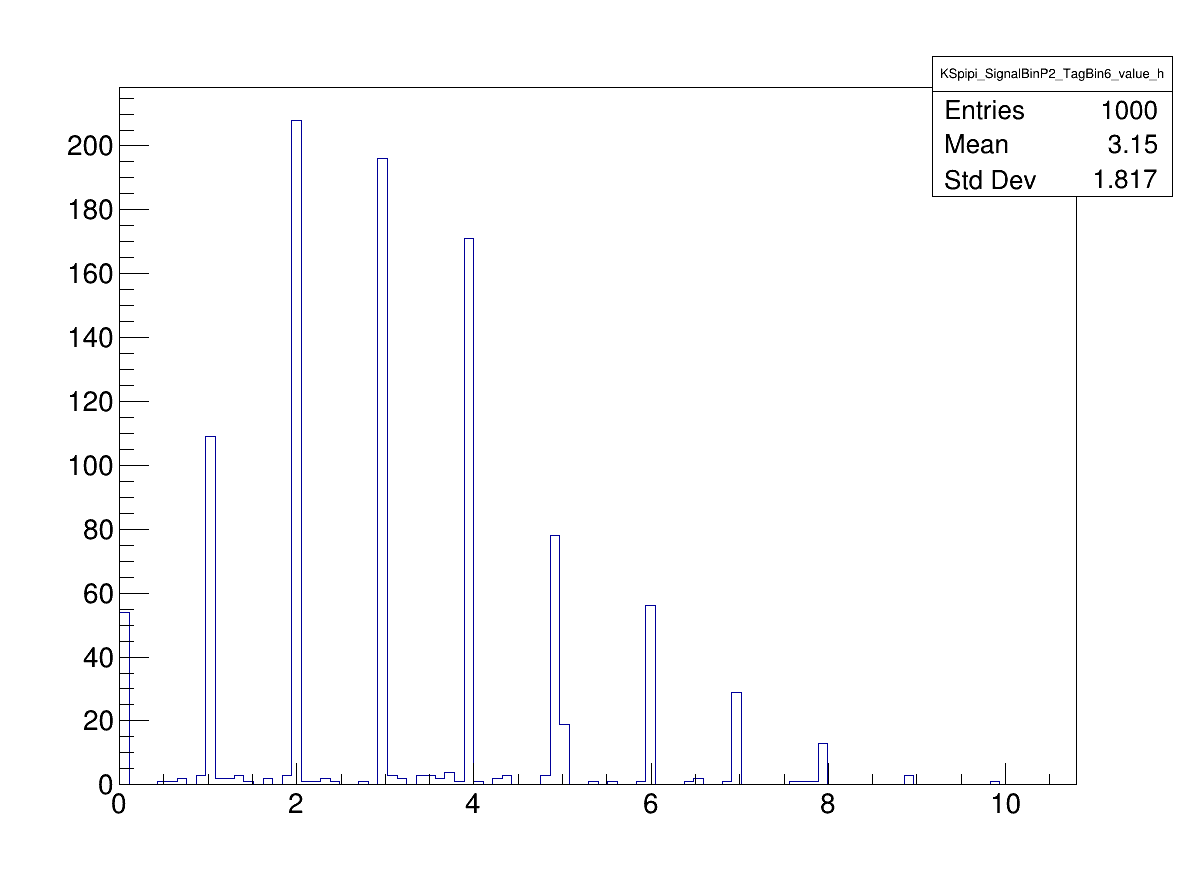

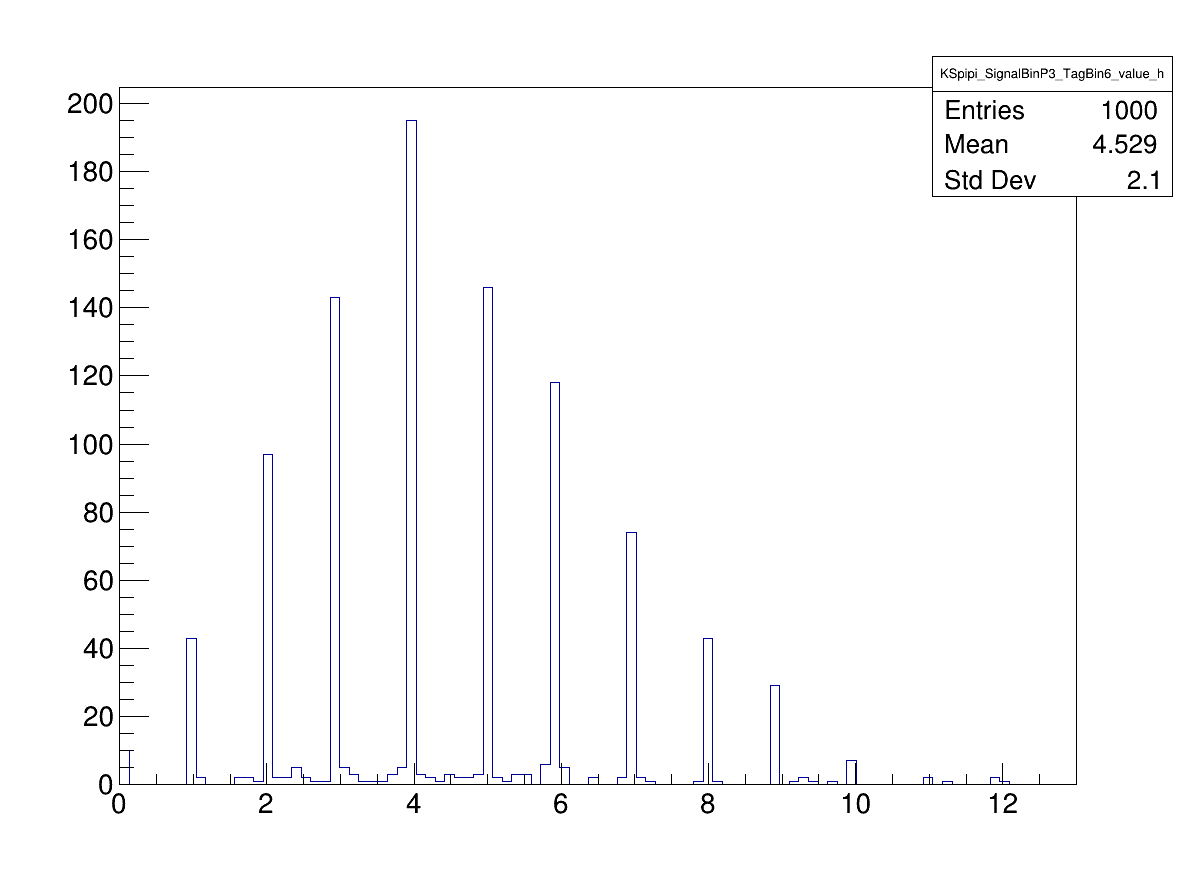

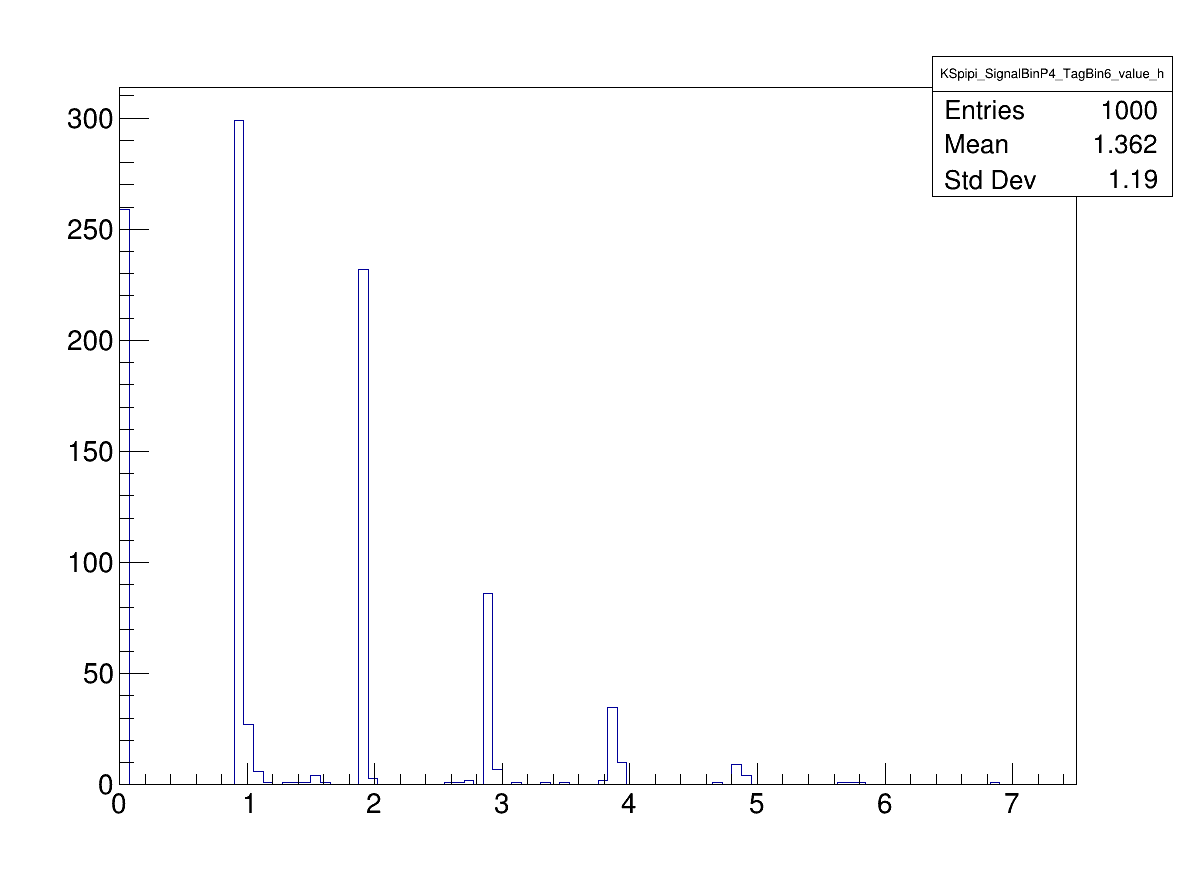

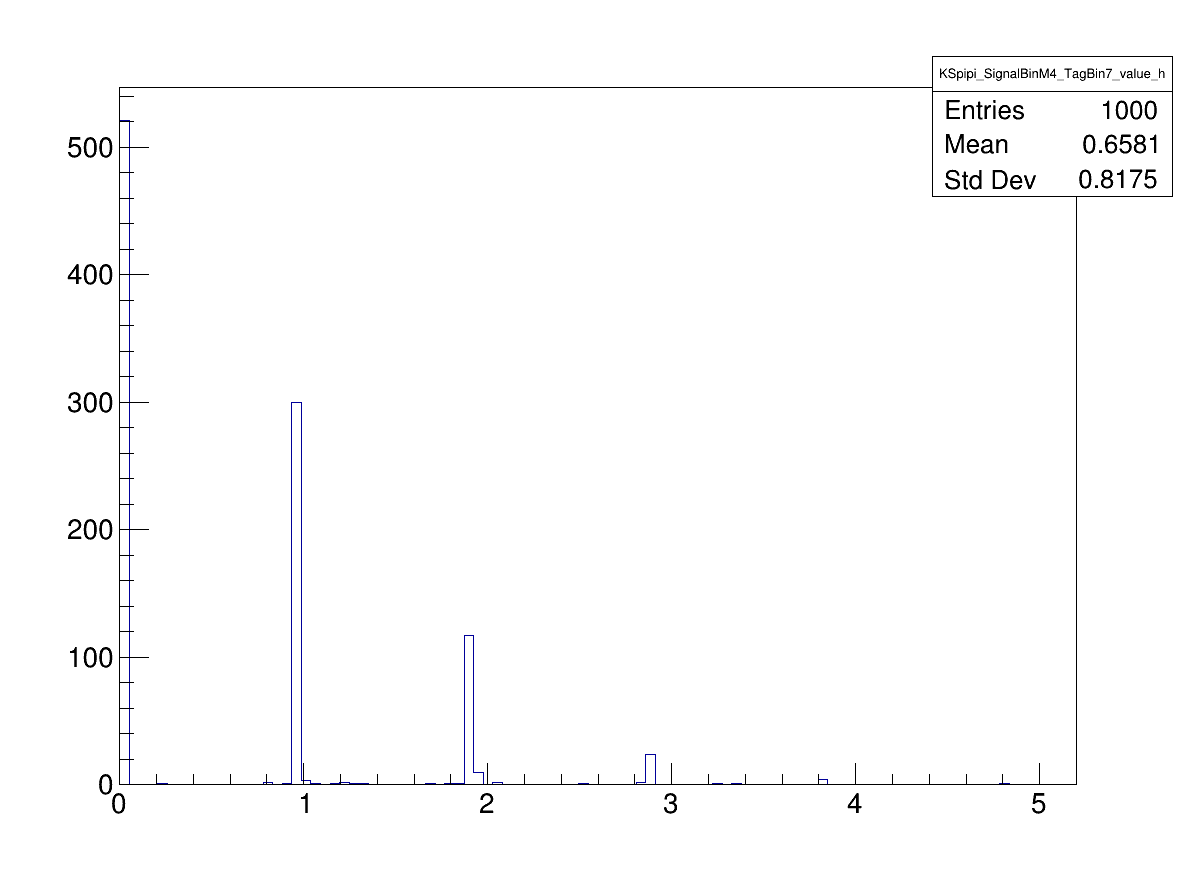

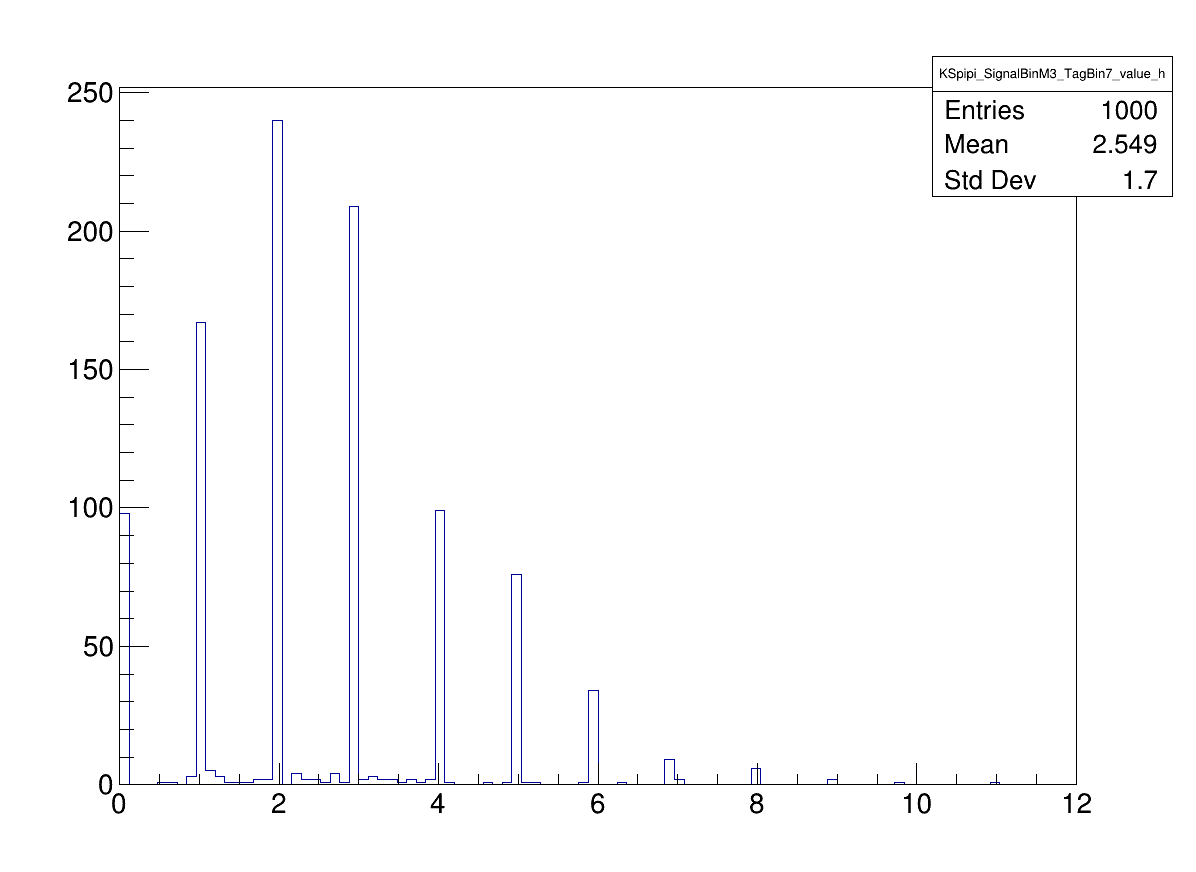

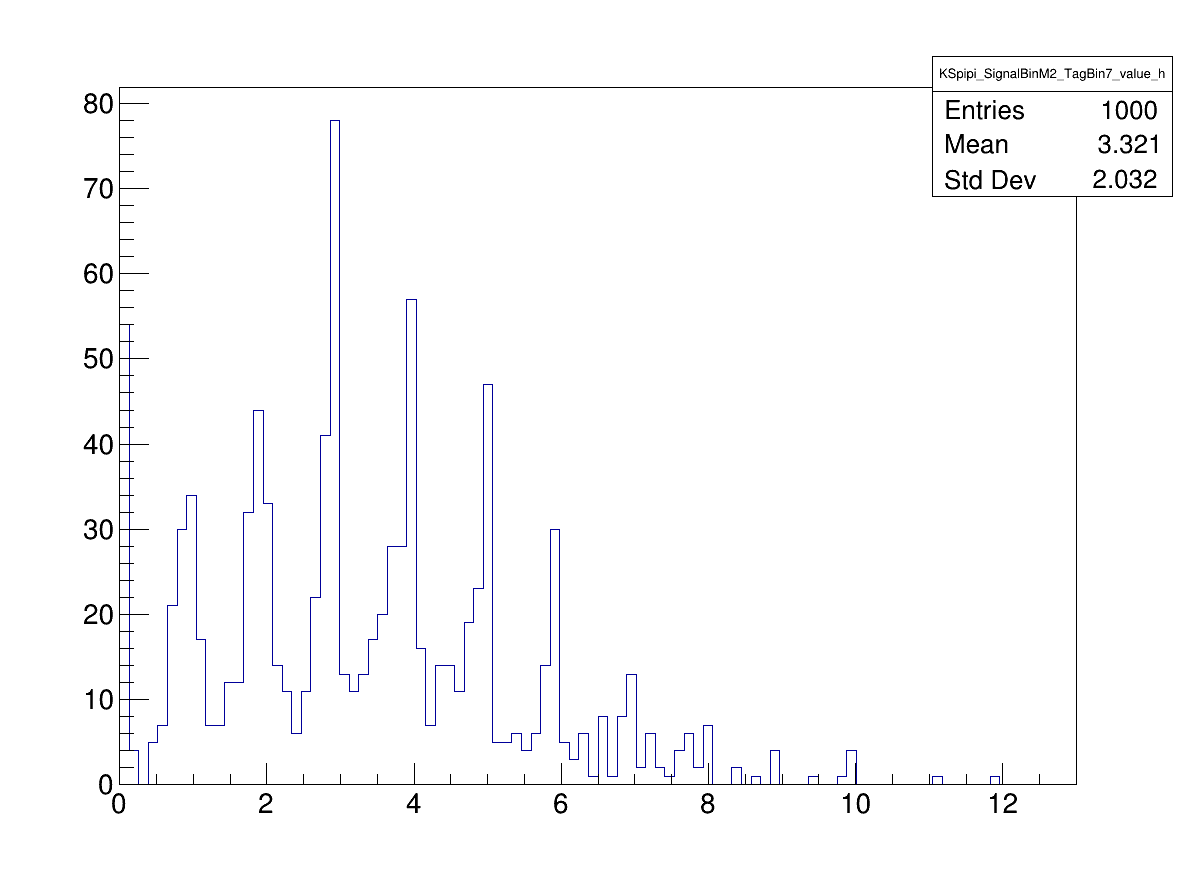

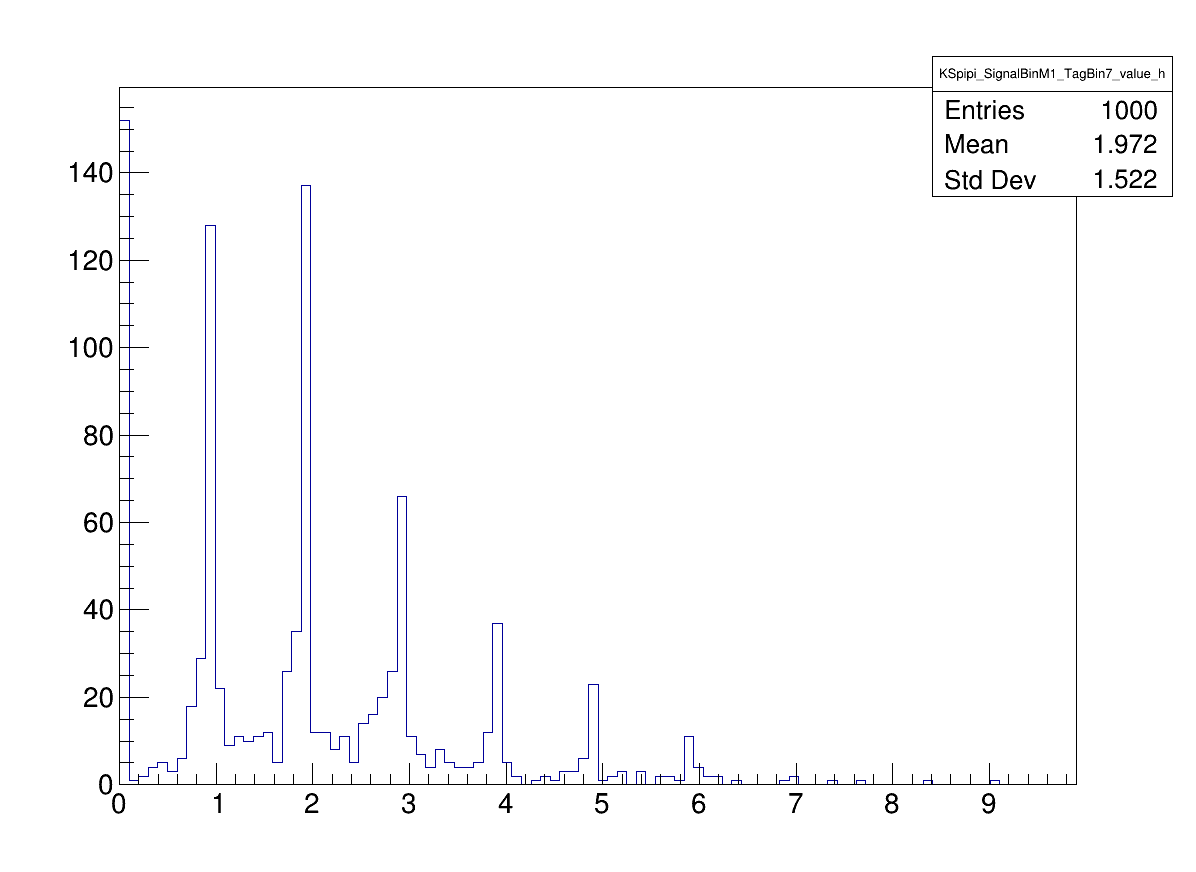

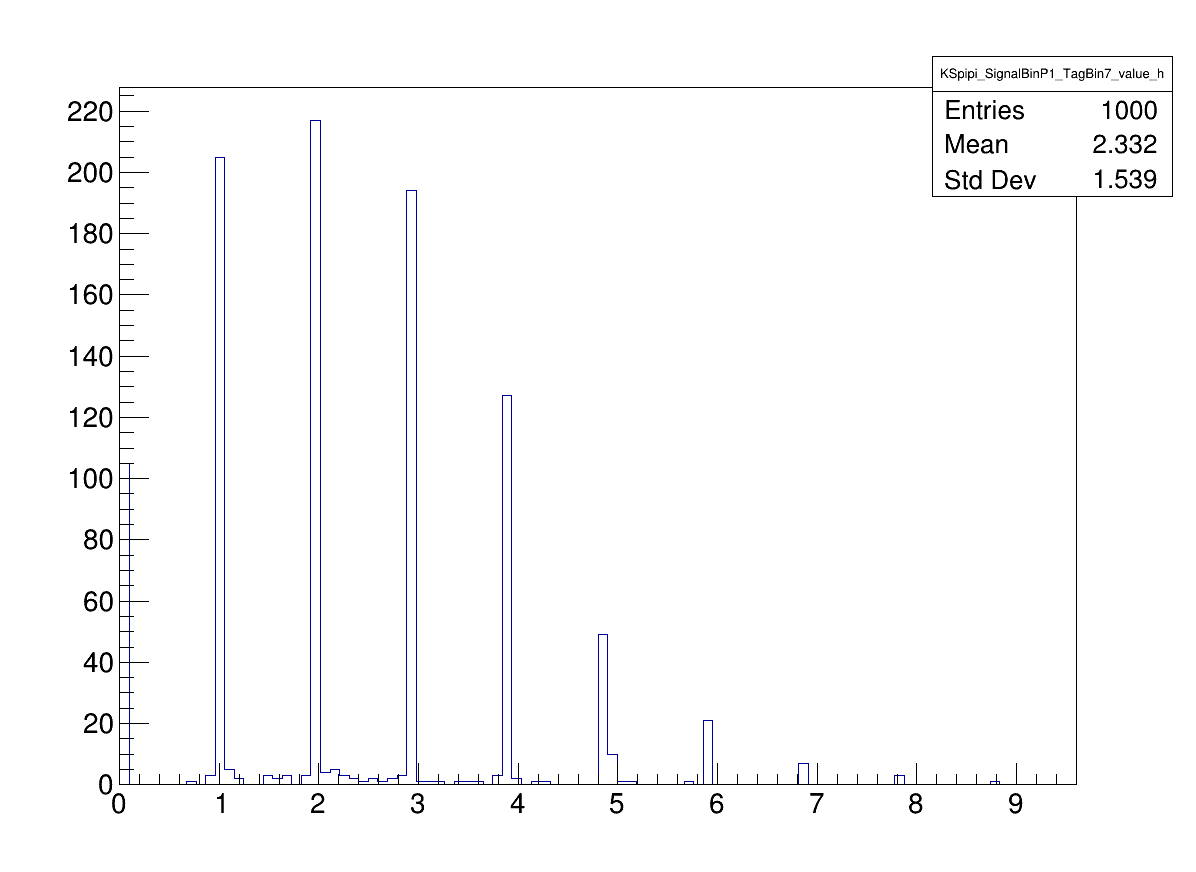

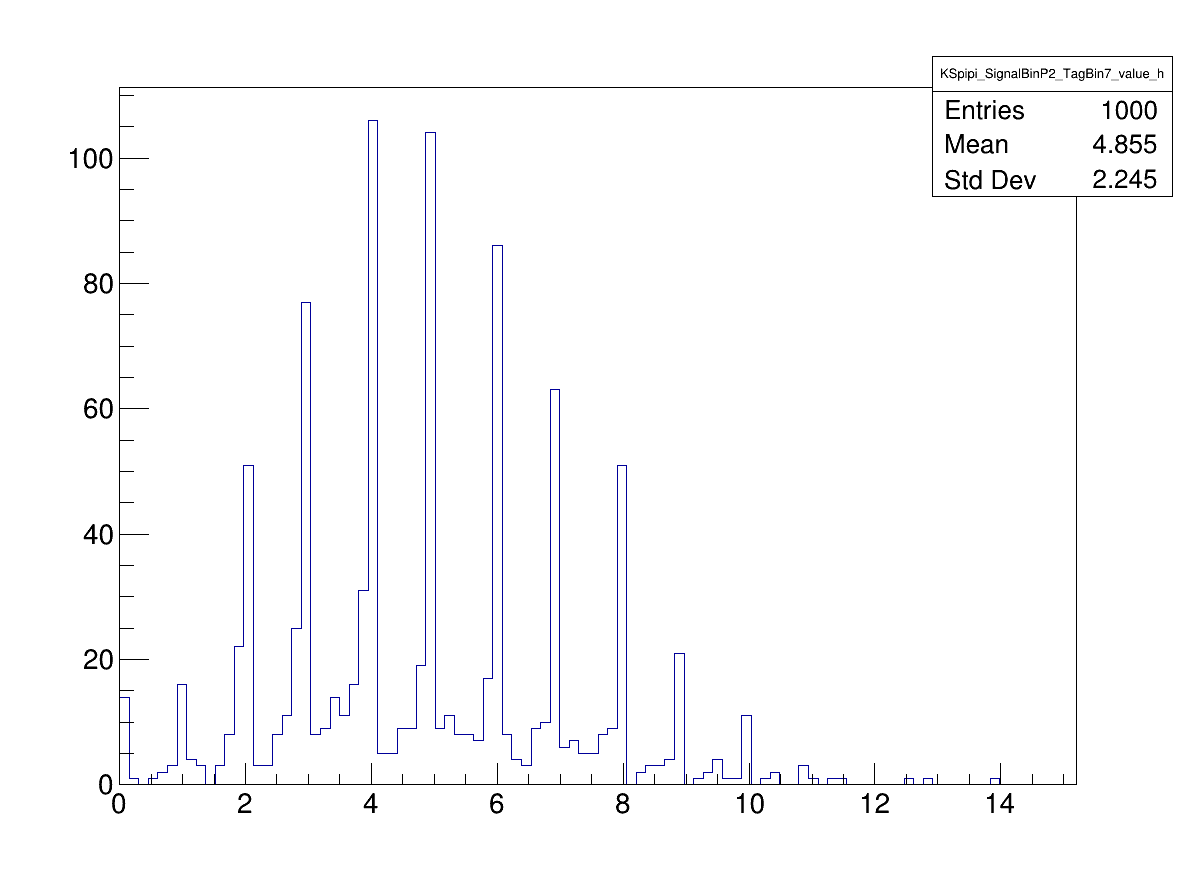

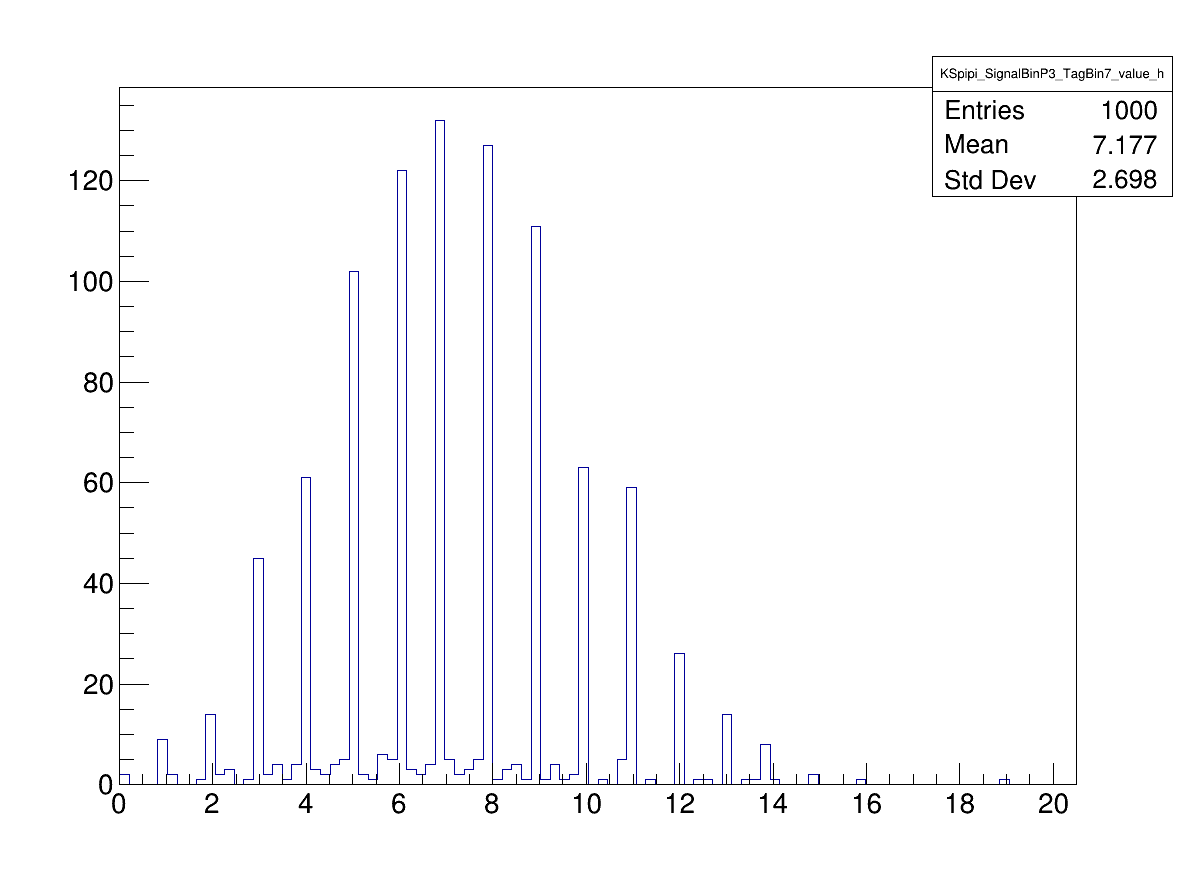

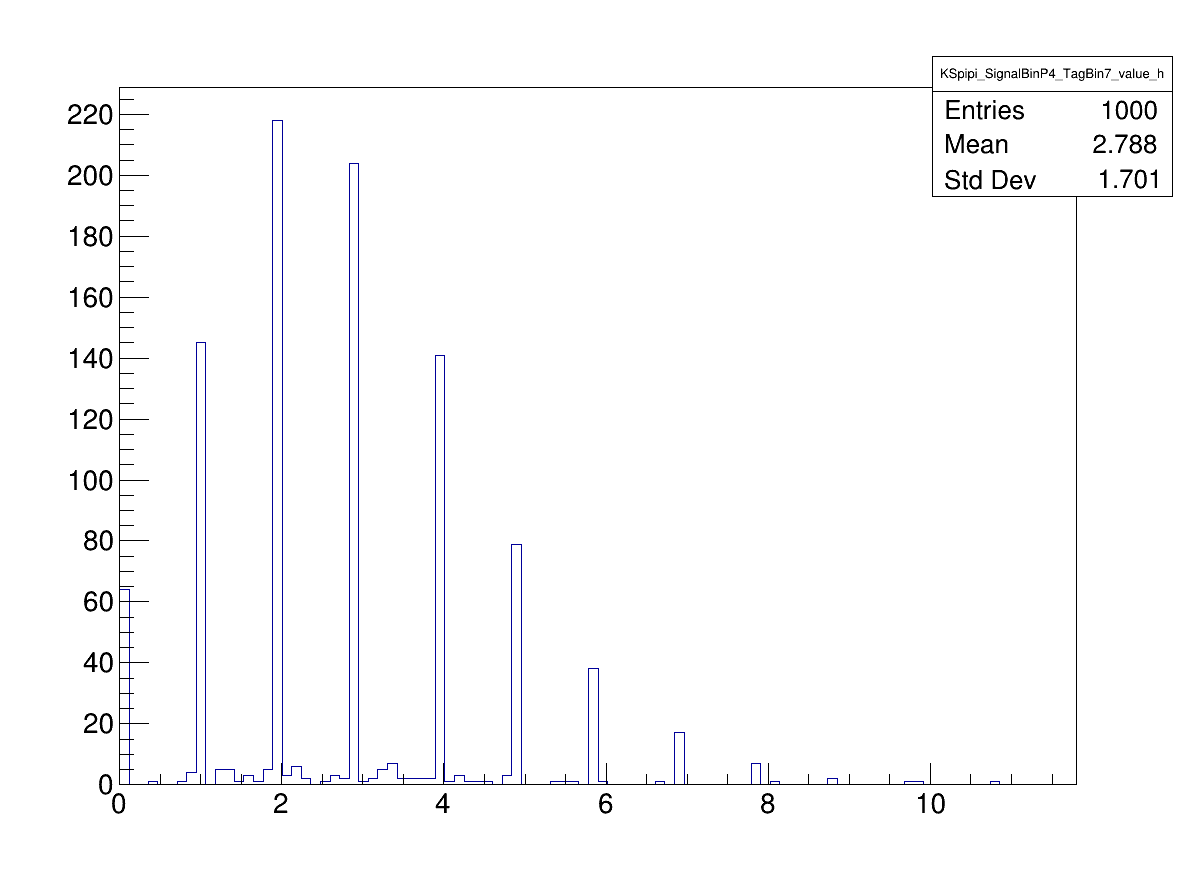

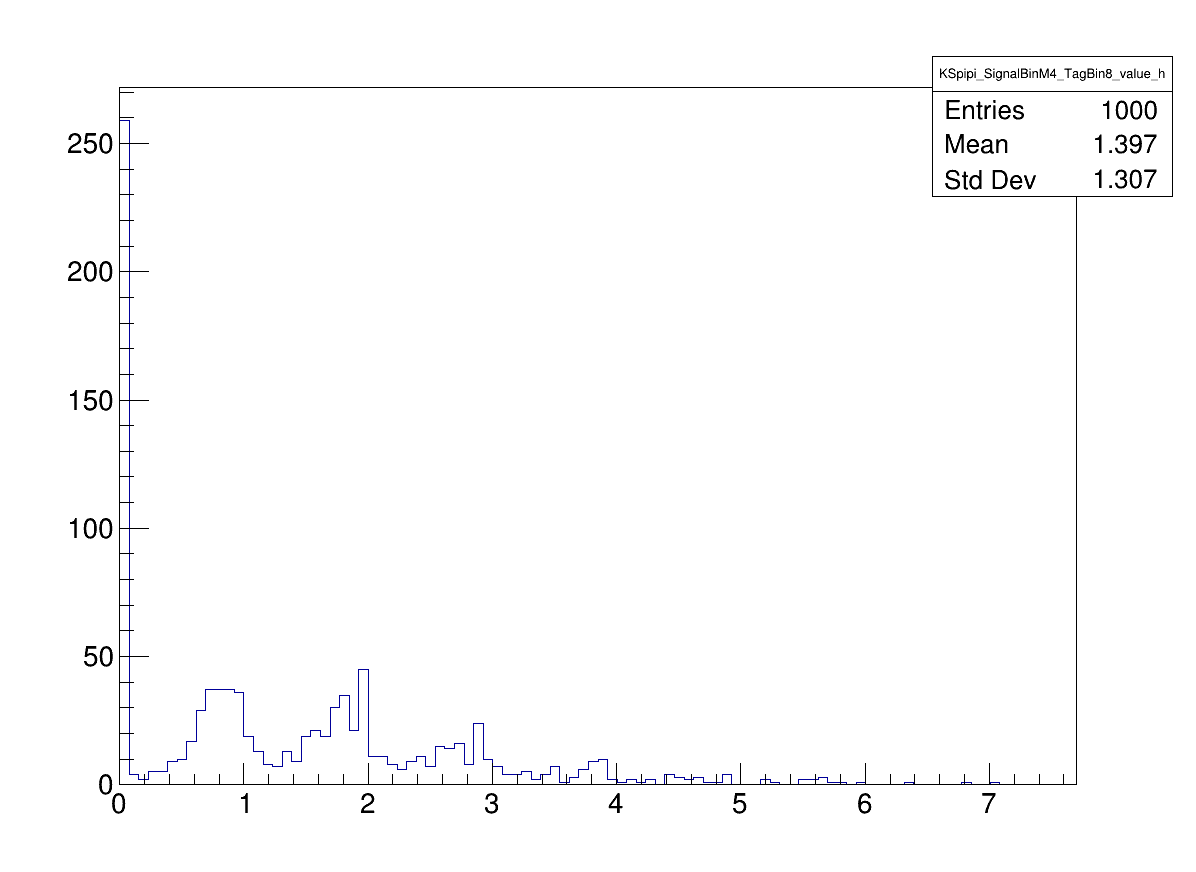

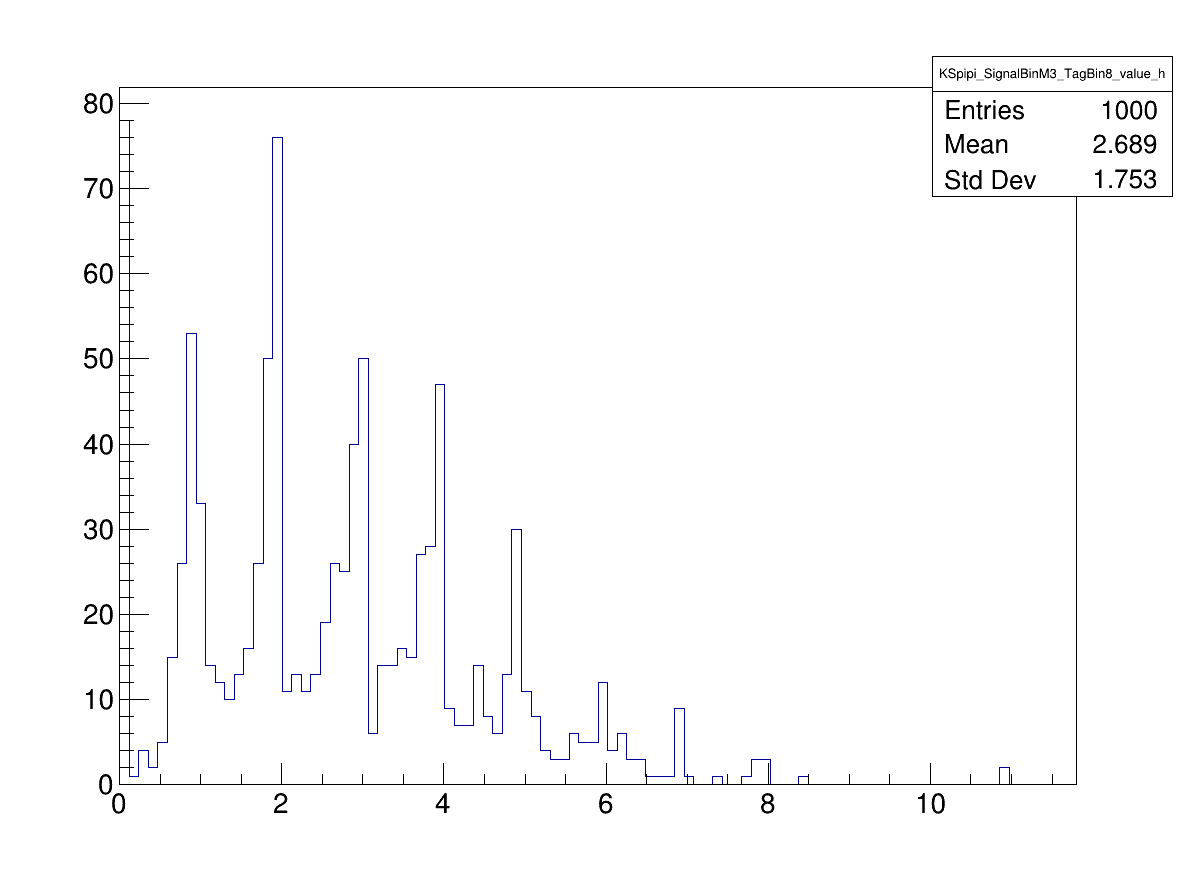

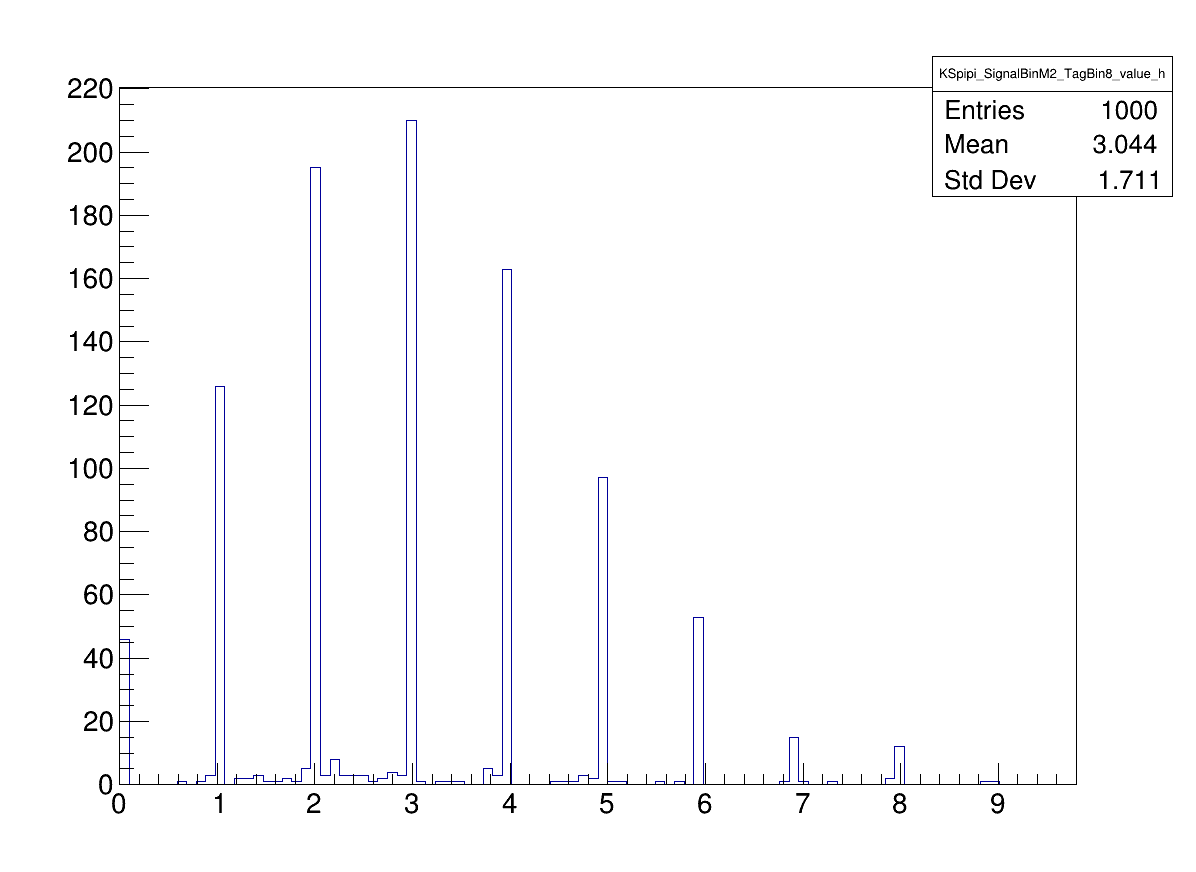

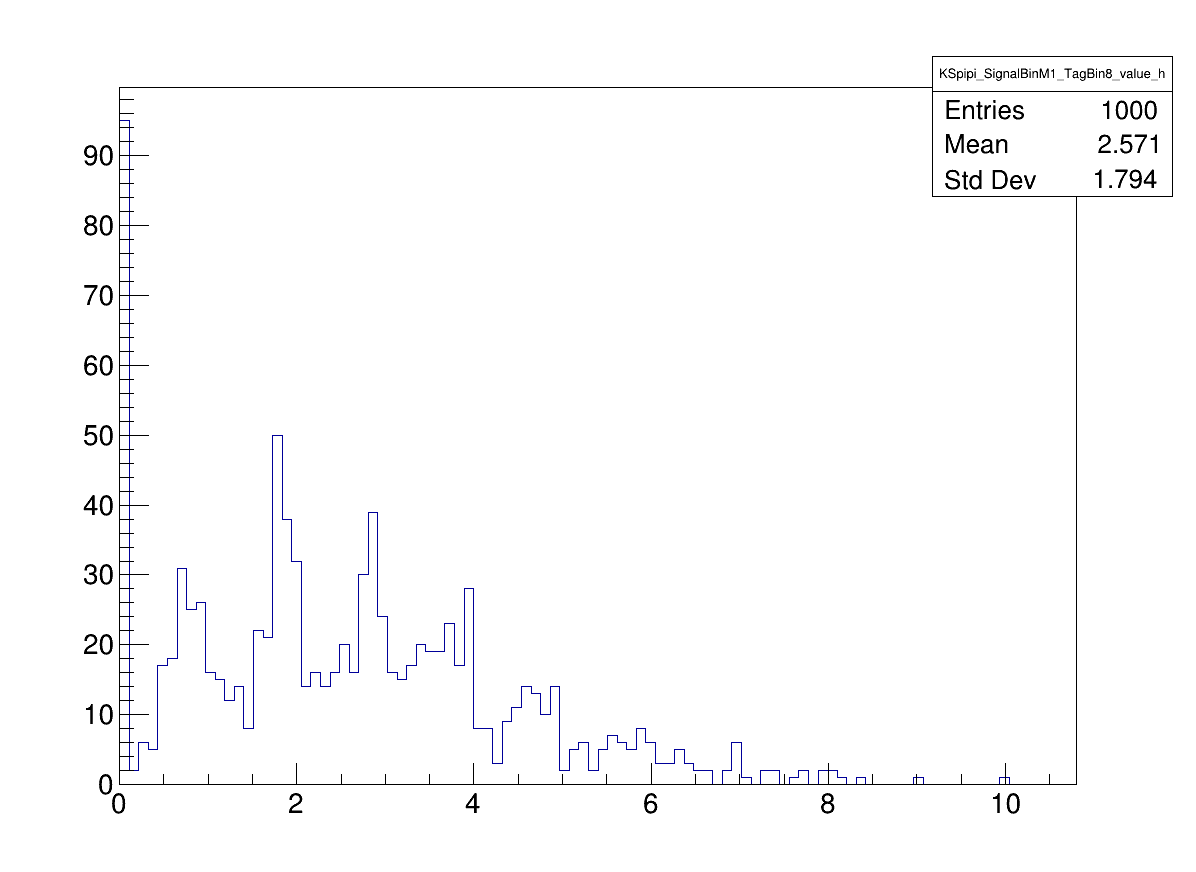

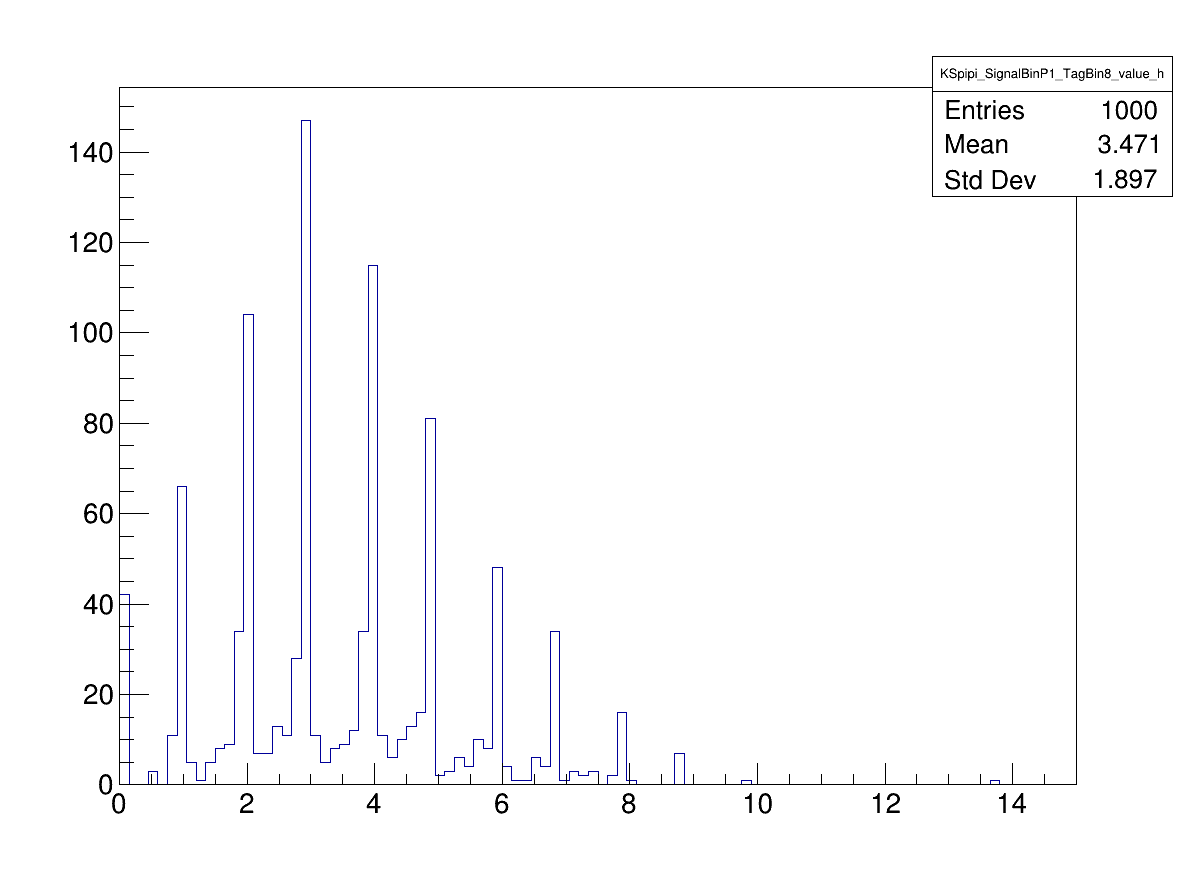

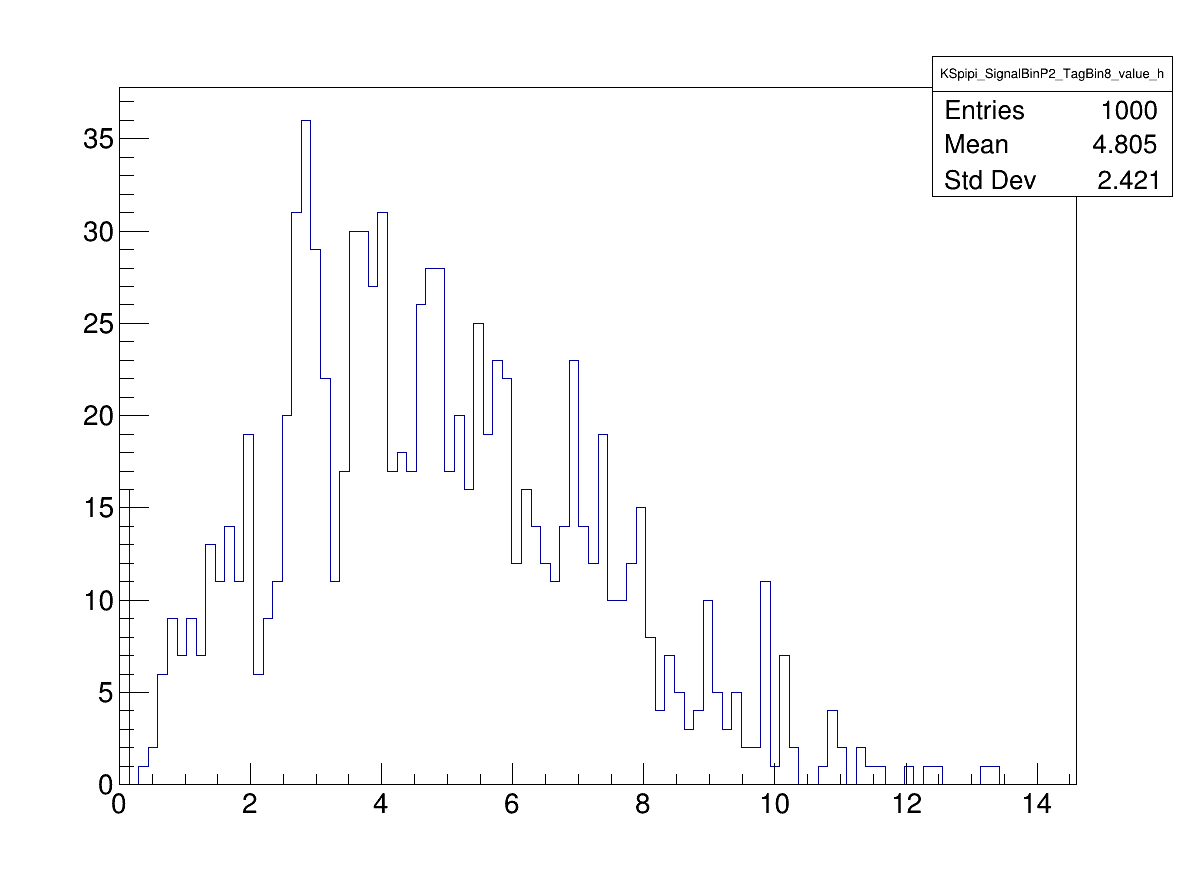

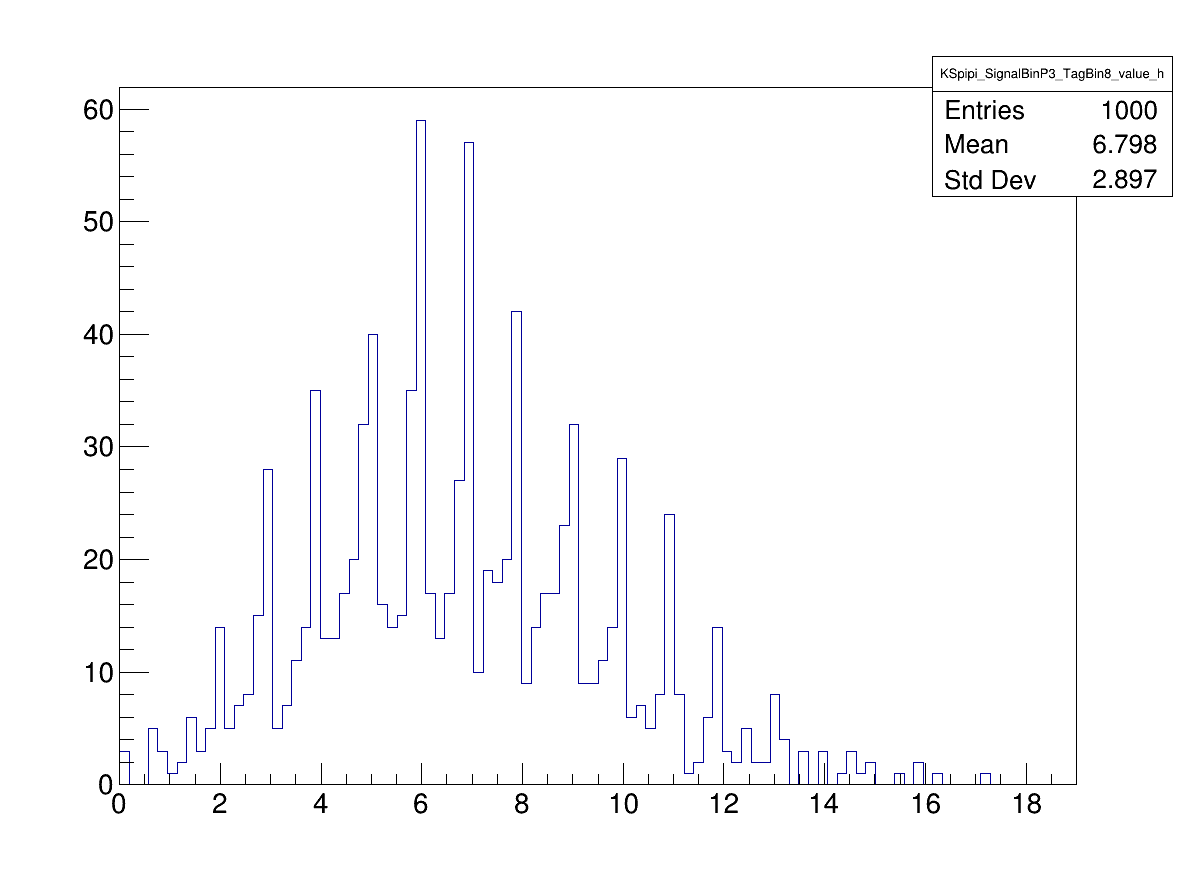

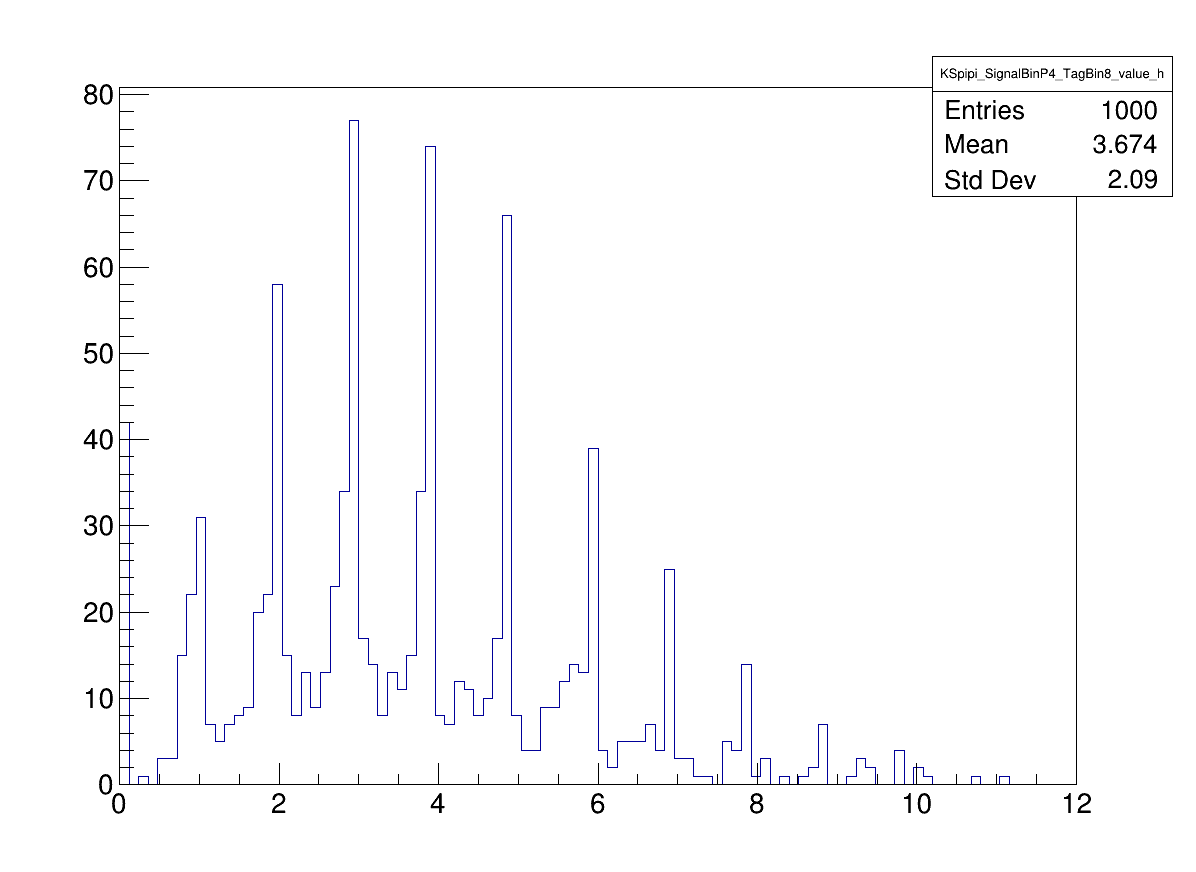

In [8]:
for(const auto &Tag : Tags) {
    std::map<std::pair<int, int>, TH1D*> Histograms_value, Histograms_plus_err,
                                         Histograms_minus_err, Histograms_asymm_err;
    for(int TagBin = 1; TagBin <= 8; TagBin++) {
        for(int SignalBin = -NumberBins; SignalBin <= NumberBins; SignalBin++) {
            if(SignalBin == 0) {
                continue;
            }
            std::string BinName = std::string("SignalBin") + (SignalBin > 0 ? "P" : "M");
            BinName += std::to_string(TMath::Abs(SignalBin));
            BinName += "_TagBin" + std::to_string(TagBin);
            Histograms_value.insert({{SignalBin, TagBin},
                                     new TH1D((Tag + "_" + BinName + "_value_h").c_str(), "",
                                              100, 0.0, 0.0)});
            Histograms_plus_err.insert({{SignalBin, TagBin},
                                        new TH1D((Tag + "_" + BinName + "_plus_err_h").c_str(), "",
                                                 100, 0.0, 0.0)});
            Histograms_minus_err.insert({{SignalBin, TagBin},
                                         new TH1D((Tag + "_" + BinName + "_minus_err_h").c_str(), "",
                                                  100, 0.0, 0.0)});
            Histograms_asymm_err.insert({{SignalBin, TagBin},
                                         new TH1D((Tag + "_" + BinName + "_asymm_err_h").c_str(), "",
                                                  100, 0.0, 0.0)});
        }
    }
    for(int Toy = 0; Toy < NumberToys; Toy++) {
        std::string Filename = "/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/DoubleTagFit/";
        Filename += Tag + "/ToyFitResults/Toy" + std::to_string(Toy) + ".txt";
        const auto Yields = ParseParameters(Filename);
        for(int TagBin = 1; TagBin <= 8; TagBin++) {
            for(int SignalBin = -NumberBins; SignalBin <= NumberBins; SignalBin++) {
                if(SignalBin == 0) {
                    continue;
                }
                std::string Name = "DoubleTag_SCMB_KKpipi_vs_" + Tag + "_SignalBin";
                Name += (SignalBin > 0 ? "P" : "M") + std::to_string(TMath::Abs(SignalBin));
                Name += "_TagBin" + std::to_string(TagBin) + "_SignalYield";
                Histograms_value.at({SignalBin, TagBin})->Fill(Yields.at(Name));
                double PlusError = Yields.at(Name + "_high_err");
                Histograms_plus_err.at({SignalBin, TagBin})->Fill(PlusError);
                double MinusError = -Yields.at(Name + "_low_err");
                Histograms_minus_err.at({SignalBin, TagBin})->Fill(MinusError);
                double Asymm = (PlusError - MinusError)/(PlusError + MinusError);
                Histograms_asymm_err.at({SignalBin, TagBin})->Fill(Asymm);
            }
        }
    }
    for(int TagBin = 1; TagBin <= 8; TagBin++) {
        for(int SignalBin = -NumberBins; SignalBin <= NumberBins; SignalBin++) {
            if(SignalBin == 0) {
                continue;
            }
            std::string BinName = "DoubleTag_SCMB_KKpipi_vs_" + Tag + "_SignalBin";
            BinName += (SignalBin > 0 ? "P" : "M") + std::to_string(TMath::Abs(SignalBin));
            BinName += "_TagBin" + std::to_string(TagBin) + "_SignalYield";
            TCanvas *c = new TCanvas((Tag + "_" + BinName + "_value_h").c_str(), "", 1200, 900);
            Histograms_value.at({SignalBin, TagBin})->Draw();
            c->Draw();
        }
    }
    /*for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        TCanvas *c = new TCanvas((Tag + "_" + BinName + "_plus_err_h").c_str(), "", 1200, 900);
        Histograms_plus_err.at(Bin)->Draw();
        c->Draw();
    }
    for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        TCanvas *c = new TCanvas((Tag + "_" + BinName + "_minus_err_h").c_str(), "", 1200, 900);
        Histograms_minus_err.at(Bin)->Draw();
        c->Draw();
    }
    for(int Bin = -NumberBins; Bin <= NumberBins; Bin++) {
        if(Bin == 0) {
            continue;
        }
        std::string BinName = (Bin > 0 ? "P" : "M") + std::to_string(TMath::Abs(Bin));
        TCanvas *c = new TCanvas((Tag + "_" + BinName + "_asymm_err_h").c_str(), "", 1200, 900);
        Histograms_asymm_err.at(Bin)->Draw();
        c->Draw();
    }*/
}